**Goal recap**: produce colonoscopy images from (1) a binary polyp mask + (2) a text prompt, using a Stable Diffusion backbone (prefer SD 1.5 on Colab Pro; SDXL is heavier), with (3) ControlNet for spatial (mask) conditioning, (4) LoRA for efficient fine-tuning, and (5) three small “constraint heads” (classifiers/segmenter) that drive sampling via gradient guidance so outputs obey requested size/morphology/prep/instrument constraints.

**Download these public datasets** (free for research):

1. Kvasir-SEG (1,000 polyp images + masks). Great for mask conditioning and polyp shapes.

2. PolypGen (multi-centre polyp dataset; use as hold-out / OOD test).

3. Kvasir-Instrument (tools: 590 frames with masks; train instrument head).

4. LDPolypVideo (large video dataset; optional, for extra frames).

5. Nerthus (bowel preparation / BBPS video dataset) — for prep quality classifier.

In [ ]:
# Colab / shell cell
# Use Python 3.10+ runtime with GPU runtime (T4, A100 if available).
!pip install -q --upgrade pip
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q diffusers[torch]==0.28.1 transformers accelerate safetensors bitsandbytes
!pip install -q git+https://github.com/huggingface/peft.git
!pip install -q ffmpeg-python opencv-python scikit-image timm
!pip install -q scipy scikit-learn lpips pytorch-fid ftfy
# Optional (faster image I/O):
!pip install -q pillow_heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Uninstall all potentially conflicting versions
!pip uninstall -y diffusers transformers peft huggingface_hub accelerate tokenizers safetensors

# Optional: clear pip cache
!rm -rf /root/.cache/pip

# Install compatible versions
!pip install --no-cache-dir \
    diffusers==0.30.1 \
    transformers==4.35.2 \
    accelerate==0.24.1 \
    peft==0.8.2 \
    safetensors==0.4.0 \
    huggingface_hub==0.25.2 \
    tokenizers==0.15.0

Found existing installation: diffusers 0.28.1
Uninstalling diffusers-0.28.1:
  Successfully uninstalled diffusers-0.28.1
Found existing installation: transformers 4.57.1
Uninstalling transformers-4.57.1:
  Successfully uninstalled transformers-4.57.1
Found existing installation: peft 0.17.2.dev0
Uninstalling peft-0.17.2.dev0:
  Successfully uninstalled peft-0.17.2.dev0
Found existing installation: huggingface-hub 0.35.3
Uninstalling huggingface-hub-0.35.3:
  Successfully uninstalled huggingface-hub-0.35.3
Found existing installation: accelerate 1.11.0
Uninstalling accelerate-1.11.0:
  Successfully uninstalled accelerate-1.11.0
Found existing installation: tokenizers 0.22.1
Uninstalling tokenizers-0.22.1:
  Successfully uninstalled tokenizers-0.22.1
Found existing installation: safetensors 0.6.2
Uninstalling safetensors-0.6.2:
  Successfully uninstalled safetensors-0.6.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 11.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install segmentation-models-pytorch --quiet

In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# connect drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Datasets - Download & Prepare

### a. Upload kaggle.json if using Kaggle (Code)

In [ ]:
import os

# Define the path to the kaggle.json file (handle spaces with quotes)
kaggle_json_path = '/content/drive/My Drive/COMP8539/Final_Project/kaggle.json'

# Check if the kaggle.json file exists at the given path
if os.path.exists(kaggle_json_path):
    # Create the .kaggle directory if it doesn't exist
    !mkdir -p ~/.kaggle
    # Copy the kaggle.json file to the .kaggle directory, handling spaces in the path
    !cp "{kaggle_json_path}" ~/.kaggle/
    # Set appropriate permissions for the file
    !chmod 600 ~/.kaggle/kaggle.json
    print("kaggle.json installed")
else:
    print(f"No kaggle.json found at {kaggle_json_path}. Please upload it first.")


kaggle.json installed


### b. Download Kvasir-SEG via Kaggle (Code)

In [ ]:
# Kvasir-SEG may have several mirrors. Example Kaggle dataset name used here might differ.
# If Kaggle dataset name doesn't exist, download manually from the Simula/Kvasir site.
# Try:
!kaggle datasets download -d fkarimovv/kvasir-seg -p "/content/drive/My Drive/COMP8539/Final_Project" || echo "Kaggle download failed: upload dataset manually."
!unzip -q "/content/drive/My Drive/COMP8539/Final_Project/kvasir-seg.zip" -d "/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg" || echo "Unzip failed or not found, check dataset."

Dataset URL: https://www.kaggle.com/datasets/fkarimovv/kvasir-seg
License(s): apache-2.0
 50% 22.0M/44.0M [00:00<00:00, 223MB/s]
100% 44.0M/44.0M [00:00<00:00, 227MB/s]


https://datasets.simula.no/hyper-kvasir/

In [ ]:
# Download the labeled image dataset
!wget --no-check-certificate -O "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir_labeled_images.zip" https://datasets.simula.no/downloads/hyper-kvasir/hyper-kvasir-labeled-images.zip

# Download the metadata (contains labels)
!wget --no-check-certificate -O "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir_segmented_images.zip" https://datasets.simula.no/downloads/hyper-kvasir/hyper-kvasir-segmented-images.zip

# Optional: download video frames (big file!)
# !wget -O /content/hyper_kvasir_videos.zip https://datasets.simula.no/hyper-kvasir/hyper-kvasir-video-images.zip

--2025-10-13 06:40:03--  https://datasets.simula.no/downloads/hyper-kvasir/hyper-kvasir-labeled-images.zip
Resolving datasets.simula.no (datasets.simula.no)... 128.39.36.14
Connecting to datasets.simula.no (datasets.simula.no)|128.39.36.14|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 3928814344 (3.7G) [application/zip]
Saving to: ‘/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir_labeled_images.zip’

/content/drive/My D 100%[===================>]   3.66G  4.46MB/s    in 25m 10s 

2025-10-13 07:05:13 (2.48 MB/s) - ‘/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir_labeled_images.zip’ saved [3928814344/3928814344]

--2025-10-13 07:05:14--  https://datasets.simula.no/downloads/hyper-kvasir/hyper-kvasir-segmented-images.zip
Resolving datasets.simula.no (datasets.simula.no)... 128.39.36.14
Connecting to datasets.simula.no (datasets.simula.no)|128.39.36.14|:443... connected.
  Unable to locall

In [ ]:
# !md /content/data/hyper_kvasir/labeled_images
# !md /content/data/hyper_kvasir/segmented_images
# Create directories for labeled and segmented images (if not already present)
!mkdir -p "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/labeled_images"
!mkdir -p "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/segmented_images"
# Unzip
!unzip -q "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir_labeled_images.zip" -d "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/labeled_images"
!unzip -q "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir_segmented_images.zip" -d "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/segmented_images"

### c. kvasir-instrument

In [ ]:
import os, zipfile, shutil, glob, subprocess, sys, json

# 2) Download + unzip Kvasir-Instrument
!kaggle datasets download -d debeshjha1/kvasirinstrument -p "/content/drive/My Drive/COMP8539/Final_Project/"
!unzip -q -o "/content/drive/My Drive/COMP8539/Final_Project/kvasirinstrument.zip" -d "/content/drive/My Drive/COMP8539/Final_Project/kvasir_instrument"

print("Kvasir-Instrument ready at /content/drive/My Drive/COMP8539/Final_Project/kvasir_instrument")
!find "/content/drive/My Drive/COMP8539/Final_Project/kvasir_instrument" -maxdepth 2 -type d -print

Dataset URL: https://www.kaggle.com/datasets/debeshjha1/kvasirinstrument
License(s): copyright-authors
100% 162M/162M [00:01<00:00, 87.6MB/s]
100% 162M/162M [00:01<00:00, 95.1MB/s]
Kvasir-Instrument ready at /content/drive/My Drive/COMP8539/Final_Project/kvasir_instrument
/content/drive/My Drive/COMP8539/Final_Project/kvasir_instrument
/content/drive/My Drive/COMP8539/Final_Project/kvasir_instrument/kvasir-instrument
/content/drive/My Drive/COMP8539/Final_Project/kvasir_instrument/kvasir-instrument/images
/content/drive/My Drive/COMP8539/Final_Project/kvasir_instrument/kvasir-instrument/masks


### d. Nerthus bowel-prep quality dataset

In [ ]:
# Requires kaggle.json already configured (see A1)
!kaggle datasets download -d orvile/nerthus-video-dataset-for-colonoscopy-analysis -p "/content/drive/My Drive/COMP8539/Final_Project/nerthus"
!mkdir -p "/content/drive/My Drive/COMP8539/Final_Project/nerthus_videos"
!unzip -q -o "/content/drive/My Drive/COMP8539/Final_Project/nerthus/nerthus-video-dataset-for-colonoscopy-analysis.zip" -d "/content/drive/My Drive/COMP8539/Final_Project/nerthus_videos" || true
!find "/content/drive/My Drive/COMP8539/Final_Project/nerthus_videos" -maxdepth 2 -type f | head -n 10
print("If unzip printed nothing, the Kaggle item could be split archives; check the listing above.")

Dataset URL: https://www.kaggle.com/datasets/orvile/nerthus-video-dataset-for-colonoscopy-analysis
License(s): other
 99% 237M/239M [00:03<00:00, 68.9MB/s]
100% 239M/239M [00:03<00:00, 78.9MB/s]
/content/drive/My Drive/COMP8539/Final_Project/nerthus_videos/nerthus.csv
If unzip printed nothing, the Kaggle item could be split archives; check the listing above.


## 2. Prepare dataset manifest (masks → size buckets)

### a. kvasir_seg

In [ ]:
# prepare_data.py logic inline
import os, cv2, pandas as pd, numpy as np
from glob import glob
from pathlib import Path
import matplotlib.pyplot as plt

IMG_GLOB = '/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/images/*'  # adjust if folder differs
MASK_GLOB = '/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/masks/*'
OUT = '/content/drive/My Drive/COMP8539/Final_Project/processed'
os.makedirs(OUT, exist_ok=True)
img_files = sorted(glob(IMG_GLOB))
rows = []
for img_path in img_files:
    fname = Path(img_path).name
    # try to find matching mask
    mask_path = img_path.replace('/images/', '/masks/')
    if not os.path.exists(mask_path):
        # try common alternatives
        candidate = '/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/masks/' + fname
        if os.path.exists(candidate):
            mask_path = candidate
        else:
            continue
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, 0)
    if mask is None:
        continue
    h,w = mask.shape
    area_px = (mask>127).sum()
    rel_area = area_px / (h*w + 1e-9)
    if rel_area < 0.05:
        size_bucket = "small"
    elif rel_area < 0.15:
        size_bucket = "medium"
    else:
        size_bucket = "large"
    rows.append({"image": img_path, "mask": mask_path, "size_bucket": size_bucket})
df = pd.DataFrame(rows)
df.to_csv(os.path.join(OUT, 'kvasir_kv_manifest.csv'), index=False)
print("Manifest saved. Rows:", len(df))
df.head()

Manifest saved. Rows: 1000


,image,mask,size_bucket
0,/content/drive/My Drive/COMP8539/Final_Project...,/content/drive/My Drive/COMP8539/Final_Project...,large
1,/content/drive/My Drive/COMP8539/Final_Project...,/content/drive/My Drive/COMP8539/Final_Project...,large
2,/content/drive/My Drive/COMP8539/Final_Project...,/content/drive/My Drive/COMP8539/Final_Project...,large
3,/content/drive/My Drive/COMP8539/Final_Project...,/content/drive/My Drive/COMP8539/Final_Project...,medium
4,/content/drive/My Drive/COMP8539/Final_Project...,/content/drive/My Drive/COMP8539/Final_Project...,medium


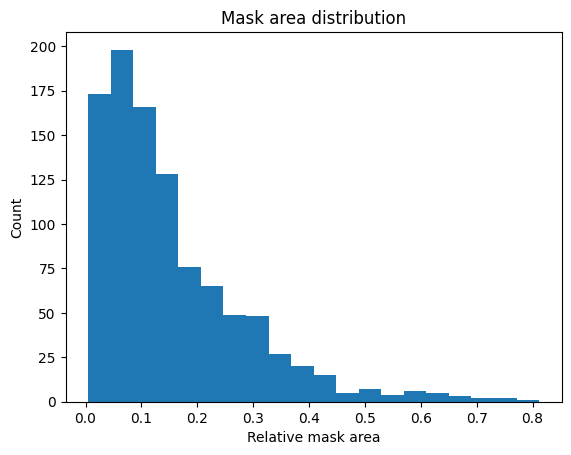

In [ ]:
areas = [((cv2.imread(row['mask'], 0) > 127).sum() / (cv2.imread(row['mask'], 0).shape[0] * cv2.imread(row['mask'], 0).shape[1])) for row in rows]
plt.hist(areas, bins=20)
plt.title("Mask area distribution")
plt.xlabel("Relative mask area")
plt.ylabel("Count")
plt.show()

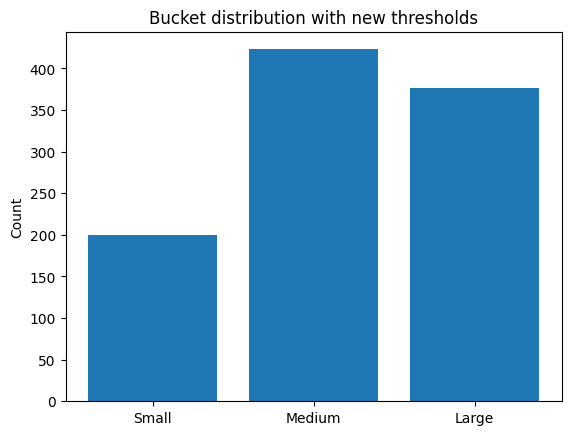

In [ ]:
import matplotlib.pyplot as plt

small = sum(a < 0.05 for a in areas)
medium = sum(0.05 <= a < 0.15 for a in areas)
large = sum(a >= 0.15 for a in areas)

plt.bar(['Small', 'Medium', 'Large'], [small, medium, large])
plt.title("Bucket distribution with new thresholds")
plt.ylabel("Count")
plt.show()

### b. nerthus-frames

In [ ]:
# ============================
# Nerthus frames (folders 0..K) -> CSVs
# ============================
import os, glob, random
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

random.seed(123)

# >>> EDIT THIS <<<
NERTHUS_FRAMES_ROOT = "/content/drive/My Drive/COMP8539/Final_Project/nerthus_videos/nerthus/nerthus-dataset-frames"

# output CSVs
TRAIN_CSV = "/content/drive/My Drive/COMP8539/Final_Project/processed/bbpsq_train.csv"
VAL_CSV   = "/content/drive/My Drive/COMP8539/Final_Project/processed/bbpsq_val.csv"
VAL_FRAC  = 0.15

rows = []
# expect subfolders named "0", "1", "2", "3" (or more)
for d in sorted(os.listdir(NERTHUS_FRAMES_ROOT)):
    sub = os.path.join(NERTHUS_FRAMES_ROOT, d)
    if not os.path.isdir(sub):
        continue
    # only accept integer folder names as labels
    try:
        label = int(d)
    except:
        continue
    # collect images
    for ext in ("*.jpg","*.jpeg","*.png"):
        for p in glob.glob(os.path.join(sub, ext)):
            rows.append({"image": p, "label": label})

df = pd.DataFrame(rows)
if df.empty:
    raise SystemExit(f"No frames found under {NERTHUS_FRAMES_ROOT}. Check the path.")

# compact to 0..C-1 if labels are not already dense
uniq = sorted(df["label"].unique().tolist())
remap = {old:i for i,old in enumerate(uniq)}
df["label"] = df["label"].map(remap)

print("Label mapping:", remap)
print(df.groupby("label").size())

train_df, val_df = train_test_split(
    df, test_size=VAL_FRAC, stratify=df["label"], random_state=123
)
Path(Path(TRAIN_CSV).parent).mkdir(parents=True, exist_ok=True)
train_df.to_csv(TRAIN_CSV, index=False)
val_df.to_csv(VAL_CSV, index=False)
print(f"Saved {TRAIN_CSV} ({len(train_df)}) and {VAL_CSV} ({len(val_df)})")

Label mapping: {0: 0, 1: 1, 2: 2, 3: 3}
label
0     500
1    2700
2     975
3    1350
dtype: int64
Saved /content/drive/My Drive/COMP8539/Final_Project/processed/bbpsq_train.csv (4696) and /content/drive/My Drive/COMP8539/Final_Project/processed/bbpsq_val.csv (829)


### c. kvasir-instrument

In [ ]:
# ============================
# Instrument presence dataset builder:
#   - Negatives: Kvasir-SEG images  (label 0)
#   - Positives: Kvasir-Instrument images (label 1)
# ============================
import os, glob, random, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

random.seed(123)

# <<< EDIT THESE >>>
KSEG_IMG_DIR = "/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/images"
KINST_IMG_DIR = "/content/drive/My Drive/COMP8539/Final_Project/kvasir_instrument/kvasir-instrument/images/images"

OUT_TRAIN = "/content/drive/My Drive/COMP8539/Final_Project/processed/instrument_train.csv"
OUT_VAL   = "/content/drive/My Drive/COMP8539/Final_Project/processed/instrument_val.csv"
VAL_FRAC  = 0.15
MAX_PER_CLASS = 560   # e.g. 500 to cap each side; or None to use all

def list_imgs(root):
    paths=[]
    for ext in ("*.jpg","*.jpeg","*.png"):
        paths += glob.glob(os.path.join(root, ext))
    return sorted(paths)

neg = list_imgs(KSEG_IMG_DIR)      # label 0 (assumed no tool)
pos = list_imgs(KINST_IMG_DIR)     # label 1 (has tool)

if MAX_PER_CLASS:
    random.shuffle(neg); random.shuffle(pos)
    neg = neg[:MAX_PER_CLASS]; pos = pos[:MAX_PER_CLASS]

print(f"Negatives (no tool): {len(neg)}  |  Positives (tool): {len(pos)}")

df0 = pd.DataFrame({"image": neg, "label": 0})
df1 = pd.DataFrame({"image": pos, "label": 1})
df  = pd.concat([df0, df1], ignore_index=True)
print("Class counts:\n", df["label"].value_counts())

# Stratified split
train_df, val_df = train_test_split(df, test_size=VAL_FRAC, stratify=df["label"], random_state=123)
Path(Path(OUT_TRAIN).parent).mkdir(parents=True, exist_ok=True)
train_df.to_csv(OUT_TRAIN, index=False)
val_df.to_csv(OUT_VAL, index=False)
print("Saved:")
print("  ", OUT_TRAIN, dict(train_df["label"].value_counts()))
print("  ", OUT_VAL,   dict(val_df["label"].value_counts()))


Negatives (no tool): 560  |  Positives (tool): 560
Class counts:
 label
0    560
1    560
Name: count, dtype: int64
Saved:
   /content/drive/My Drive/COMP8539/Final_Project/processed/instrument_train.csv {0: np.int64(476), 1: np.int64(476)}
   /content/drive/My Drive/COMP8539/Final_Project/processed/instrument_val.csv {1: np.int64(84), 0: np.int64(84)}


## 3. Train constraint heads (segmenter + classifiers)

We will train:

* U-Net polyp segmenter (U-Net with ResNet34 encoder via segmentation-models-pytorch).

* Size classifier (ResNet-18) — predicts small/med/large from crop.

* (Optional later) BBPS prep classifier and instrument classifier — start with size + segmenter as MVP.

### a. Training utilities & dataset class

In [ ]:
# Utility dataset classes for classifier & segmentation
import torch, torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import pandas as pd
import numpy as np
from pathlib import Path
import random

In [ ]:
class PolypSegDataset(Dataset):
    def __init__(self, manifest_csv, transform=None):
        self.df = pd.read_csv(manifest_csv)       # Load CSV with image/mask paths
        self.transform = transform                # Store transform (can be torchvision transforms)

    def __len__(self):
        return len(self.df)                       # Number of samples

    def __getitem__(self, idx):
        row = self.df.iloc[idx]                   # Get row from dataframe
        img = Image.open(row['image']).convert('RGB')  # Load image
        mask = Image.open(row['mask']).convert('L')    # Load mask in grayscale

        if self.transform:
            img = self.transform(img)             # Apply transforms to image

            # Resize mask to match image if necessary
            mask = T.Resize(img.shape[1:])(mask) if hasattr(T, 'Resize') else mask

            mask = T.ToTensor()(mask)             # Convert mask to tensor [1, H, W]
        else:
            img = T.ToTensor()(img)               # Default transform if none given
            mask = T.ToTensor()(mask)

        # Binarize the mask: all values > 0.5 → 1, else 0
        mask = (mask > 0.5).float()
        return img, mask

In [ ]:
class PolypCropClsDataset(Dataset):
    def __init__(self, manifest_csv, transform=None, crop=True):
        self.df = pd.read_csv(manifest_csv)       # Load CSV with image/mask paths & labels
        self.transform = transform
        self.crop = crop                          # Whether to crop around polyp

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image']).convert('RGB')
        mask = Image.open(row['mask']).convert('L')

        if self.crop:
            arr = np.array(mask)                   # Convert mask to NumPy array
            ys, xs = np.where(arr > 127)           # Get coordinates of polyp pixels
            if len(xs) == 0:
                crop_im = img                      # If no polyp, use full image
            else:
                # Compute bounding box around polyp
                x0, x1 = xs.min(), xs.max()
                y0, y1 = ys.min(), ys.max()

                # Add padding to the bounding box
                pad = 10
                w, h = img.size
                x0 = max(0, x0 - pad)
                x1 = min(w, x1 + pad)
                y0 = max(0, y0 - pad)
                y1 = min(h, y1 + pad)

                crop_im = img.crop((x0, y0, x1, y1))  # Crop image
        else:
            crop_im = img

        # Convert text labels to numeric labels
        label_map = {"small": 0, "medium": 1, "large": 2}
        label = label_map[row['size_bucket']]

        # Apply transforms if provided
        if self.transform:
            crop_im = self.transform(crop_im)
        else:
            crop_im = T.ToTensor()(crop_im)

        return crop_im, label


### b. Train U-Net Segmenter

In [ ]:
!pip install segmentation-models-pytorch --quiet

In [ ]:
set_seed(42)

In [ ]:
# Custom combined loss

import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)
        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice

class ComboLoss(nn.Module):
    def __init__(self, dice_weight=1.0, bce_weight=1.0):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, preds, targets):
        dice_loss = self.dice(preds, targets)
        bce_loss = self.bce(preds, targets)
        return self.dice_weight * dice_loss + self.bce_weight * bce_loss

In [ ]:
from tqdm import tqdm

# Train a small U-Net segmenter (segmentation-models-pytorch)
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split

manifest = '/content/drive/My Drive/COMP8539/Final_Project/processed/kvasir_kv_manifest.csv'
transform = T.Compose([T.Resize((256,256)), T.ToTensor()])
ds = PolypSegDataset(manifest, transform=transform)
# split
train_n = int(0.9*len(ds))
val_n = len(ds)-train_n
train_ds, val_ds = random_split(ds, [train_n, val_n])
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels=3, classes=1).to(device)
# loss_fn = smp.utils.losses.DiceLoss(mode='binary') + nn.BCEWithLogitsLoss()
loss_fn = ComboLoss(dice_weight=0.7, bce_weight=0.3)
opt = optim.Adam(model.parameters(), lr=1e-4)

train_losses = []
val_losses = []

best_val = 1e9
for epoch in range(10):
    model.train()
    total_loss=0
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        imgs = imgs.to(device); masks = masks.to(device)
        logits = model(imgs)
        loss = loss_fn(logits, masks)
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()

    # val
    model.eval()
    import numpy as np
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            imgs = imgs.to(device); masks = masks.to(device)
            logits = model(imgs)
            vloss = loss_fn(logits, masks)
            val_loss += vloss.item()

    epoch_train_loss = total_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    print(f"Epoch {epoch} train_loss {total_loss/len(train_loader):.4f} val_loss {val_loss/len(val_loader):.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "/content/drive/My Drive/COMP8539/Final_Project/classifiers/seg_unet_resnet34.pth")
        print("Saved best seg model")
print("Seg training complete")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 1 [Val]: 100%|██████████| 13/13 [00:00<00:00, 13.72it/s]


Epoch 0 train_loss 0.6015 val_loss 0.4834
Saved best seg model


...

Epoch 7 train_loss 0.1069 val_loss 0.1668
Saved best seg model


Epoch 9 [Val]: 100%|██████████| 13/13 [00:00<00:00, 13.09it/s]


Epoch 8 train_loss 0.0891 val_loss 0.1517
Saved best seg model


Epoch 10 [Val]: 100%|██████████| 13/13 [00:00<00:00, 13.04it/s]

Epoch 9 train_loss 0.0780 val_loss 0.1690
Seg training complete


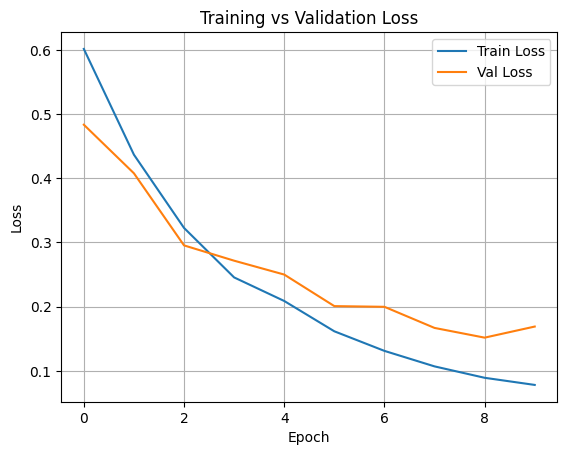

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def show_predictions(model, dataloader, device, num_samples=3):
    model.eval()
    shown = 0

    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            for i in range(imgs.size(0)):
                img = imgs[i].cpu().permute(1, 2, 0).numpy()
                mask = masks[i][0].cpu().numpy()
                pred = preds[i][0].cpu().numpy()

                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(img)
                axs[0].set_title("Input Image")
                axs[1].imshow(mask, cmap='gray')
                axs[1].set_title("Ground Truth")
                axs[2].imshow(pred, cmap='gray')
                axs[2].set_title("Prediction")

                for ax in axs:
                    ax.axis('off')

                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

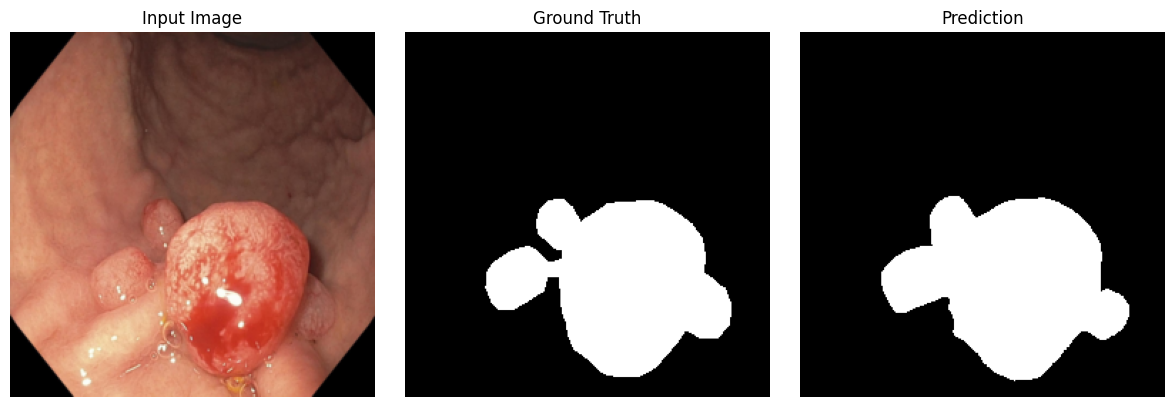

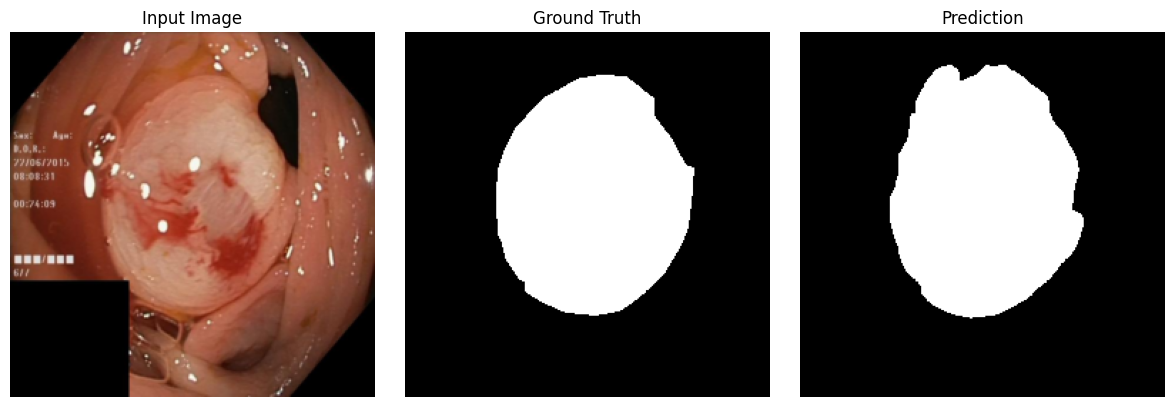

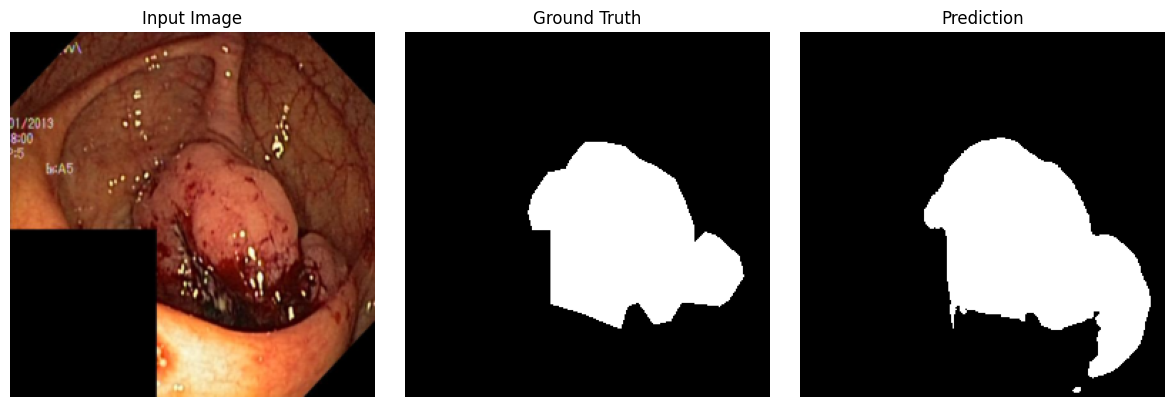

In [ ]:
# Load best model
model.load_state_dict(torch.load("/content/drive/My Drive/COMP8539/Final_Project/classifiers/seg_unet_resnet34.pth"))
model.to(device)

# Visualize predictions
show_predictions(model, val_loader, device, num_samples=3)

### c. Train a Polyp Size Classifier

In [ ]:
# Train simple ResNet-18 for size buckets
import timm, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
set_seed(42)

In [ ]:
manifest = '/content/drive/My Drive/COMP8539/Final_Project/processed/kvasir_kv_manifest.csv'
transform_cls = T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize([0.5]*3,[0.5]*3)])
dscls = PolypCropClsDataset(manifest, transform=transform_cls, crop=True)
train_n = int(0.9*len(dscls)); val_n = len(dscls)-train_n
tr_ds, val_ds = random_split(dscls, [train_n, val_n])
tr_loader = DataLoader(tr_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cls = timm.create_model('resnet18', pretrained=True, num_classes=3).to(device)
crit = nn.CrossEntropyLoss()
opt = optim.AdamW(model_cls.parameters(), lr=2e-4)

train_losses = []
val_losses = []

best_acc = 0
for epoch in range(10):
    model_cls.train()
    total, correct, running_loss = 0, 0, 0
    for imgs, labels in tqdm(tr_loader, desc=f"Epoch {epoch+1} [Train]"):
        imgs = imgs.to(device); labels = labels.to(device)
        logits = model_cls(imgs)
        loss = crit(logits, labels)
        opt.zero_grad(); loss.backward(); opt.step()

        running_loss += loss.item()
        preds = logits.argmax(1)
        correct += (preds==labels).sum().item(); total += labels.size(0)
    acc = correct/total
    avg_train_loss = running_loss / len(tr_loader)
    train_losses.append(avg_train_loss)

    # val
    model_cls.eval()
    total, correct, val_loss = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            imgs = imgs.to(device); labels = labels.to(device)
            logits = model_cls(imgs)
            loss = crit(logits, labels)
            preds = logits.argmax(1)
            val_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    vacc = correct/total
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1} | Train Acc: {acc:.4f} | Val Acc: {vacc:.4f}")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if vacc > best_acc:
        best_acc = vacc
        torch.save(model_cls.state_dict(), "/content/drive/My Drive/COMP8539/Final_Project/classifiers/size_cls_resnet18.pth")
        print("Saved best size classifier")

print("Size classifier training done")

Epoch 1 [Val]: 100%|██████████| 7/7 [00:01<00:00,  6.58it/s]


Epoch 1 | Train Acc: 0.6333 | Val Acc: 0.6900
Train Loss: 0.8989 | Val Loss: 0.7540
Saved best size classifier


Epoch 2 [Val]: 100%|██████████| 7/7 [00:00<00:00, 10.41it/s]


Epoch 2 | Train Acc: 0.7478 | Val Acc: 0.7800
Train Loss: 0.6330 | Val Loss: 0.5517
Saved best size classifier


Epoch 3 [Val]: 100%|██████████| 7/7 [00:00<00:00,  7.79it/s]


...

Epoch 8 | Train Acc: 0.9533 | Val Acc: 0.8600
Train Loss: 0.1657 | Val Loss: 0.4049
Saved best size classifier


Epoch 9 [Val]: 100%|██████████| 7/7 [00:00<00:00,  9.19it/s]


Epoch 9 | Train Acc: 0.9856 | Val Acc: 0.8500
Train Loss: 0.0889 | Val Loss: 0.3975


Epoch 10 [Val]: 100%|██████████| 7/7 [00:00<00:00, 10.37it/s]

Epoch 10 | Train Acc: 0.9822 | Val Acc: 0.8200
Train Loss: 0.0777 | Val Loss: 0.4613
Size classifier training done


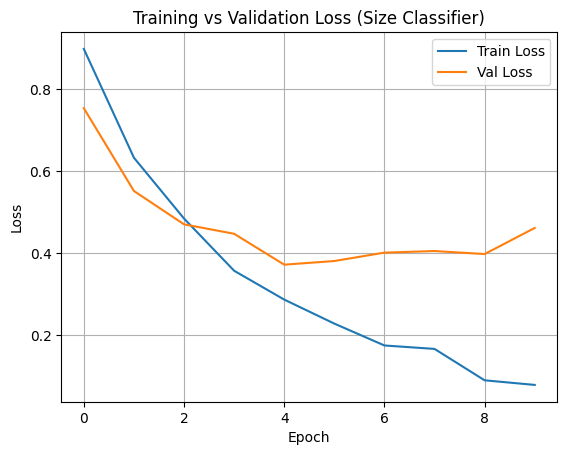

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Size Classifier)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def show_class_predictions(model, dataloader, device, label_map, num_samples=5):
    model.eval()
    shown = 0
    inv_label_map = {v: k for k, v in label_map.items()}  # reverse mapping

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            logits = model(imgs)
            preds = logits.argmax(1)

            for i in range(imgs.size(0)):
                img = imgs[i].cpu().permute(1, 2, 0).numpy()
                img = (img * 0.5 + 0.5).clip(0, 1)  # unnormalize

                true_label = inv_label_map[labels[i].item()]
                pred_label = inv_label_map[preds[i].item()]

                plt.imshow(img)
                plt.title(f"True: {true_label} | Pred: {pred_label}")
                plt.axis('off')
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

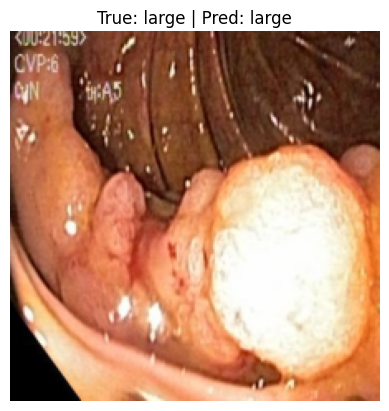

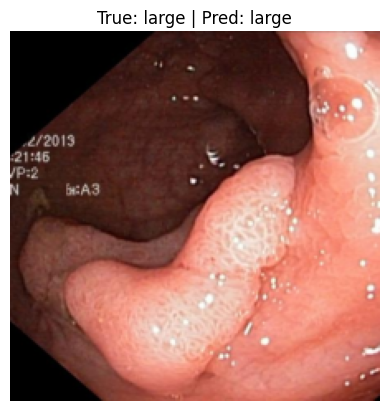

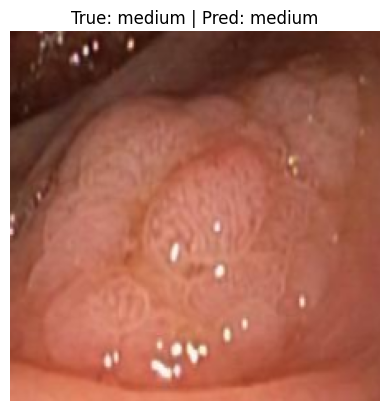

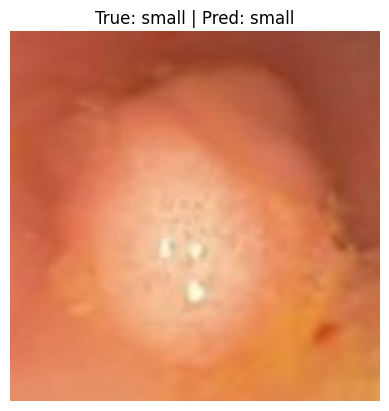

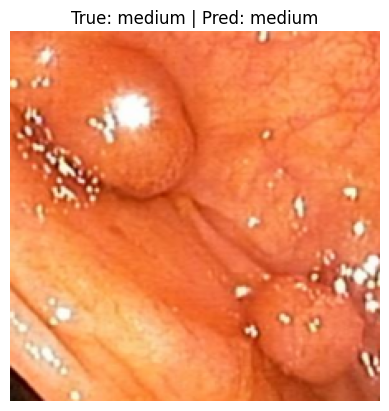

In [ ]:
label_map = {"small": 0, "medium": 1, "large": 2}
model_cls.load_state_dict(torch.load("/content/drive/My Drive/COMP8539/Final_Project/classifiers/size_cls_resnet18.pth"))
show_class_predictions(model_cls, val_loader, device, label_map, num_samples=5)

### d. instrument presence classifier

In [ ]:
import torch, timm, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from PIL import Image
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN_CSV = "/content/drive/My Drive/COMP8539/Final_Project/processed/instrument_train.csv"
VAL_CSV   = "/content/drive/My Drive/COMP8539/Final_Project/processed/instrument_val.csv"
OUT_PTH   = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/instrument_resnet18.pth"

IMG_SIZE=224; BATCH=32; EPOCHS=8; LR=2e-4; WD=1e-4; WORKERS=2

class ImgCSVDataset(Dataset):
    def __init__(self, csv_path, tfm):
        self.df = pd.read_csv(csv_path); self.tfm = tfm
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        x = Image.open(r["image"]).convert("RGB")
        x = self.tfm(x); y = int(r["label"])
        return x, y

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.RandomApply([T.ColorJitter(0.2,0.2,0.1,0.02)], p=0.3),
    T.RandomApply([T.GaussianBlur(3, (0.1,1.5))], p=0.2),
    T.ToTensor(), T.Normalize([0.5]*3,[0.5]*3)
])
val_tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize([0.5]*3,[0.5]*3)])

tr_ds = ImgCSVDataset(TRAIN_CSV, train_tf)
va_ds = ImgCSVDataset(VAL_CSV,   val_tf)

labels = tr_ds.df["label"].values
binc = np.bincount(labels, minlength=2); binc[binc==0]=1
weights = 1.0 / binc[labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

tr_loader = DataLoader(tr_ds, batch_size=BATCH, sampler=sampler, num_workers=WORKERS, pin_memory=True)
va_loader = DataLoader(va_ds, batch_size=BATCH, shuffle=False, num_workers=WORKERS, pin_memory=True)

model = timm.create_model("resnet18", pretrained=True, num_classes=2).to(DEVICE)
crit = nn.CrossEntropyLoss()
opt  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

def eval_model(m, dl):
    m.eval(); ys=[]; ps=[]
    with torch.no_grad():
        for x,y in dl:
            x=x.to(DEVICE); yhat=m(x).argmax(1).cpu().numpy()
            ys.append(y.numpy()); ps.append(yhat)
    y=np.concatenate(ys); p=np.concatenate(ps)
    return {
        "acc": accuracy_score(y,p),
        "f1m": f1_score(y,p, average="macro"),
        "y_true": y, "y_pred": p
    }

best_f1=-1
for e in range(1,EPOCHS+1):
    model.train(); tot=0;n=0
    for x,y in tr_loader:
        x=x.to(DEVICE); y=y.to(DEVICE)
        loss=crit(model(x), y)
        opt.zero_grad(set_to_none=True); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        tot+=loss.item()*x.size(0); n+=x.size(0)
    sch.step()
    m=eval_model(model, va_loader)
    print(f"Epoch {e:02d}  tr_loss={tot/max(1,n):.4f}  val_acc={m['acc']:.3f}  val_f1m={m['f1m']:.3f}")
    if m["f1m"]>best_f1:
        best_f1=m["f1m"]; Path(Path(OUT_PTH).parent).mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), OUT_PTH); print("  ↳ saved best:", OUT_PTH)

# Final report
from sklearn.metrics import classification_report, confusion_matrix
model.load_state_dict(torch.load(OUT_PTH, map_location=DEVICE))
rep = eval_model(model, va_loader)
print("\nConfusion matrix:\n", confusion_matrix(rep["y_true"], rep["y_pred"]))
print("\nClassification report:\n", classification_report(rep["y_true"], rep["y_pred"], digits=3))
print("\nSaved:", OUT_PTH)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Epoch 01  tr_loss=0.5706  val_acc=0.935  val_f1m=0.934
  ↳ saved best: /content/drive/My Drive/COMP8539/Final_Project/classifiers/instrument_resnet18.pth
Epoch 02  tr_loss=0.2407  val_acc=0.994  val_f1m=0.994
  ↳ saved best: /content/drive/My Drive/COMP8539/Final_Project/classifiers/instrument_resnet18.pth
Epoch 03  tr_loss=0.0982  val_acc=0.994  val_f1m=0.994
Epoch 04  tr_loss=0.0644  val_acc=1.000  val_f1m=1.000
  ↳ saved best: /content/drive/My Drive/COMP8539/Final_Project/classifiers/instrument_resnet18.pth
Epoch 05  tr_loss=0.0472  val_acc=1.000  val_f1m=1.000
Epoch 06  tr_loss=0.0493  val_acc=1.000  val_f1m=1.000
Epoch 07  tr_loss=0.0424  val_acc=0.994  val_f1m=0.994
Epoch 08  tr_loss=0.0289  val_acc=0.994  val_f1m=0.994

Confusion matrix:
 [[84  0]
 [ 0 84]]

Classification report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000        84
           1      1.000     1.000     1.000        84

    accuracy                       

### e. bowel prep quality classifier - 0-3

In [ ]:
import torch, timm, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from PIL import Image
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN_CSV = "/content/drive/My Drive/COMP8539/Final_Project/processed/bbpsq_train.csv"
VAL_CSV   = "/content/drive/My Drive/COMP8539/Final_Project/processed/bbpsq_val.csv"
OUT_PTH   = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/bbpsq_resnet18.pth"

IMG_SIZE  = 224; BATCH = 32; EPOCHS = 8; LR = 2e-4; WD = 1e-4; WORKERS = 2

class ImgCSVDataset(Dataset):
    def __init__(self, csv_path, tfm):
        self.df = pd.read_csv(csv_path); self.tfm = tfm
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        x = Image.open(r["image"]).convert("RGB")
        x = self.tfm(x); y = int(r["label"])
        return x, y

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.RandomApply([T.ColorJitter(0.2,0.2,0.1,0.02)], p=0.3),
    T.RandomApply([T.GaussianBlur(3, (0.1,1.5))], p=0.2),
    T.ToTensor(), T.Normalize([0.5]*3,[0.5]*3)
])
val_tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize([0.5]*3,[0.5]*3)])

tr_ds = ImgCSVDataset(TRAIN_CSV, train_tf)
va_ds = ImgCSVDataset(VAL_CSV,   val_tf)

NUM_CLASSES = int(pd.read_csv(TRAIN_CSV)["label"].nunique())

# imbalance-aware sampler
labels = tr_ds.df["label"].values
binc = np.bincount(labels, minlength=NUM_CLASSES); binc[binc==0] = 1
weights = 1.0 / binc[labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

tr_loader = DataLoader(tr_ds, batch_size=BATCH, sampler=sampler, num_workers=WORKERS, pin_memory=True)
va_loader = DataLoader(va_ds, batch_size=BATCH, shuffle=False, num_workers=WORKERS, pin_memory=True)

model = timm.create_model("resnet18", pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)
crit = nn.CrossEntropyLoss()
opt  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

def evaluate(m, dl):
    m.eval(); ys=[]; ps=[]
    with torch.no_grad():
        for x,y in dl:
            x=x.to(DEVICE); logits=m(x)
            pred=logits.argmax(1).cpu().numpy()
            ys.append(y.numpy()); ps.append(pred)
    y = np.concatenate(ys); p = np.concatenate(ps)
    return {
        "acc": accuracy_score(y,p),
        "f1m": f1_score(y,p, average="macro"),
        "y_true": y, "y_pred": p
    }

best_f1 = -1
for e in range(1, EPOCHS+1):
    model.train(); tot=0; n=0
    for x,y in tr_loader:
        x=x.to(DEVICE); y=y.to(DEVICE)
        loss = crit(model(x), y)
        opt.zero_grad(set_to_none=True); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        tot += loss.item()*x.size(0); n += x.size(0)
    sch.step()
    m = evaluate(model, va_loader)
    print(f"Epoch {e:02d}  tr_loss={tot/max(1,n):.4f}  val_acc={m['acc']:.3f}  val_f1m={m['f1m']:.3f}")
    if m["f1m"] > best_f1:
        best_f1 = m["f1m"]
        Path(Path(OUT_PTH).parent).mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), OUT_PTH)
        print("  ↳ saved best:", OUT_PTH)

# final report
from sklearn.metrics import classification_report, confusion_matrix
model.load_state_dict(torch.load(OUT_PTH, map_location=DEVICE))
rep = evaluate(model, va_loader)
print("\nConfusion matrix:")
print(confusion_matrix(rep["y_true"], rep["y_pred"]))
print("\nClassification report:")
print(classification_report(rep["y_true"], rep["y_pred"], digits=3))
print("\nSaved:", OUT_PTH, f"  (classes: {NUM_CLASSES})")

Epoch 01  tr_loss=0.4938  val_acc=0.998  val_f1m=0.997
  ↳ saved best: /content/drive/My Drive/COMP8539/Final_Project/classifiers/bbpsq_resnet18.pth
Epoch 02  tr_loss=0.0443  val_acc=0.999  val_f1m=0.999
  ↳ saved best: /content/drive/My Drive/COMP8539/Final_Project/classifiers/bbpsq_resnet18.pth
Epoch 03  tr_loss=0.0226  val_acc=0.998  val_f1m=0.998
Epoch 04  tr_loss=0.0096  val_acc=0.998  val_f1m=0.998
Epoch 05  tr_loss=0.0078  val_acc=0.998  val_f1m=0.998
Epoch 06  tr_loss=0.0066  val_acc=0.998  val_f1m=0.998
Epoch 07  tr_loss=0.0041  val_acc=0.998  val_f1m=0.998
Epoch 08  tr_loss=0.0044  val_acc=0.998  val_f1m=0.998

Confusion matrix:
[[ 75   0   0   0]
 [  0 404   1   0]
 [  0   0 146   0]
 [  0   0   0 203]]

Classification report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        75
           1      1.000     0.998     0.999       405
           2      0.993     1.000     0.997       146
           3      1.000     1.000  

## 4. LoRA fine-tuning of Stable Diffusion 1.5 (domain adaptation)

We’ll adapt SD-1.5 to colonoscopy images using LoRA (memory-light). I provide both:

* A direct way using Hugging Face diffusers LoRA example (recommended), and

* A minimal example call if you have the example script downloaded.



### a. Fine tuning SD v1.5 on Kvasir-SEG dataset

Fine tuning SD 1.5 using Hugging Face Lora Training Scripts

In [ ]:
# NOTE: you must accept model license on Hugging Face to download some checkpoints.
# If you have Hugging Face token:
from huggingface_hub import notebook_login
notebook_login()

* This downloads the official training scripts.

* Inside it, you'll find scripts for DreamBooth, LoRA, etc., in examples/.

In [ ]:
!git clone https://github.com/huggingface/diffusers.git /content/diffusers

Cloning into '/content/diffusers'...
remote: Enumerating objects: 103290, done.
remote: Counting objects: 100% (924/924), done.
remote: Compressing objects: 100% (496/496), done.
remote: Total 103290 (delta 755), reused 436 (delta 423), pack-reused 102366 (from 3)
Receiving objects: 100% (103290/103290), 77.55 MiB | 33.65 MiB/s, done.
Resolving deltas: 100% (76153/76153), done.


In [ ]:
!accelerate launch /content/diffusers/examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path runwayml/stable-diffusion-v1-5 \
  --instance_data_dir /content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/images \
  --output_dir /content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy \
  --train_batch_size 1 \
  --max_train_steps 2000 \
  --learning_rate 1e-4 \
  --lora_rank 8 \
  --mixed_precision 'yes'

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2025-09-02 00:16:35.968168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756772196.000533    7019 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756772196.011087    7019 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756772196.043192    7019 computation_plac

In [ ]:
!which accelerate

/usr/local/bin/accelerate


End-to-End, combined Phase 1 + Phase 2 pipeline with masked training + rich semantic captions, fully GPU-ready, memory-light via LoRA, and flexible for colonoscopy image generation.

In [ ]:
# ===============================
# 1️⃣ Imports
# ===============================
import torch
from diffusers import StableDiffusionPipeline
from peft import LoraConfig, get_peft_model, TaskType
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
from tqdm import tqdm

In [ ]:
# ===============================
# 2️⃣ Combined Dataset: Masks + Captions
# ===============================
class ColonoscopyDataset(Dataset):
    def __init__(self, image_dir, mask_dir=None, captions=None, size=512):
        self.image_paths = sorted(list(Path(image_dir).glob("*.[pj][pn]g")))
        self.mask_paths = sorted(list(Path(mask_dir).glob("*.[pj][pn]g"))) if mask_dir else [None]*len(self.image_paths)
        self.captions = captions
        self.size = size
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        image = self.transform(image)

        mask = None
        if self.mask_paths[idx]:
            mask = Image.open(self.mask_paths[idx]).convert("L")
            mask = self.transform(mask)
            image = image * mask  # apply mask

        text = self.captions[idx] if self.captions else "a photo of colonoscopy"
        return {"pixel_values": image, "text": text}

In [ ]:
# ===============================
# 3️⃣ LoRA Setup
# ===============================
lora_rank = 8
lora_config = LoraConfig(
    r=lora_rank,
    lora_alpha=16,
    target_modules=["to_q", "to_v"],
    lora_dropout=0.05,
    bias="none",
)

In [ ]:
# ===============================
# 4️⃣ Load Pretrained SD 1.5
# ===============================
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    # torch_dtype=torch.float16 # load without specifying dtype - defaults to float32
).to("cuda")

# Apply LoRA
pipe.unet = get_peft_model(pipe.unet, lora_config)
pipe.unet.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


PeftModel(
  (base_model): LoraModel(
    (model): UNet2DConditionModel(
      (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_proj): Timesteps()
      (time_embedding): TimestepEmbedding(
        (linear_1): Linear(in_features=320, out_features=1280, bias=True)
        (act): SiLU()
        (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (down_blocks): ModuleList(
        (0): CrossAttnDownBlock2D(
          (attentions): ModuleList(
            (0-1): 2 x Transformer2DModel(
              (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
              (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
              (transformer_blocks): ModuleList(
                (0): BasicTransformerBlock(
                  (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
                  (attn1): Attention(
                    (to_q): lora.Linear(
                      (base_layer): Linear(in_feat

1. Step-based training (2000 steps max)

2. Text conditioning for prompt-aware learning

3. LoRA train mode enabled

4. Mixed precision (FP16) for faster training / memory savings

5. Checkpointing every 500 steps

6. Training loss tracking & plotting

7. Post-training testing to visualize results

In [ ]:
# ============================================
# Phase 1 — Masked Domain Adaptation (Kvasir-SEG)
# Full Training + Loss Visualization + Test
# ============================================

import torch
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

In [ ]:
# ----------------------------
# Config
# ----------------------------
instance_data_dir = "/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/images"
mask_data_dir = "/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/masks"
output_dir_phase1 = "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase1_masked"

batch_size = 1
lr = 1e-4
max_train_steps_phase1 = 2000
checkpoint_interval = 500
device = "cuda"

In [ ]:
# ----------------------------
# Dataset & Dataloader
# ----------------------------
image_files = list(Path(instance_data_dir).glob("*.[pj][pn]g"))

dataset_phase1 = ColonoscopyDataset(
    image_dir=instance_data_dir,
    mask_dir=mask_data_dir,
    captions=["A colonoscopy image showing a polyp"] * len(image_files)
)
dataloader_phase1 = DataLoader(dataset_phase1, batch_size=batch_size, shuffle=True)

In [ ]:
# ----------------------------
# Optimizer & Mixed Precision
# ----------------------------
# Optimizer on trainable parameters only
optimizer = torch.optim.AdamW([p for p in pipe.unet.parameters() if p.requires_grad], lr=lr)
scaler = GradScaler()

# Ensure LoRA parameters are in train mode
pipe.unet.train()

/tmp/ipython-input-2029172819.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


PeftModel(
  (base_model): LoraModel(
    (model): UNet2DConditionModel(
      (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_proj): Timesteps()
      (time_embedding): TimestepEmbedding(
        (linear_1): Linear(in_features=320, out_features=1280, bias=True)
        (act): SiLU()
        (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (down_blocks): ModuleList(
        (0): CrossAttnDownBlock2D(
          (attentions): ModuleList(
            (0-1): 2 x Transformer2DModel(
              (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
              (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
              (transformer_blocks): ModuleList(
                (0): BasicTransformerBlock(
                  (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
                  (attn1): Attention(
                    (to_q): lora.Linear(
                      (base_layer): Linear(in_feat

In [ ]:
from itertools import cycle

# ----------------------------
# Training Loop (with cycling)
# ----------------------------
loss_history = []

data_iter = cycle(dataloader_phase1)  # infinite iterator

for step in tqdm(range(max_train_steps_phase1)):
    batch = next(data_iter)  # keep pulling forever

    optimizer.zero_grad()

    # 1️⃣ Text Conditioning
    encoder_hidden_states = pipe.text_encoder(
        pipe.tokenizer(
            batch["text"],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=77
        ).input_ids.to(device)
    )[0]

    # 2️⃣ Encode Image to Latent Space
    latents = pipe.vae.encode(
        batch["pixel_values"].to(device=device, dtype=pipe.vae.dtype)
    ).latent_dist.sample() * 0.18215

    # 3️⃣ Sample Noise and Timesteps
    noise = torch.randn_like(latents)
    timesteps = torch.randint(0, pipe.scheduler.num_train_timesteps, (latents.shape[0],), device=device).long()
    noisy_latents = pipe.scheduler.add_noise(latents, noise, timesteps)

    # 4️⃣ Forward Pass with Mixed Precision
    with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
        noise_pred = pipe.unet(noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

    # 5️⃣ Backward Pass + Optimizer Step
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    loss_history.append(loss.item())

    # Logging
    if step % 50 == 0:
        print(f"[Phase1] Step {step} | Loss: {loss.item():.4f}")

    # Checkpoint saving
    if step % checkpoint_interval == 0 and step > 0:
        save_path = f"{output_dir_phase1}/checkpoint_{step}"
        pipe.unet.save_pretrained(save_path)
        print(f"Checkpoint saved at {save_path}")


  0%|          | 0/2000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:140: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'PNDMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'PNDMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
  0%|          | 1/2000 [00:04<2:30:34,  4.52s/it]

[Phase1] Step 0 | Loss: 0.0981


  3%|▎         | 51/2000 [00:56<33:45,  1.04s/it]

[Phase1] Step 50 | Loss: 0.1322


  5%|▌         | 101/2000 [01:48<32:09,  1.02s/it]

...

 95%|█████████▌| 1901/2000 [32:24<01:40,  1.01s/it]

[Phase1] Step 1900 | Loss: 0.0076


 98%|█████████▊| 1951/2000 [33:14<00:49,  1.01s/it]

[Phase1] Step 1950 | Loss: 0.0023


100%|██████████| 2000/2000 [34:04<00:00,  1.02s/it]


In [ ]:
# ----------------------------
# Final Save
# ----------------------------
pipe.unet.save_pretrained(output_dir_phase1)
print(f"Phase 1 LoRA weights saved at {output_dir_phase1}")

Phase 1 LoRA weights saved at /content/lora_colonoscopy_phase1_masked


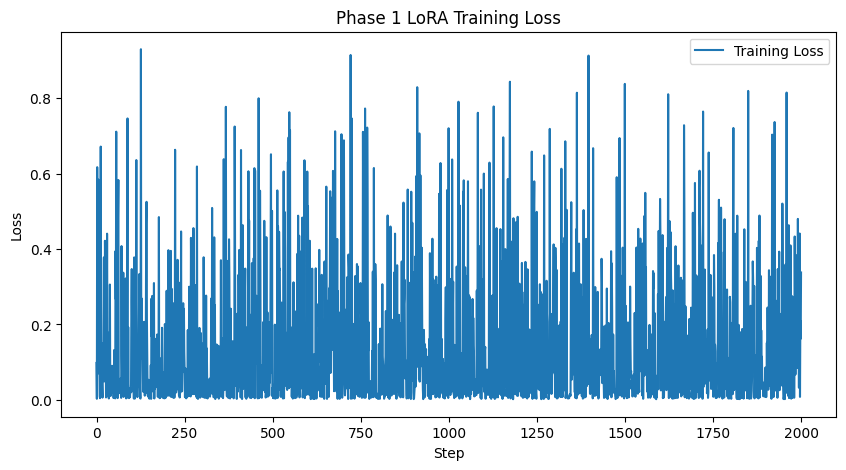

In [ ]:
# ----------------------------
# Training Loss Visualization
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(loss_history, label="Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Phase 1 LoRA Training Loss")
plt.legend()
plt.show()

In [ ]:
from diffusers.pipelines.stable_diffusion import StableDiffusionSafetyChecker

# Disable safety checker
pipe.safety_checker = lambda images, **kwargs: (images, [False] * len(images))

  0%|          | 0/50 [00:00<?, ?it/s]

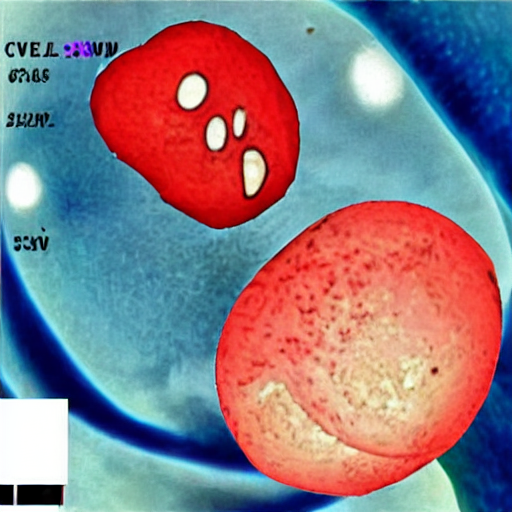

  0%|          | 0/50 [00:00<?, ?it/s]

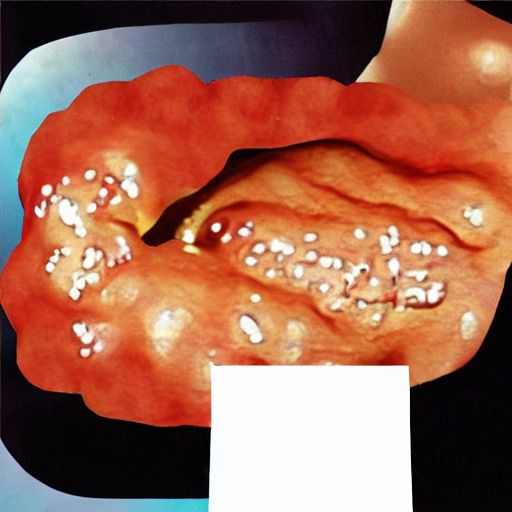

In [ ]:
# ----------------------------
# Post-Training Test / Inference
# ----------------------------
from IPython.display import display

pipe.unet.eval()

test_prompts = [
    "A colonoscopy image showing a polyp",
    "Endoscopic view of gastrointestinal tract"
]

# for prompt in test_prompts:
#     # Tokenize text
#     encoder_hidden_states = pipe.text_encoder(
#         pipe.tokenizer(prompt, return_tensors="pt", padding="max_length", truncation=True, max_length=77).input_ids.to(device)
#     )[0]

#     # Generate random latent noise
#     latents = torch.randn((1, pipe.unet.in_channels, 64, 64), device=device)

#     # Diffusion steps
#     for t in reversed(range(pipe.scheduler.num_train_timesteps)):
#         with torch.no_grad(), autocast():
#             noise_pred = pipe.unet(latents, torch.tensor([t], device=device), encoder_hidden_states=encoder_hidden_states).sample
#         latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

#     # Decode latent to image
#     image = pipe.vae.decode(latents / 0.18215).sample
#     image = (image / 2 + 0.5).clamp(0,1)  # normalize to [0,1]

#     # Convert to PIL and show
#     pil_image = pipe.numpy_to_pil(image)[0]
#     pil_image.show()
for prompt in test_prompts:
    with torch.autocast("cuda"):
        image = pipe(prompt).images[0]
    # image.show()
    # Instead of image.show()
    display(image)

To Load SafeTensors

In [ ]:
from diffusers import StableDiffusionPipeline
from peft import PeftModel

# Load base model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

# Apply LoRA
pipe.unet = PeftModel.from_pretrained(pipe.unet, "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase1_masked")

### b. Fine tuning prev SD v1.5 on HyperKvasir-SEG dataset

In [ ]:
# ============================================
# Phase 2 — Rich Prompt Conditioning (HyperKvasir)
# Training + Loss Visualization + Inference
# ============================================

import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
from torchvision import transforms
from itertools import cycle
from tqdm import tqdm
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline
from peft import LoraConfig, get_peft_model
from torch.cuda.amp import autocast, GradScaler
from IPython.display import display

In [ ]:
import pandas as pd

class HyperKvasirDataset(Dataset):
    def __init__(self, root_dir, csv_file, size=512):
        """
        root_dir: folder containing subfolders (e.g. lower_gi_tract, upper_gi_tract)
        csv_file: path to image_labels.csv
        """
        self.root_dir = Path(root_dir)
        self.df = pd.read_csv(csv_file)
        self.size = size

        # Image transform
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

        # Build full paths + captions
        self.samples = []
        for _, row in self.df.iterrows():
            img_id = row["Video file"]  # e.g. 000e3fee-7f5c-4819-9f9c-4c983b68888a
            organ = row["Organ"]
            finding = row["Finding"]
            classification = row["Classification"]

            # Search across all subfolders for this ID
            img_path = list(self.root_dir.rglob(f"{img_id}.*"))
            if len(img_path) == 0:
                continue  # skip if not found
            img_path = img_path[0]

            # Caption template
            caption = f"A colonoscopy image of the {organ}, showing {finding}, classified as {classification}."

            self.samples.append((img_path, caption))

        print(f"Loaded {len(self.samples)} image-caption pairs from HyperKvasir")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, caption = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        return {"pixel_values": image, "text": caption}


In [ ]:
# ========
# Config
# ========

hyper_image_dir = "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/labeled_images/labeled-images"
hyper_labels_file = "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/labeled_images/labeled-images/image-labels.csv"  # mapping: img_name → label

output_dir_phase2 = "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase2_hyper"

batch_size = 1
lr = 5e-5
max_train_steps_phase2 = 1500
checkpoint_interval = 500
device = "cuda"

In [ ]:
import os

path = "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase1_masked"
print(os.listdir(path))

['README.md', 'adapter_config.json', 'adapter_model.safetensors']


In [ ]:
# ----------------------------
# Load Phase 1 model + Apply LoRA
# ----------------------------
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
).to(device)

# Load Phase1 LoRA weights
pipe.unet = get_peft_model(pipe.unet, LoraConfig(
    r=8, lora_alpha=16, target_modules=["to_q", "to_v"], lora_dropout=0.05, bias="none"
))
pipe.unet.load_adapter("/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase1_masked", adapter_name="phase1_masked")
pipe.unet.train()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


PeftModel(
  (base_model): LoraModel(
    (model): UNet2DConditionModel(
      (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_proj): Timesteps()
      (time_embedding): TimestepEmbedding(
        (linear_1): Linear(in_features=320, out_features=1280, bias=True)
        (act): SiLU()
        (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (down_blocks): ModuleList(
        (0): CrossAttnDownBlock2D(
          (attentions): ModuleList(
            (0-1): 2 x Transformer2DModel(
              (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
              (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
              (transformer_blocks): ModuleList(
                (0): BasicTransformerBlock(
                  (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
                  (attn1): Attention(
                    (to_q): lora.Linear(
                      (base_layer): Linear(in_feat

In [ ]:
# dataset_phase2 = HyperKvasirDataset(image_dir=hyper_image_dir, captions=captions)
# dataloader_phase2 = DataLoader(dataset_phase2, batch_size=batch_size, shuffle=True)

In [ ]:
# ----------------------------
# Dataset with Rich Prompts
# ----------------------------
# captions = []
# image_paths = []

# with open(hyper_labels_file, "r") as f:
#     for line in f:
#         img, label = line.strip().split("\t")
#         image_paths.append(Path(hyper_image_dir)/img)
#         captions.append(f"A colonoscopy image showing {label}")

dataset_phase2 = HyperKvasirDataset(
    root_dir=hyper_image_dir,
    csv_file=hyper_labels_file,
    size=512
)
dataloader_phase2 = DataLoader(dataset_phase2, batch_size=batch_size, shuffle=True)

Loaded 10662 image-caption pairs from HyperKvasir


In [ ]:
# ----------------------------
# Optimizer
# ----------------------------
optimizer = torch.optim.AdamW([p for p in pipe.unet.parameters() if p.requires_grad], lr=lr)
scaler = GradScaler()

/tmp/ipython-input-3305686625.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
# ----------------------------
# Training Loop (same structure as Phase 1)
# ----------------------------
from itertools import cycle

data_iter = cycle(dataloader_phase2)
loss_history_phase2 = []

for step in tqdm(range(max_train_steps_phase2)):
    batch = next(data_iter)
    optimizer.zero_grad()

    # 1️⃣ Text Conditioning
    encoder_hidden_states = pipe.text_encoder(
        pipe.tokenizer(batch["text"], return_tensors="pt", padding="max_length", truncation=True, max_length=77).input_ids.to(device)
    )[0]

    # 2️⃣ Encode Image -> Latent
    latents = pipe.vae.encode(
        batch["pixel_values"].to(device=device, dtype=pipe.vae.dtype)
    ).latent_dist.sample() * 0.18215

    # 3️⃣ Add Noise
    noise = torch.randn_like(latents)
    timesteps = torch.randint(0, pipe.scheduler.num_train_timesteps, (latents.shape[0],), device=device).long()
    noisy_latents = pipe.scheduler.add_noise(latents, noise, timesteps)

    # 4️⃣ Forward + Loss
    with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
        noise_pred = pipe.unet(noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

    # 5️⃣ Backprop
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    loss_history_phase2.append(loss.item())

    if step % 50 == 0:
        print(f"[Phase2] Step {step} | Loss: {loss.item():.4f}")

    if step % checkpoint_interval == 0 and step > 0:
        save_path = f"{output_dir_phase2}/checkpoint_{step}"
        pipe.unet.save_pretrained(save_path)
        print(f"Checkpoint saved at {save_path}")

  0%|          | 0/1500 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:140: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'PNDMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'PNDMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
  0%|          | 1/1500 [00:04<1:49:12,  4.37s/it]

[Phase2] Step 0 | Loss: 0.6667


  3%|▎         | 51/1500 [00:59<26:42,  1.11s/it]

[Phase2] Step 50 | Loss: 0.3267


  7%|▋         | 101/1500 [01:52<25:04,  1.08s/it]

...

 93%|█████████▎| 1401/1500 [25:18<01:46,  1.07s/it]

[Phase2] Step 1400 | Loss: 0.3136


 97%|█████████▋| 1451/1500 [26:12<00:52,  1.08s/it]

[Phase2] Step 1450 | Loss: 0.0998


100%|██████████| 1500/1500 [27:05<00:00,  1.08s/it]


In [ ]:
# ----------------------------
# Final Save
# ----------------------------
pipe.unet.save_pretrained(output_dir_phase2)
print(f"Phase 2 LoRA weights saved at {output_dir_phase2}")

Phase 2 LoRA weights saved at /content/lora_colonoscopy_phase2_hyper


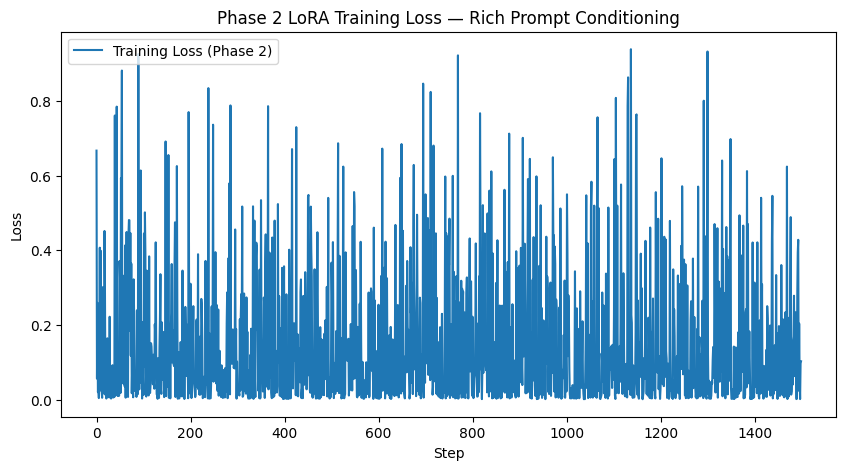

In [ ]:
# ----------------------------
# Training Loss Visualization
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(loss_history_phase2, label="Training Loss (Phase 2)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Phase 2 LoRA Training Loss — Rich Prompt Conditioning")
plt.legend()
plt.show()

  0%|          | 0/35 [00:00<?, ?it/s]

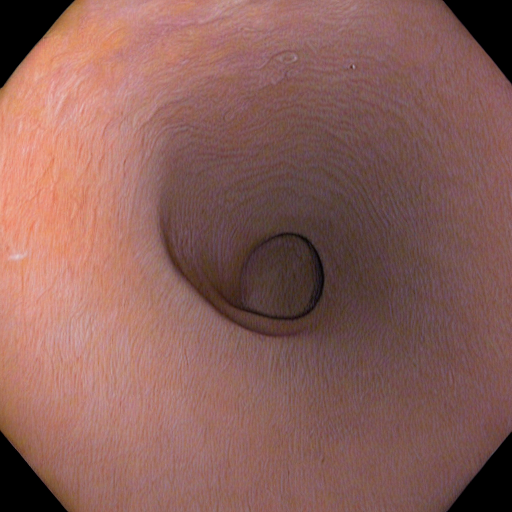

  0%|          | 0/35 [00:00<?, ?it/s]

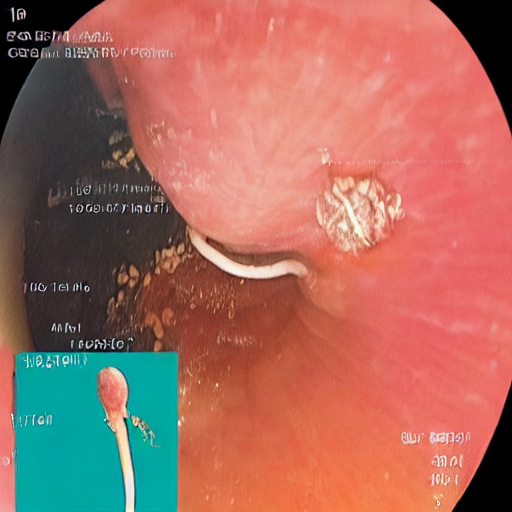

  0%|          | 0/35 [00:00<?, ?it/s]

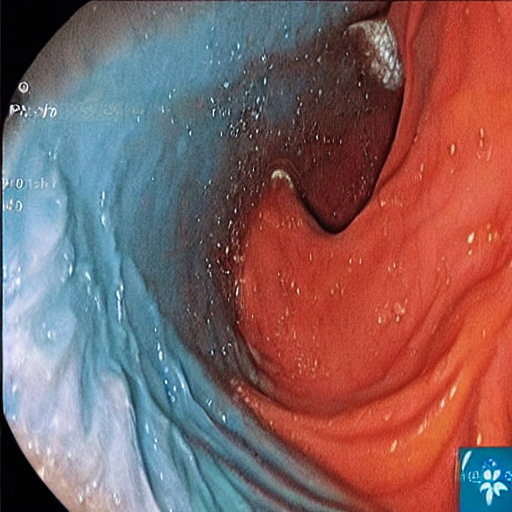

  0%|          | 0/35 [00:00<?, ?it/s]

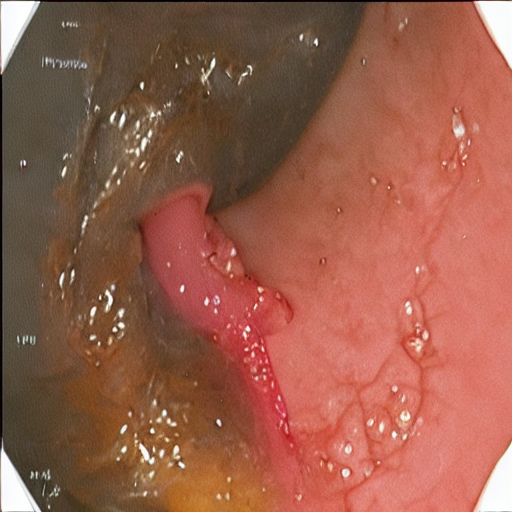

In [ ]:
# ----------------------------
# Post-Training Inference
# ----------------------------
pipe.unet.eval()
pipe.safety_checker = lambda images, **kwargs: (images, [False] * len(images))

test_prompts = [
    "Colonoscopy image showing a polyp",
    "Endoscopic image of colon with inflammation",
    "Image of normal GI tract during colonoscopy",
    "Ulcerated lesion in gastrointestinal endoscopy"
]

for prompt in test_prompts:
    with torch.autocast("cuda"):
        image = pipe(prompt, num_inference_steps=35, guidance_scale=8.5).images[0]
    display(image)

## 5. ControlNet Mask Conditioning

1. Prepares the dataset (Kvasir-SEG first → then HyperKvasir-SEG using CSV), converting to matched (image,control) pairs at 512×512.

2. Builds a ControlNet training loop using your Phase-2 Stable Diffusion as the base.

3. Uses a pre-existing ControlNet checkpoint as the adapter start (recommended) and fine-tunes it on your masks.

4. Uses mixed precision during training (FP32 weights, FP16 compute via autocast).

5. Trains with accelerate for proper device + multi-GPU support.

6. Regular checkpointing and visual validation samples every val_interval steps.

7. Tracks + plots loss at the end and saves final ControlNet adapter.

In [ ]:
# =======================================================
# End-to-end ControlNet training (Kvasir -> HyperKvasir)
# Uses: Phase2 base Stable Diffusion model + ControlNet adapter
# =======================================================

# 0) Install deps (run if needed)
# !pip install -q diffusers accelerate transformers safetensors datasets --upgrade
# !pip install -q "accelerate>=0.17.0" "diffusers>=0.26.0"  # adjust if you already have them
# !pip install -q opencv-python matplotlib pandas

import os
import math
import glob
import shutil
from pathlib import Path
from tqdm import tqdm
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image

from accelerate import Accelerator
from diffusers import (
    ControlNetModel,
    StableDiffusionControlNetPipeline,
    DDPMScheduler,
)

In [ ]:
# -------------------------
# ============= Config ============
# -------------------------
# Paths (edit these)
phase2_base_model = "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase2_hyper"   # your Phase2 model path (stable-diffusion pipeline dir)
kvasir_img_dir = "/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/images"
kvasir_mask_dir = "/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/masks"

hyper_root_dir = "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/labeled_images/labeled-images"  # root that contains subfolders and image_labels.csv
hyper_csv = os.path.join(hyper_root_dir, "image-labels.csv")  # adjust filename
hyper_image_subfolders = ["lower-gi-tract", "upper-gi-tract"]  # adjust if different

# Where to build controlnet-style dataset pairs
controlnet_train_dir = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_dataset/train/"

# Start-from ControlNet model ID (recommended)
# You can start from a public ControlNet base (e.g. a Canny controlnet) — training will adapt it to polyp masks.
# If you want to *train from scratch* you can set controlnet_base=None and create an uninitialized ControlNetModel (advanced).
controlnet_base_pretrained = "lllyasviel/sd-controlnet-canny"  # recommended starting point

# Output dir for trained ControlNet adapter
controlnet_out_dir = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_adapter_colonoscopy"

# Hyperparameters
resolution = 512
train_batch_size = 1         # on L4 24GB, batch_size=2 should be feasible; use 1 if OOM
max_train_steps = 3000       # total steps across both datasets (you can change)
lr = 1e-4
checkpoint_interval = 500
val_interval = 250           # save a validation sample every val_interval steps
seed = 42

# Accelerator config
accelerator = Accelerator(mixed_precision="fp16")  # FP32 model weights; FP16 compute via autocast
device = accelerator.device
print("Device:", device)

Device: cpu


In [ ]:
# -------------------------
# 1) Prepare dataset: save files as matched *_image.png & *_control.png
#    We'll first add Kvasir pairs, then append HyperKvasir pairs.
# -------------------------
def mkdir(path):
    os.makedirs(path, exist_ok=True)

mkdir(controlnet_train_dir)

def write_pair(img_pil, mask_pil, out_dir, idx):
    # ensure 3-channel image, single-channel mask
    img = img_pil.convert("RGB").resize((resolution, resolution), resample=Image.LANCZOS) # LANCZOS preserves texture and visual fidelity - slow
    mask = mask_pil.convert("L").resize((resolution, resolution), resample=Image.NEAREST) # NEAREST looks blockey/jagged but preserves exact values - very fast
    # Binarize mask
    mask = mask.point(lambda p: 255 if p > 127 else 0)
    img.save(os.path.join(out_dir, f"{idx:06d}_image.png"))
    mask.save(os.path.join(out_dir, f"{idx:06d}_control.png"))

# 1A) Kvasir-SEG
kvasir_images = sorted(list(Path(kvasir_img_dir).glob("*.*")))
kvasir_masks = sorted(list(Path(kvasir_mask_dir).glob("*.*")))

if len(kvasir_images) != len(kvasir_masks):
    print(f"Warning: Kvasir counts mismatch. images={len(kvasir_images)}, masks={len(kvasir_masks)}")
idx = 0
for img_path, mask_path in tqdm(zip(kvasir_images, kvasir_masks), total=min(len(kvasir_images), len(kvasir_masks)), desc="Preparing Kvasir"):
    try:
        write_pair(Image.open(img_path), Image.open(mask_path), controlnet_train_dir, idx)
        idx += 1
    except Exception as e:
        print("skip", img_path, e)

# 1B) HyperKvasir: read CSV and locate images within subfolders
hyper_img_dir = "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/segmented_images/segmented-images/images"
hyper_mask_dir = "/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/segmented_images/segmented-images/masks"

hyper_images = sorted(list(Path(hyper_img_dir).glob("*.*")))
hyper_masks = sorted(list(Path(hyper_mask_dir).glob("*.*")))

if len(hyper_images) != len(hyper_masks):
    print(f"Warning: HyperKvasir counts mismatch. images={len(hyper_images)}, masks={len(hyper_masks)}")

for img_path, mask_path in tqdm(zip(hyper_images, hyper_masks),
                                total=min(len(hyper_images), len(hyper_masks)),
                                desc="Preparing HyperKvasir"):
    try:
        write_pair(Image.open(img_path), Image.open(mask_path), controlnet_train_dir, idx)
        idx += 1
    except Exception as e:
        print("skip", img_path, e)

print(f"Prepared {idx} (image,mask) pairs at {controlnet_train_dir} (Kvasir + Hyper appended).")

# sanity: count pairs
pairs = sorted(glob.glob(os.path.join(controlnet_train_dir, "*_image.png")))
print("Pairs:", len(pairs))

Preparing HyperKvasir: 100%|██████████| 1000/1000 [09:27<00:00,  1.76it/s]

Prepared 2000 (image,mask) pairs at /content/drive/My Drive/COMP8539/Final_Project/controlnet_dataset/train/ (Kvasir + Hyper appended).
Pairs: 2000


In [ ]:
# -------------------------
# 2) Dataset + DataLoader for ControlNet training
# -------------------------
import os, glob
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms

In [ ]:
class HyperKvasirControlNetDataset(Dataset):
    def __init__(self, root_dir, csv_file, mask_dir, size=512):
        """
        root_dir: path to HyperKvasir images (subfolders for Lower GI, Upper GI, etc.)
        csv_file: path to HyperKvasir image_labels.csv
        mask_dir: path to segmentation masks (must match IDs in csv)
        """
        self.root_dir = Path(root_dir)
        self.mask_dir = Path(mask_dir)
        self.df = pd.read_csv(csv_file)
        self.size = size

        # Image transform
        self.img_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor()  # gives (1,H,W) in [0,1]
        ])

        # Collect samples
        self.samples = []
        for _, row in self.df.iterrows():
            img_id = row["Video file"]
            organ = row["Organ"]
            finding = row["Finding"]
            classification = row["Classification"]

            # Find image
            img_path = list(self.root_dir.rglob(f"{img_id}.*"))
            if len(img_path) == 0:
                continue
            img_path = img_path[0]

            # Find mask
            mask_path = self.mask_dir / f"{img_id}.png"
            if not mask_path.exists():
                continue

            # Caption template
            caption = f"A colonoscopy image of the {organ}, showing {finding}, classified as {classification}."

            self.samples.append((img_path, mask_path, caption))

        print(f"[HyperKvasir] Loaded {len(self.samples)} (image, mask, caption) samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, caption = self.samples[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = self.img_transform(image)
        mask = self.mask_transform(mask)

        return {"pixel_values": image, "control_image": mask, "prompt": caption}

In [ ]:
class HyperKvasirSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=512, prompt="A realistic colonoscopy image showing a polyp."):
        """
        image_dir: path to HyperKvasir-SEG images
        mask_dir: path to HyperKvasir-SEG masks
        """
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.size = size
        self.prompt = prompt

        self.img_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor()
        ])

        # Match files by filename
        self.images = sorted(list(self.image_dir.glob("*.*")))
        self.masks = [self.mask_dir / img.name for img in self.images if (self.mask_dir / img.name).exists()]

        print(f"[HyperKvasir-SEG] Loaded {len(self.masks)} image-mask pairs")

    def __len__(self):
        return len(self.masks)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = self.masks[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = self.img_transform(image)
        mask = self.mask_transform(mask)

        return {
            "pixel_values": image,
            "control_image": mask,
            "prompt": self.prompt
        }

In [ ]:
class KvasirControlNetDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=512, prompt="A colonoscopy image showing a polyp."):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
        self.mask_paths  = sorted(glob.glob(os.path.join(mask_dir, "*.jpg")))
        self.size = size
        self.prompt = prompt

        self.img_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        image = self.img_transform(image)
        mask = self.mask_transform(mask)

        return {"pixel_values": image, "control_image": mask, "prompt": self.prompt}

In [ ]:
def get_controlnet_dataloader(
    hyper_img, hyper_mask,   # HyperKvasir-SEG
    kvasir_img, kvasir_mask, # Kvasir-SEG
    hyper_full_root=None, hyper_csv=None, hyper_full_mask=None,  # optional full HyperKvasir
    batch_size=1, size=512
):
    datasets = []

    # HyperKvasir-SEG
    if hyper_img and hyper_mask:
        ds_hyper_seg = HyperKvasirSegDataset(hyper_img, hyper_mask, size)
        datasets.append(ds_hyper_seg)

    # Kvasir-SEG
    if kvasir_img and kvasir_mask:
        ds_kvasir = KvasirControlNetDataset(kvasir_img, kvasir_mask, size)
        datasets.append(ds_kvasir)

    # Full HyperKvasir with CSV (optional, if provided)
    if hyper_full_root and hyper_csv and hyper_full_mask:
        ds_hyper_full = HyperKvasirControlNetDataset(hyper_full_root, hyper_csv, hyper_full_mask, size)
        datasets.append(ds_hyper_full)

    # Merge
    dataset = ConcatDataset(datasets)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        drop_last=True
    )

    print(f"[Combined] Total samples: {len(dataset)}")
    return dataloader

In [ ]:
# If you only want SEG datasets:
dataloader = get_controlnet_dataloader(
    hyper_img="/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/segmented_images/segmented-images/images",
    hyper_mask="/content/drive/My Drive/COMP8539/Final_Project/hyper_kvasir/segmented_images/segmented-images/masks",
    kvasir_img="/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/images",
    kvasir_mask="/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/masks",
    batch_size=2
)

# If you also want full HyperKvasir (with CSV):
# train_loader = get_controlnet_dataloader(
#     hyper_img="/content/HyperKvasir-SEG/images",
#     hyper_mask="/content/HyperKvasir-SEG/masks",
#     kvasir_img="/content/Kvasir-SEG/images",
#     kvasir_mask="/content/Kvasir-SEG/masks",
#     hyper_full_root="/content/HyperKvasir/images",
#     hyper_csv="/content/HyperKvasir/image_labels.csv",
#     hyper_full_mask="/content/HyperKvasir/masks",
#     batch_size=2
# )

[HyperKvasir-SEG] Loaded 1000 image-mask pairs
[Combined] Total samples: 2000


In [ ]:
# -------------------------
# 3) Load models & components
# -------------------------
# Load base Phase2 pipeline to get tokenizer, text_encoder, vae, unet, scheduler
from diffusers import StableDiffusionPipeline, StableDiffusionControlNetPipeline, ControlNetModel

# Load base pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

# Attach PEFT LoRA to U-Net
pipe.unet = get_peft_model(pipe.unet, LoraConfig(
    r=8, lora_alpha=16, target_modules=["to_q", "to_v"],
    lora_dropout=0.05, bias="none"
))
pipe.unet.load_adapter("/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase2_hyper", adapter_name="phase2")
pipe.unet.set_adapter("phase2")  # optional if multiple adapters
pipe.unet.merge_and_unload()     # optional: bake LoRA into U-Net weights

# 3. Extract components manually
vae = pipe.vae
text_encoder = pipe.text_encoder
tokenizer = pipe.tokenizer
unet = pipe.unet
scheduler = pipe.scheduler

# 4. Load ControlNet base (recommended: pretrained, e.g. canny)
print("Loading ControlNet base:", controlnet_base_pretrained)
controlnet = ControlNetModel.from_pretrained(controlnet_base_pretrained)

# 5. Assemble a full ControlNet pipeline (used later for inference or training)
# sd_pipe = StableDiffusionControlNetPipeline(
#     vae=vae,
#     text_encoder=text_encoder,
#     tokenizer=tokenizer,
#     unet=unet,
#     scheduler=scheduler,
#     controlnet=controlnet,
#     safety_checker=None  # optional
# ).to("cuda")

# Move to device will be handled by accelerator.prepare

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


Loading ControlNet base: lllyasviel/sd-controlnet-canny


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

In [ ]:
# -------------------------
# 4) Training setup (optimizer, accelerator)
# -------------------------
# We fine-tune controlnet parameters only (adapter); keep base unet/text/vae frozen
for p in vae.parameters():
    p.requires_grad = False
for p in text_encoder.parameters():
    p.requires_grad = False
for p in unet.parameters():
    p.requires_grad = False

# ControlNet params will be trainable
optimizer = AdamW(controlnet.parameters(), lr=lr)

# Prepare everything with accelerator
controlnet, optimizer, dataloader = accelerator.prepare(controlnet, optimizer, dataloader)

# Put vae/unet/text_encoder/scheduler to device (but not in optimizer)
vae.to(accelerator.device, dtype=torch.float32)
unet.to(accelerator.device, dtype=torch.float32)
text_encoder.to(accelerator.device, dtype=torch.float32)
# scheduler.to(accelerator.device) # ERROR: need not move scheduler to a device

# We'll keep the controlnet weights on device via accelerator (it's handled already)
print("Models prepared. Accelerator state:", accelerator.state)

# Random seeds
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

Models prepared. Accelerator state: Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16



In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [ ]:
import os
import glob
from itertools import islice
from PIL import Image
import torch
import numpy as np
import random
from accelerate import Accelerator
from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    UNet2DConditionModel,
    AutoencoderKL,
    DDPMScheduler,
)
from transformers import CLIPTextModel, CLIPTokenizer
from peft import PeftModel, LoraConfig, get_peft_model
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# -------------------------
# Hyperparameters and paths
# -------------------------
base_model_id = "runwayml/stable-diffusion-v1-5"
controlnet_train_dir = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_dataset/train"  # Directory with *_image.png and *_control.png
controlnet_out_dir = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_adapter_colonoscopy"
lora_adapter_path = "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase2_hyper"  # For unet LoRA and validation
resolution = 512
batch_size = 1  # Adjust based on GPU memory
lr = 1e-5
max_train_steps = 3000
val_interval = 500  # Validate every N steps
seed = 42

# -------------------------
# Dataset
# -------------------------
class ControlNetDataset(Dataset):
    def __init__(self, train_dir, resolution):
        self.image_paths = sorted(glob.glob(os.path.join(train_dir, "*_image.png")))
        self.control_paths = [p.replace("_image.png", "_control.png") for p in self.image_paths]
        self.transform = transforms.Compose([
            transforms.Resize((resolution, resolution)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])
        self.prompts = ["A colonoscopy image showing a polyp"] * len(self.image_paths)  # Example prompts; adjust as needed

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        control = Image.open(self.control_paths[idx]).convert("RGB")
        pixel_values = self.transform(image)
        control_image = self.transform(control)
        return {
            "pixel_values": pixel_values,
            "control_image": control_image,
            "prompt": self.prompts[idx]
        }

# -------------------------
# Setup
# -------------------------
accelerator = Accelerator(mixed_precision="fp16")
device = accelerator.device
global_step = 0
loss_history = []

# Load base pipeline in float32 for training
pipe = StableDiffusionPipeline.from_pretrained(
    base_model_id,
    torch_dtype=torch.float32
).to(device)

# Apply LoRA to unet
pipe.unet = get_peft_model(pipe.unet, LoraConfig(
    r=8, lora_alpha=16, target_modules=["to_q", "to_v"],
    lora_dropout=0.05, bias="none"
))
pipe.unet.load_adapter(lora_adapter_path, adapter_name="phase2")
pipe.unet.set_adapter("phase2")
pipe.unet = pipe.unet.merge_and_unload()

# Extract components
vae = pipe.vae
text_encoder = pipe.text_encoder
tokenizer = pipe.tokenizer
unet = pipe.unet
scheduler = pipe.scheduler

# Initialize ControlNet from unet
controlnet = ControlNetModel.from_unet(unet)

# Move models to device (keep in float32 for AMP)
text_encoder.to(device)
vae.to(device)
unet.to(device)
controlnet.to(device)

# Freeze non-controlnet models
for p in vae.parameters():
    p.requires_grad = False
for p in text_encoder.parameters():
    p.requires_grad = False
for p in unet.parameters():
    p.requires_grad = False

# Prepare with accelerator (only trainable parts)
controlnet = accelerator.prepare(controlnet)

# Optimizer for controlnet
optimizer = AdamW(controlnet.parameters(), lr=lr)
optimizer = accelerator.prepare(optimizer)

# Dataloader
dataset = ControlNetDataset(controlnet_train_dir, resolution)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
dataloader = accelerator.prepare(dataloader)

# Validation samples
val_pairs = list(islice(sorted(glob.glob(os.path.join(controlnet_train_dir, "*_image.png"))), 0, 4))
val_pairs = [(p, p.replace("_image.png", "_control.png")) for p in val_pairs]

# Random seeds
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# -------------------------
# Inference pipeline helper
# -------------------------
def make_inference_pipe(controlnet_for_infer):
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        base_model_id,
        controlnet=controlnet_for_infer,
        safety_checker=None,
        torch_dtype=torch.float16
    ).to(device)

    pipe.unet = PeftModel.from_pretrained(pipe.unet, lora_adapter_path).to(device)
    pipe.enable_attention_slicing()
    if hasattr(pipe, "enable_xformers_memory_efficient_attention"):
        try:
            pipe.enable_xformers_memory_efficient_attention()
        except:
            pass
    return pipe

print(f"Starting training for {max_train_steps} steps...")

# -------------------------
# Training loop
# -------------------------
while global_step < max_train_steps:
    for batch in dataloader:
        optimizer.zero_grad()

        # --- Data prep ---
        pixel_values = batch["pixel_values"].to(device)
        control_images = batch["control_image"].to(device)
        if control_images.max() > 1.1:
            control_images = control_images / 255.0
        control_images = control_images.expand(-1, 3, -1, -1)

        prompts = batch["prompt"]
        if isinstance(prompts, str):
            prompts = [prompts]

        # Encode text
        text_input = tokenizer(prompts, padding="max_length", truncation=True, max_length=77, return_tensors="pt")
        input_ids = text_input.input_ids.to(device)
        with torch.autocast(device_type="cuda"):
            encoder_hidden_states = text_encoder(input_ids)[0]

        # VAE encode
        with torch.no_grad(), torch.autocast(device_type="cuda"):
            torch.cuda.empty_cache()
            latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor

        # Random noise + timesteps
        noise = torch.randn_like(latents).to(device)
        timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
        noisy_latents = scheduler.add_noise(latents, noise, timesteps)

        # FP16 forward
        with torch.autocast(device_type="cuda"):
            controlnet_out = controlnet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                controlnet_cond=control_images,
                return_dict=False
            )

            if isinstance(controlnet_out, (tuple, list)) and len(controlnet_out) == 2:
                down_res, mid_res = controlnet_out
            else:
                down_res, mid_res = controlnet_out, None
            if isinstance(down_res, list):
                down_res = tuple(down_res)

            unet_pred = unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                down_block_additional_residuals=down_res,
                mid_block_additional_residual=mid_res,
                return_dict=True
            ).sample

            loss = torch.nn.functional.mse_loss(unet_pred, noise)

        # Skip step if loss is NaN/Inf
        if torch.isnan(loss) or torch.isinf(loss):
            accelerator.print(f"Step {global_step} — skipping due to NaN/Inf loss")
            continue

        # FP16-safe backward
        accelerator.backward(loss)
        optimizer.step()

        loss_history.append(loss.detach().cpu().item())
        global_step += 1

        if global_step % 25 == 0:
            accelerator.print(f"Step {global_step}/{max_train_steps} | loss: {loss.item():.6f}")

        # -------------------------
        # Validation & checkpoint
        # -------------------------
        if global_step % val_interval == 0:
            ckpt_dir = os.path.join(controlnet_out_dir, f"checkpoint-{global_step}")
            accelerator.unwrap_model(controlnet).save_pretrained(
                ckpt_dir, safe_serialization=True, variant="fp16"
            )
            accelerator.print(f"Saved checkpoint to {ckpt_dir}")

            try:
                unwrapped_cn = accelerator.unwrap_model(controlnet).to(device)
                infer_pipe = make_inference_pipe(unwrapped_cn)
                vimg, vmask = val_pairs[0]
                mask_img = Image.open(vmask).convert("L").resize((resolution, resolution))
                with torch.autocast("cuda"):
                    out = infer_pipe(
                        "A colonoscopy image showing a polyp",
                        image=mask_img,
                        num_inference_steps=25,
                        guidance_scale=7.5
                    ).images[0]
                save_v = os.path.join(controlnet_out_dir, f"val_step_{global_step}.png")
                out.save(save_v)
                accelerator.print(f"Saved validation sample to {save_v}")
                del infer_pipe
                torch.cuda.empty_cache()
            except Exception as e:
                accelerator.print("Validation generation failed:", e)

        if global_step >= max_train_steps:
            break
    if global_step >= max_train_steps:
        break

# -------------------------
# Final save
# -------------------------
cn_final = accelerator.unwrap_model(controlnet)
cn_final.save_pretrained(controlnet_out_dir, safe_serialization=True, variant="fp16")
print(f"Training finished — saved controlnet at {controlnet_out_dir}")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


Starting training for 3000 steps...
Step 25/3000 | loss: 0.011211
Step 50/3000 | loss: 0.004234
Step 75/3000 | loss: 0.012804
Step 100/3000 | loss: 0.113621
Step 125/3000 | loss: 0.003160
Step 150/3000 | loss: 0.057038
Step 175/3000 | loss: 0.052132
Step 200/3000 | loss: 0.201589
Step 225/3000 | loss: 0.001991
Step 250/3000 | loss: 0.005196
Step 275/3000 | loss: 0.016309
Step 300/3000 | loss: 0.024506
Step 325/3000 | loss: 0.003994
Step 350/3000 | loss: 0.047103
Step 375/3000 | loss: 0.031401
Step 400/3000 | loss: 0.183641
Step 425/3000 | loss: 0.112943
Step 450/3000 | loss: 0.008260
Step 475/3000 | loss: 0.014415
Step 500/3000 | loss: 0.064412
Saved checkpoint to /content/controlnet_adapter_colonoscopy/checkpoint-500


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


...

Saved validation sample to /content/controlnet_adapter_colonoscopy/val_step_2500.png
Step 2525/3000 | loss: 0.055455
Step 2550/3000 | loss: 0.003046
Step 2575/3000 | loss: 0.010356
Step 2600/3000 | loss: 0.006186
Step 2625/3000 | loss: 0.017334
Step 2650/3000 | loss: 0.196087
Step 2675/3000 | loss: 0.002156
Step 2700/3000 | loss: 0.098548
Step 2725/3000 | loss: 0.002448
Step 2750/3000 | loss: 0.810452
Step 2775/3000 | loss: 0.015075
Step 2800/3000 | loss: 0.058900
Step 2825/3000 | loss: 0.002036
Step 2850/3000 | loss: 0.009011
Step 2875/3000 | loss: 0.075995
Step 2900/3000 | loss: 0.113855
Step 2925/3000 | loss: 0.114718
Step 2950/3000 | loss: 0.197203
Step 2975/3000 | loss: 0.013675
Step 3000/3000 | loss: 0.141452
Saved checkpoint to /content/controlnet_adapter_colonoscopy/checkpoint-3000


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/25 [00:00<?, ?it/s]

Saved validation sample to /content/controlnet_adapter_colonoscopy/val_step_3000.png
Training finished — saved controlnet at /content/controlnet_adapter_colonoscopy


In [ ]:
import diffusers
import transformers
print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)


diffusers: 0.30.1
transformers: 4.35.2


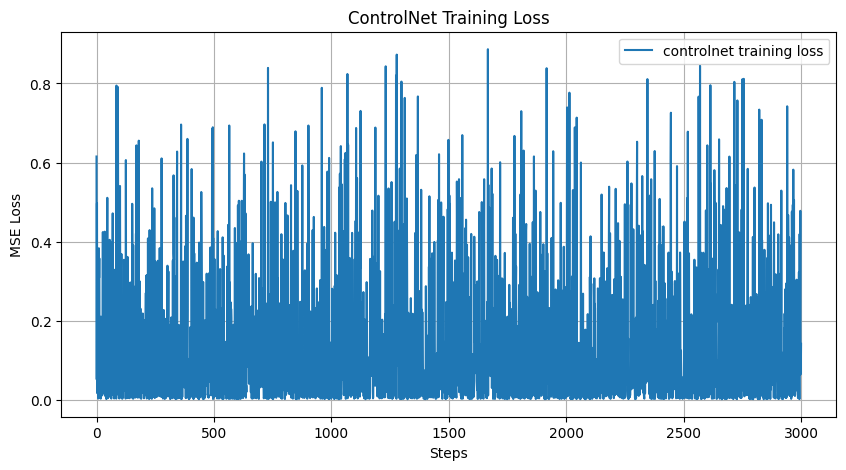

In [ ]:
# -------------------------
# 6) Plot training loss
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(loss_history, label="controlnet training loss")
plt.xlabel("Steps")
plt.ylabel("MSE Loss")
plt.title("ControlNet Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline
from peft import PeftModel
import torch
from PIL import Image
import glob
import os

# Settings
phase2_base_model = "runwayml/stable-diffusion-v1-5"  # SD v1.5 backbone
lora_adapter_path = "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase2_hyper"
controlnet_train_dir = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_dataset/train"
controlnet_out_dir = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_adapter_colonoscopy/inference"
resolution = 512

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Load base ControlNet
base_controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
).to(device)

# 2) Load pipeline with base SD + ControlNet
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    phase2_base_model,
    controlnet=base_controlnet,
    torch_dtype=torch.float16
).to(device)

# 3) Replace pipeline.unet with LoRA-wrapped UNet (PEFT style)
pipe.unet = PeftModel.from_pretrained(pipe.unet, lora_adapter_path).to(device)

pipe.enable_attention_slicing()

# 4) Prepare control mask
mask_paths = sorted(glob.glob(os.path.join(controlnet_train_dir, "*_control.png")))
if len(mask_paths) == 0:
    raise RuntimeError(f"No mask images found in {controlnet_train_dir}")
demo_mask_path = mask_paths[0]

demo_mask = Image.open(demo_mask_path).convert("L").resize((resolution, resolution))

prompt = "A realistic high-resolution colonoscopy image showing a polyp"

# Inference
with torch.autocast(device.type):
    result = pipe(
        prompt,
        image=demo_mask,   # stick with `image=` for diffusers>=0.20
        num_inference_steps=50,
        guidance_scale=7.5
    ).images[0]

# 5) Save result
os.makedirs(controlnet_out_dir, exist_ok=True)
out_path = os.path.join(controlnet_out_dir, "final_demo.png")
result.save(out_path)
print("Saved final demo to:", out_path)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


  0%|          | 0/50 [00:00<?, ?it/s]

Saved final demo to: /content/controlnet_out/final_demo.png


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/50 [00:00<?, ?it/s]

Saved generated image to /content/drive/My Drive/COMP8539/Final_Project/controlnet_adapter_colonoscopy/inference/generated_colonoscopy_000006.png


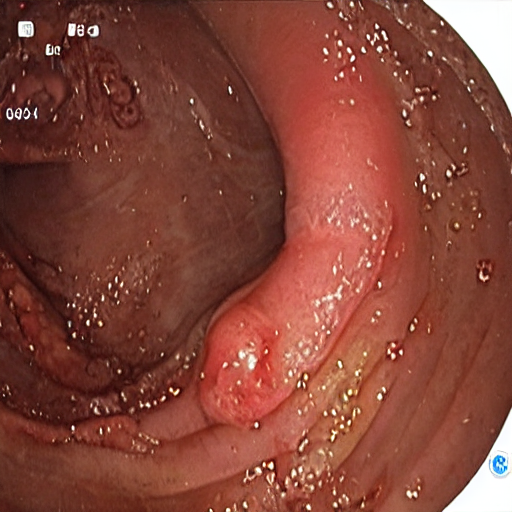

In [ ]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from peft import PeftModel
from PIL import Image

# -------------------------
# Paths and settings
# -------------------------
base_model_id = "runwayml/stable-diffusion-v1-5"
controlnet_path = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_adapter_colonoscopy"  # Your trained ControlNet folder
lora_adapter_path = "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase2_hyper"  # LoRA adapter path
device = "cuda" if torch.cuda.is_available() else "cpu"
resolution = 512

# -------------------------
# Load ControlNet + LoRA (safetensors)
# -------------------------
controlnet = ControlNetModel.from_pretrained(
    controlnet_path,
    torch_dtype=torch.float16,
    safety_checker=None,
    variant="fp16",  # this tells it to use diffusion_pytorch_model.fp16.safetensors
)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    base_model_id,
    controlnet=controlnet,
    safety_checker=None,
    torch_dtype=torch.float16
).to(device)

# Load LoRA adapter for UNet
pipe.unet = PeftModel.from_pretrained(pipe.unet, lora_adapter_path).to(device)

# Optimizations
pipe.enable_attention_slicing()
if hasattr(pipe, "enable_xformers_memory_efficient_attention"):
    try:
        pipe.enable_xformers_memory_efficient_attention()
    except:
        pass

# -------------------------
# Inference function
# -------------------------
def generate_image(prompt, control_image_path, num_inference_steps=50, guidance_scale=7.5, save_path="output.png"):
    control_image = Image.open(control_image_path).convert("RGB").resize((resolution, resolution))
    with torch.autocast("cuda"):
        result = pipe(
            prompt=prompt,
            image=control_image,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale
        ).images[0]
    result.save(save_path)
    print(f"Saved generated image to {save_path}")
    return result

# -------------------------
# Example usage
# -------------------------
prompt = "Descending colon, pedunculated polyp, 8mm, benign"
control_image_path = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_dataset/train/000006_control.png"
generate_image(prompt, control_image_path, save_path="/content/drive/My Drive/COMP8539/Final_Project/controlnet_adapter_colonoscopy/inference/generated_colonoscopy_000006.png")


## 6. Generate and Filter Inference Loop

In [ ]:
!pip install segmentation-models-pytorch --quiet

In [ ]:
# ===== SD-1.5 + ControlNet (fp16 safetensors) + LoRA (diffusers or PEFT) =====
import os, json, csv, time, random, shutil
from pathlib import Path
from typing import List, Optional, Dict, Any

import torch
import numpy as np
from PIL import Image
import torchvision.transforms as T

from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    DDIMScheduler,
)

# ----------------------- USER PATHS -----------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_MODEL_ID   = "runwayml/stable-diffusion-v1-5"  # SD-1.5
CONTROLNET_PATH = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_adapter_colonoscopy"
LORA_PATH       = "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase2_hyper"  # LoRA dir (PEFT or diffusers format)

SIZE_CLS_PATH   = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/size_cls_resnet18.pth"
SEGMENTER_PATH  = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/seg_unet_resnet34.pth"

MANIFEST_CSV    = "/content/drive/My Drive/COMP8539/Final_Project/processed/kvasir_kv_manifest.csv"
MASK_DIR        = None
OUT_DIR         = "/content/drive/My Drive/COMP8539/Final_Project/inference/synth_pool"
REPORT_CSV      = "/content/drive/My Drive/COMP8539/Final_Project/inference/synth_report.csv"

# ----------------------- INFERENCE KNOBS -----------------------
HEIGHT = 512   # SD1.5 native is 512; you can try 768 if VRAM allows
WIDTH  = 512
STEPS  = 30
GUIDANCE_SCALE = 7.5

SEED = 123
TARGET_SIZE_IDX = 1                 # 0=small,1=medium,2=large
REQUIRE_SIZE_MATCH = True
IOU_THRESHOLD = 0.45
TOP_K_PER_MASK = 2
CANDIDATES_PER_MASK = 6

PROMPT_TEMPLATE = "High-quality colonoscopy frame with a visible polyp, realistic mucosal texture, endoscopic lighting"
DISABLE_SAFETY_CHECKER = True

# ----------------------- SEEDS -----------------------
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# ----------------------- PIPELINE LOADER -----------------------
def _maybe_alias_fp16_weights(model_dir: str, fname_fp16: str, fname_std: str):
    src = os.path.join(model_dir, fname_fp16)
    dst = os.path.join(model_dir, fname_std)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)

def load_pipe_sd15():
    use_fp16 = (DEVICE == "cuda")
    torch_dtype = torch.float16 if use_fp16 else torch.float32

    # ControlNet
    controlnet = None
    if CONTROLNET_PATH and os.path.exists(CONTROLNET_PATH):
        try:
            controlnet = ControlNetModel.from_pretrained(
                CONTROLNET_PATH,
                torch_dtype=torch_dtype,
                use_safetensors=True,
                variant="fp16",  # will look for diffusion_pytorch_model.fp16.safetensors
            )
        except EnvironmentError:
            # fallback alias if diffusers expects "diffusion_pytorch_model.safetensors"
            _maybe_alias_fp16_weights(
                CONTROLNET_PATH,
                "diffusion_pytorch_model.fp16.safetensors",
                "diffusion_pytorch_model.safetensors",
            )
            controlnet = ControlNetModel.from_pretrained(
                CONTROLNET_PATH,
                torch_dtype=torch_dtype,
                use_safetensors=True,
            )

    # SD1.5 pipeline (with or without ControlNet)
    if controlnet is not None:
        pipe = StableDiffusionControlNetPipeline.from_pretrained(
            BASE_MODEL_ID,
            controlnet=controlnet,
            torch_dtype=torch_dtype,
            use_safetensors=True,
            variant="fp16" if use_fp16 else None,
            safety_checker=None if DISABLE_SAFETY_CHECKER else None,  # disable by default for medical
        )
    else:
        pipe = StableDiffusionPipeline.from_pretrained(
            BASE_MODEL_ID,
            torch_dtype=torch_dtype,
            use_safetensors=True,
            variant="fp16" if use_fp16 else None,
            safety_checker=None if DISABLE_SAFETY_CHECKER else None,
        )

    # Try loading LoRA via diffusers API first; fallback to PEFT if needed
    loaded_lora = False
    if LORA_PATH and os.path.exists(LORA_PATH):
        try:
            pipe.load_lora_weights(LORA_PATH)
            print(f"[OK] Loaded LoRA via diffusers from {LORA_PATH}")
            loaded_lora = True
        except Exception as e:
            print(f"[INFO] diffusers.load_lora_weights failed: {e}. Trying PEFT...")
            try:
                from peft import PeftModel
                pipe.unet = PeftModel.from_pretrained(pipe.unet, LORA_PATH).to(DEVICE)
                print(f"[OK] Loaded LoRA via PEFT from {LORA_PATH}")
                loaded_lora = True
            except Exception as e2:
                print(f"[WARN] Failed to load LoRA via PEFT: {e2}")

    # Scheduler + perf
    pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
    pipe = pipe.to(DEVICE)
    try:
        pipe.enable_xformers_memory_efficient_attention()
    except Exception:
        pass
    pipe.enable_attention_slicing()

    # Disable safety checker (medical)
    if DISABLE_SAFETY_CHECKER and hasattr(pipe, "safety_checker"):
        try:
            def dummy_sc(images, clip_input):
                return images, [False] * len(images)
            pipe.safety_checker = dummy_sc
            print("[INFO] Safety checker disabled.")
        except Exception:
            pass

    pipe.set_progress_bar_config(disable=True)
    print(f"[OK] SD1.5 pipeline ready. ControlNet: {hasattr(pipe,'controlnet')}  LoRA: {loaded_lora}  (res={WIDTH}x{HEIGHT})")
    return pipe

pipe = load_pipe_sd15()

# ----------------------- CONSTRAINT HEADS -----------------------
import timm, torch.nn as nn
import segmentation_models_pytorch as smp

size_net = timm.create_model('resnet18', pretrained=False, num_classes=3).to(DEVICE)
size_net.load_state_dict(torch.load(SIZE_CLS_PATH, map_location=DEVICE))
size_net.eval()
for p in size_net.parameters(): p.requires_grad = False

seg_net = smp.Unet('resnet34', encoder_weights=None, in_channels=3, classes=1).to(DEVICE)
seg_net.load_state_dict(torch.load(SEGMENTER_PATH, map_location=DEVICE))
seg_net.eval()
for p in seg_net.parameters(): p.requires_grad = False

# ----------------------- TRANSFORMS & UTILS -----------------------
to_tensor = T.ToTensor()
normalize_224 = T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
cls_tx = T.Compose([T.Resize((224,224)), to_tensor, normalize_224])

def ensure_dir(p:str):
    Path(p).mkdir(parents=True, exist_ok=True)

ensure_dir(OUT_DIR)

def load_mask_image(mask_path:str, size=(WIDTH, HEIGHT)) -> Image.Image:
    m = Image.open(mask_path).convert("L").resize(size, Image.BICUBIC)
    return m

def control_image_from_mask(mask_pil:Image.Image) -> Image.Image:
    return Image.merge("RGB", (mask_pil, mask_pil, mask_pil))

@torch.no_grad()
def seg_iou(pred_mask_logits: torch.Tensor, mask_bin_01: np.ndarray) -> float:
    pm = torch.sigmoid(pred_mask_logits)[0,0].detach().cpu().numpy() > 0.5
    mb = mask_bin_01.astype(bool)
    inter = np.logical_and(pm, mb).sum()
    union = np.logical_or(pm, mb).sum() + 1e-8
    return float(inter / union)

def crop_around_mask(img_pil: Image.Image, mask_pil: Image.Image, pad:int=10) -> Image.Image:
    arr = np.array(mask_pil)
    ys, xs = np.where(arr > 127)
    if len(xs)==0: return img_pil
    x0,x1 = xs.min(), xs.max()
    y0,y1 = ys.min(), ys.max()
    w,h = img_pil.size
    x0 = max(0, x0-pad); x1 = min(w, x1+pad)
    y0 = max(0, y0-pad); y1 = min(h, y1+pad)
    return img_pil.crop((x0,y0,x1,y1))

@torch.no_grad()
def score_constraints(img_pil: Image.Image, mask_pil: Image.Image) -> Dict[str, Any]:
    # Size classifier on crop
    crop = crop_around_mask(img_pil, mask_pil, pad=12)
    cls_in = cls_tx(crop).unsqueeze(0).to(DEVICE)
    size_logits = size_net(cls_in)
    size_pred = int(size_logits.argmax(dim=1).item())
    size_probs = torch.softmax(size_logits, dim=1)[0].detach().cpu().tolist()

    # Seg IoU
    seg_in = img_pil.resize((256,256), Image.BICUBIC)
    seg_t = to_tensor(seg_in).unsqueeze(0).to(DEVICE)
    seg_logits = seg_net(seg_t)
    mask256 = np.array(mask_pil.resize((256,256), Image.NEAREST)) > 127
    iou = seg_iou(seg_logits, mask256.astype(np.uint8))
    return {"size_pred": size_pred, "size_probs": size_probs, "iou": iou}

def pass_filters(scores: Dict[str, Any], target_size:int, require_match:bool, iou_thr:float) -> bool:
    ok_iou = scores["iou"] >= iou_thr
    ok_size = (scores["size_pred"] == target_size) if require_match else True
    return bool(ok_iou and ok_size)

def render_one(
    pipe,
    prompt: str,
    mask_pil: Image.Image,
    num_steps:int=STEPS,
    guidance:float=GUIDANCE_SCALE,
    seed: Optional[int]=None,
) -> Image.Image:
    generator = torch.Generator(device=DEVICE)
    if seed is not None:
        generator.manual_seed(seed)

    if hasattr(pipe, "controlnet"):
        ctrl_img = control_image_from_mask(mask_pil)
        with torch.autocast("cuda" if DEVICE=="cuda" else "cpu"):
            out = pipe(
                prompt=prompt,
                image=ctrl_img,
                num_inference_steps=num_steps,
                guidance_scale=guidance,
                height=HEIGHT, width=WIDTH,
                generator=generator
            )
    else:
        with torch.autocast("cuda" if DEVICE=="cuda" else "cpu"):
            out = pipe(
                prompt=prompt,
                num_inference_steps=num_steps,
                guidance_scale=guidance,
                height=HEIGHT, width=WIDTH,
                generator=generator
            )
    return out.images[0]

def read_manifest_rows() -> List[Dict[str,str]]:
    rows = []
    if MANIFEST_CSV and os.path.exists(MANIFEST_CSV):
        import pandas as pd
        df = pd.read_csv(MANIFEST_CSV)
        if "mask" not in df.columns:
            raise ValueError("Manifest must have a 'mask' column.")
        for _, r in df.iterrows():
            rows.append({
                "mask": str(r["mask"]),
                "prompt": str(r.get("prompt", PROMPT_TEMPLATE))
            })
    elif MASK_DIR and os.path.isdir(MASK_DIR):
        for p in sorted(Path(MASK_DIR).glob("*.png")):
            rows.append({"mask": str(p), "prompt": PROMPT_TEMPLATE})
    else:
        raise ValueError("Provide MANIFEST_CSV with 'mask' column or set MASK_DIR.")
    return rows

print("[READY] Loader + helpers are set.")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


[INFO] diffusers.load_lora_weights failed: Target modules {'base_model.model.up_blocks.1.attentions.1.transformer_blocks.0.attn1.to_v', 'base_model.model.up_blocks.1.attentions.0.transformer_blocks.0.attn2.to_v', 'base_model.model.down_blocks.1.attentions.1.transformer_blocks.0.attn1.to_q', 'base_model.model.mid_block.attentions.0.transformer_blocks.0.attn2.to_q', 'base_model.model.up_blocks.2.attentions.1.transformer_blocks.0.attn1.to_v', 'base_model.model.down_blocks.2.attentions.1.transformer_blocks.0.attn2.to_q', 'base_model.model.up_blocks.1.attentions.0.transformer_blocks.0.attn2.to_q', 'base_model.model.down_blocks.2.attentions.0.transformer_blocks.0.attn2.to_q', 'base_model.model.up_blocks.2.attentions.1.transformer_blocks.0.attn2.to_v', 'base_model.model.down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_v', 'base_model.model.down_blocks.1.attentions.0.transformer_blocks.0.attn1.to_q', 'base_model.model.up_blocks.2.attentions.2.transformer_blocks.0.attn1.to_v', 'base_mod

In [ ]:
# === Batch loop: generate CANDIDATES_PER_MASK images per mask, score, keep TOP_K_PER_MASK ===

from collections import defaultdict

def synthesize_for_mask(mask_path:str, prompt:str, mask_id:str, run_seed:int=SEED):
    mask_pil = load_mask_image(mask_path, size=(WIDTH, HEIGHT))
    candidates = []

    # generate candidates
    for i in range(CANDIDATES_PER_MASK):
        s = run_seed + i
        img = render_one(pipe, prompt, mask_pil, num_steps=STEPS, guidance=GUIDANCE_SCALE, seed=s)
        scores = score_constraints(img, mask_pil)
        ok = pass_filters(scores, TARGET_SIZE_IDX, REQUIRE_SIZE_MATCH, IOU_THRESHOLD)
        candidates.append({
            "img": img,
            "scores": scores,
            "ok": ok,
            "seed": s
        })

    # rank by (pass first) then by IoU desc then prob(target_size) desc
    def sort_key(c):
        sp = c["scores"]["size_probs"][TARGET_SIZE_IDX]
        return (int(c["ok"]), c["scores"]["iou"], sp)

    candidates.sort(key=sort_key, reverse=True)
    kept = candidates[:TOP_K_PER_MASK]

    # save kept images & return rows for CSV
    rows = []
    ensure_dir(OUT_DIR)
    for rank, c in enumerate(kept):
        fn = f"{Path(mask_id).stem}__rank{rank}_seed{c['seed']}_iou{c['scores']['iou']:.3f}_sz{c['scores']['size_pred']}.png"
        save_path = str(Path(OUT_DIR) / fn)
        c["img"].save(save_path)
        rows.append({
            "mask": mask_path,
            "prompt": prompt,
            "out_path": save_path,
            "rank": rank,
            "seed": c["seed"],
            "iou": round(c["scores"]["iou"], 4),
            "size_pred": c["scores"]["size_pred"],
            "size_probs": json.dumps([round(p,4) for p in c["scores"]["size_probs"]]),
            "passed": int(c["ok"])
        })
    return rows, candidates

def run_batch():
    rows = read_manifest_rows()
    print(f"[INFO] Found {len(rows)} mask entries.")
    all_csv_rows = []
    t0 = time.time()

    rows = rows[:200]

    for idx, r in enumerate(rows):
        mask_path = r["mask"]
        prompt = r["prompt"]
        mask_id = f"{idx:05d}"
        print(f"  [{idx+1}/{len(rows)}] mask={Path(mask_path).name}")

        try:
            kept_rows, _ = synthesize_for_mask(mask_path, prompt, mask_id, run_seed=SEED + idx*10000)
            all_csv_rows.extend(kept_rows)
        except Exception as e:
            print(f"[ERROR] {mask_path}: {e}")

    # write CSV report
    with open(REPORT_CSV, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=["mask","prompt","out_path","rank","seed","iou","size_pred","size_probs","passed"])
        w.writeheader()
        for item in all_csv_rows:
            w.writerow(item)

    dt = time.time() - t0
    print(f"[DONE] Saved {len(all_csv_rows)} images to {OUT_DIR} in {dt/60:.1f} min")
    print(f"[REPORT] CSV @ {REPORT_CSV}")

run_batch()


[INFO] Found 1000 mask entries.
  [1/200] mask=cju0qkwl35piu0993l0dewei2.jpg
  [2/200] mask=cju0qoxqj9q6s0835b43399p4.jpg
  [3/200] mask=cju0qx73cjw570799j4n5cjze.jpg
  [4/200] mask=cju0roawvklrq0799vmjorwfv.jpg
  [5/200] mask=cju0rx1idathl0835detmsp84.jpg
  [6/200] mask=cju0s2a9ekvms080138tjjpxr.jpg
  [7/200] mask=cju0s690hkp960855tjuaqvv0.jpg
  [8/200] mask=cju0sr5ghl0nd08789uzf1raf.jpg
  [9/200] mask=cju0sxqiclckk08551ycbwhno.jpg
  [10/200] mask=cju0t4oil7vzk099370nun5h9.jpg
  [11/200] mask=cju0tl3uz8blh0993wxvn7ly3.jpg
  [12/200] mask=cju0u2g7pmnux0801vkk47ivj.jpg
  [13/200] mask=cju0u82z3cuma0835wlxrnrjv.jpg
  [14/200] mask=cju0ue769mxii08019zqgdbxn.jpg
  [15/200] mask=cju0vtox5ain6099360pu62rp.jpg
  [16/200] mask=cju13cgqmnhwn0988yrainhcp.jpg
  [17/200] mask=cju13fwthn9mq0835gacxgy01.jpg
  [18/200] mask=cju13hp5rnbjx0835bf0jowgx.jpg
  [19/200] mask=cju14g8o4xui30878gkgbrvqj.jpg
  [20/200] mask=cju14hjh2ob2o0835ouz3r5aa.jpg
  [21/200] mask=cju14pxbaoksp0835qzorx6g6.jpg
  [22/200] 

## 7. Latent Guidance Every k-Steps

In [ ]:
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

In [ ]:
# =========================================================
# Stable Diffusion 1.5 + (optional) ControlNet + (optional) LoRA
# Latent Guidance Every k Steps (seg + size classifier in-loop)
# Generates per-mask candidates, filters, ranks, saves + CSV.
# =========================================================
import os, json, csv, time, random, shutil
from pathlib import Path
from typing import List, Dict, Any, Optional

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import torchvision.transforms as T

from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    DPMSolverMultistepScheduler,
)

In [ ]:
# ---------------------- PATHS & KNOBS ----------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Base & adapters
BASE_MODEL_ID   = "runwayml/stable-diffusion-v1-5"  # SD-1.5
CONTROLNET_PATH = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_adapter_colonoscopy"  # or None
LORA_PATH       = "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase2_hyper"   # or None

# Constraint heads
SIZE_CLS_PATH   = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/size_cls_resnet18.pth"
SEGMENTER_PATH  = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/seg_unet_resnet34.pth"
BBPS_CLS_PATH = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/bbpsq_resnet18.pth"
INSTRUMENT_CLS_PATH = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/instrument_resnet18.pth"

# Data I/O
MANIFEST_CSV    = "/content/drive/My Drive/COMP8539/Final_Project/processed/kvasir_kv_manifest.csv"  # needs 'mask' column
OUT_DIR         = "/content/drive/My Drive/COMP8539/Final_Project/inference/synth_pool_guided_4cls"
REPORT_CSV      = "/content/drive/My Drive/COMP8539/Final_Project/inference/synth_report_guided_4cls.csv"

# Generation
HEIGHT, WIDTH   = 512, 512            # 512 is safe for SD1.5
STEPS           = 28                   # total denoise steps
GUIDANCE_SCALE  = 7.5                  # CFG (text guidance)
SEED            = 123

# Candidates / filtering
TARGET_SIZE_IDX     = 1                # 0=small,1=medium,2=large
REQUIRE_SIZE_MATCH  = True
IOU_THRESHOLD       = 0.45
CANDIDATES_PER_MASK = 4
TOP_K_PER_MASK      = 2

# Which masks to process (simple slice)
MAX_MASKS = 100     # None = all; else first N masks

# Latent guidance hyperparams
GUIDE_EVERY_K   = 3     # do guidance every k steps
START_GUIDE_AT  = 3     # warmup before first guidance
LAMBDA_SEG      = 1.0   # weight for seg (soft Dice)
LAMBDA_SIZE     = 0.6   # weight for size CE
STEP_SCALE      = 0.10  # nudge magnitude per guidance step
EMA_BETA        = 0.8   # EMA momentum for grad
CLIP_UNIT_NORM  = True  # normalize latent grad to unit norm

# Instrument nd BBPS classifier Config
# Targets (per experiment)
TARGET_BBPS_IDX = 2         # if bbps_net has num_classes=4, valid = {0,1,2,3}
REQUIRE_BBPS_MATCH = True

TARGET_TOOL_IDX = 0        # 1 = instrument present (binary 0/1). Use 0 if you want 'no tool'
REQUIRE_TOOL_MATCH = True # start False (ablate later); set True for strict 4-constraint compliance

# Optional thresholds if you treat soft-probs (keep as exact class match initially)
BBPS_MIN_PROB = 0.50
TOOL_MIN_PROB = 0.50

# Hyperparams (tune)
L_BBPS = 0.4     # CE weight
L_TOOL = 0.3     # CE weight

# Misc
PROMPT_TEMPLATE = (
    "Colonoscopy frame showing a partially clean lumen with some fluid or debris bowel preparation "
    "(2/3 BBPS), no visible endoscopic instruments, realistic mucosal texture, "
    "and natural endoscopic lighting."
)
DISABLE_SAFETY_CHECKER = True

# ---------------------- SEEDS ----------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

```
bbps_score = random.choice(range(10))  # 0–9
cleanliness_desc = [
    "unprepared and obscured view with heavy debris",
    "partially clean lumen with some fluid or debris",
    "well-prepared and clean lumen with clear mucosa"
][bbps_score // 4]  # group by 0–3, 4–6, 7–9

tool_desc = random.choice([
    "no visible endoscopic instruments",
    "visible biopsy forceps near the mucosa",
    "visible snare loop partially extended",
])
prompt = (
    f"Colonoscopy frame showing a {cleanliness_desc} bowel preparation "
    f"({bbps_score}/9 BBPS), {tool_desc}, realistic mucosal texture, "
    f"and natural endoscopic lighting."
)
```

In [ ]:
# ---------------------- HELPERS ----------------------
def ensure_dir(p: str):
    Path(p).mkdir(parents=True, exist_ok=True)

def _maybe_alias_fp16_weights(model_dir: str, fname_fp16="diffusion_pytorch_model.fp16.safetensors", fname_std="diffusion_pytorch_model.safetensors"):
    src = os.path.join(model_dir, fname_fp16)
    dst = os.path.join(model_dir, fname_std)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)

def load_mask_image(mask_path: str, size=(WIDTH, HEIGHT)) -> Image.Image:
    return Image.open(mask_path).convert("L").resize(size, Image.BICUBIC)

def control_image_from_mask(mask_pil: Image.Image) -> Image.Image:
    return Image.merge("RGB", (mask_pil, mask_pil, mask_pil))

def read_manifest_rows() -> List[Dict[str, str]]:
    import pandas as pd
    rows = []
    if MANIFEST_CSV and os.path.exists(MANIFEST_CSV):
        df = pd.read_csv(MANIFEST_CSV)
        if "mask" not in df.columns:
            raise ValueError("Manifest must have a 'mask' column.")
        for _, r in df.iterrows():
            rows.append({
                "mask": str(r["mask"]),
                "prompt": str(r.get("prompt", PROMPT_TEMPLATE))
            })
    else:
        raise ValueError("Provide MANIFEST_CSV with a 'mask' column.")
    return rows

def mask_bbox(mask_np, pad=12):
    ys, xs = np.where(mask_np > 127)
    if len(xs) == 0:
        return (0, 0, mask_np.shape[1], mask_np.shape[0])
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(mask_np.shape[1], x1 + pad); y1 = min(mask_np.shape[0], y1 + pad)
    return (x0, y0, x1, y1)

def soft_dice_loss(pred_logits, target_bin, eps=1e-6):
    # pred_logits: (1,1,H,W), target_bin: (1,1,H,W) in {0,1}
    pred = torch.sigmoid(pred_logits)
    inter = (pred * target_bin).sum()
    denom = pred.sum() + target_bin.sum() + eps
    dice = 2.0 * inter / denom
    return 1.0 - dice

In [ ]:
# ---------------------- LOAD PIPELINE ----------------------
def load_pipe():
    use_fp16 = DEVICE == "cuda"
    torch_dtype = torch.float16 if use_fp16 else torch.float32

    controlnet = None
    if CONTROLNET_PATH and os.path.exists(CONTROLNET_PATH):
        try:
            controlnet = ControlNetModel.from_pretrained(
                CONTROLNET_PATH, torch_dtype=torch_dtype, use_safetensors=True, variant="fp16"
            )
        except EnvironmentError:
            _maybe_alias_fp16_weights(CONTROLNET_PATH)
            controlnet = ControlNetModel.from_pretrained(
                CONTROLNET_PATH, torch_dtype=torch_dtype, use_safetensors=True
            )

    if controlnet is not None:
        pipe = StableDiffusionControlNetPipeline.from_pretrained(
            BASE_MODEL_ID,
            controlnet=controlnet,
            torch_dtype=torch_dtype,
            use_safetensors=True,
            variant="fp16" if use_fp16 else None,
            safety_checker=None if DISABLE_SAFETY_CHECKER else None,
        )
    else:
        pipe = StableDiffusionPipeline.from_pretrained(
            BASE_MODEL_ID,
            torch_dtype=torch_dtype,
            use_safetensors=True,
            variant="fp16" if use_fp16 else None,
            safety_checker=None if DISABLE_SAFETY_CHECKER else None,
        )

    # LoRA via diffusers first, then PEFT fallback
    if LORA_PATH and os.path.exists(LORA_PATH):
        loaded = False
        try:
            pipe.load_lora_weights(LORA_PATH)
            print(f"[OK] LoRA via diffusers: {LORA_PATH}"); loaded = True
        except Exception as e:
            print(f"[INFO] load_lora_weights failed: {e}. Trying PEFT...")
            try:
                from peft import PeftModel
                pipe.unet = PeftModel.from_pretrained(pipe.unet, LORA_PATH).to(DEVICE)
                print(f"[OK] LoRA via PEFT: {LORA_PATH}"); loaded = True
            except Exception as e2:
                print(f"[WARN] PEFT load failed: {e2}")
        if not loaded:
            print("[WARN] LoRA not loaded (continuing without).")

    # Fast scheduler
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(
        pipe.scheduler.config, use_karras_sigmas=True, algorithm_type="dpmsolver++"
    )

    pipe = pipe.to(DEVICE)
    try: pipe.enable_xformers_memory_efficient_attention()
    except Exception: pass
    pipe.enable_attention_slicing()
    pipe.set_progress_bar_config(disable=True)
    return pipe

pipe = load_pipe()
print(f"[READY] SD1.5 pipeline. ControlNet: {hasattr(pipe,'controlnet')}")

In [ ]:
# ---------------------- LOAD HEADS ----------------------
import timm
import segmentation_models_pytorch as smp
from contextlib import nullcontext

_first_seen = {"done": False}

size_net = timm.create_model('resnet18', pretrained=False, num_classes=3).to(DEVICE)
size_net.load_state_dict(torch.load(SIZE_CLS_PATH, map_location=DEVICE))
size_net.eval()
for p in size_net.parameters(): p.requires_grad = False

seg_net = smp.Unet('resnet34', encoder_weights=None, in_channels=3, classes=1).to(DEVICE)
seg_net.load_state_dict(torch.load(SEGMENTER_PATH, map_location=DEVICE))
seg_net.eval()
for p in seg_net.parameters(): p.requires_grad = False

bbps_net = timm.create_model('resnet18', pretrained=False, num_classes=4).to(DEVICE)
bbps_net.load_state_dict(torch.load(BBPS_CLS_PATH, map_location=DEVICE))
bbps_net.eval()
for p in bbps_net.parameters(): p.requires_grad_(False)

instr_net = timm.create_model('resnet18', pretrained=False, num_classes=2).to(DEVICE)
instr_net.load_state_dict(torch.load(INSTRUMENT_CLS_PATH, map_location=DEVICE))
instr_net.eval()
for p in instr_net.parameters(): p.requires_grad_(False)

# after loading size_net, seg_net, bbps_net, instr_net
for m in (size_net, seg_net, bbps_net, instr_net):
    m.to(DEVICE).half().eval()

SIZE_DTYPE  = next(size_net.parameters()).dtype
SEG_DTYPE   = next(seg_net.parameters()).dtype
BBPS_DTYPE  = next(bbps_net.parameters()).dtype
INSTR_DTYPE = next(instr_net.parameters()).dtype

# ---------------------- TRANSFORMS ----------------------
to_tensor = T.ToTensor()
normalize_224 = T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
cls_tx = T.Compose([T.Resize((224,224)), to_tensor, normalize_224])

# ---------------------- GUIDED GENERATION ----------------------
def guided_generate_single(mask_pil: Image.Image, prompt: str, seed: int) -> Image.Image:
    """
    Runs pipeline with latent guidance every k steps using callback_on_step_end.
    Returns a PIL image.
    """
    device = next(pipe.unet.parameters()).device
    use_fp16 = (pipe.unet.dtype == torch.float16)

    # Precompute constant tensors for guidance
    mask_np  = np.array(mask_pil)           # (H,W) in [0..255]
    x0,y0,x1,y1 = mask_bbox(mask_np, pad=12)

    # (1,1,256,256) binary mask for seg loss
    mask256 = torch.from_numpy((mask_np > 127).astype(np.float32))[None, None].to(device).half()
    mask256 = F.interpolate(mask256, size=(256,256), mode="nearest")

    # Control image if using ControlNet
    cond_img = None
    if hasattr(pipe, "controlnet"):
        cond_img = control_image_from_mask(mask_pil).resize((WIDTH, HEIGHT))

    # EMA buffer in closure
    state = {"grad_ema": None}

    def on_step_end(pipeline, step: int, timestep: int, callback_kwargs: dict) -> dict:
        lat = callback_kwargs["latents"]

        # skip until warmup / every k
        if step < START_GUIDE_AT or (step % GUIDE_EVERY_K) != 0:
            return callback_kwargs

        # 1) make a leaf with grad
        lat = lat.detach().clone().requires_grad_(True)

        # ---- RE-ENABLE GRADS INSIDE PIPELINE LOOP ----
        with torch.enable_grad():
            # 2) keep all tensors on the same device & dtype
            vae_dtype = pipeline.vae.dtype  # typically torch.float16 on CUDA
            lat_for_vae = lat.to(vae_dtype)

            # decode with VAE and keep graph
            img = pipeline.vae.decode(lat_for_vae / pipeline.vae.config.scaling_factor).sample
            img = (img / 2 + 0.5).clamp(0, 1)  # stays differentiable

            # ----- segmentation Dice -----
            img_seg   = F.interpolate(img, size=(256,256), mode="bilinear", align_corners=False).to(SEG_DTYPE)
            seg_logits = seg_net(img_seg)  # seg_net in eval mode is fine; don't wrap in no_grad
            m256 = mask256.to(img.dtype)
            seg_loss = soft_dice_loss(seg_logits, m256)

            # ----- size CE on bbox crop -----
            x0c, y0c, x1c, y1c = int(x0), int(y0), int(x1), int(y1)
            if x1c <= x0c or y1c <= y0c:
                img_crop = F.interpolate(img, size=(224,224), mode="bilinear", align_corners=False)
            else:
                img_crop = img[:, :, y0c:y1c, x0c:x1c]
                img_crop = F.interpolate(img_crop, size=(224,224), mode="bilinear", align_corners=False)
            img_crop = (img_crop - 0.5) / 0.5
            img_crop = img_crop.to(SIZE_DTYPE)
            size_logits = size_net(img_crop)
            size_target = torch.tensor([TARGET_SIZE_IDX], device=img.device, dtype=torch.long)
            size_loss   = F.cross_entropy(size_logits, size_target)

            # ----- BBPS CE on frame -----
            bbps_in     = F.interpolate((img - 0.5) / 0.5, size=(224,224), mode="bilinear", align_corners=False).to(BBPS_DTYPE)
            bbps_logits = bbps_net(bbps_in)
            bbps_target = torch.tensor([TARGET_BBPS_IDX], device=img.device, dtype=torch.long)
            bbps_loss   = F.cross_entropy(bbps_logits, bbps_target)

            # ----- Instrument CE on frame -----
            instr_in     = F.interpolate((img - 0.5) / 0.5, size=(224,224), mode="bilinear", align_corners=False).to(INSTR_DTYPE)
            instr_logits = instr_net(instr_in)
            instr_target = torch.tensor([TARGET_TOOL_IDX], device=img.device, dtype=torch.long)
            instr_loss   = F.cross_entropy(instr_logits, instr_target)

            # total loss
            loss = (LAMBDA_SEG * seg_loss
                  + LAMBDA_SIZE * size_loss
                  + L_BBPS     * bbps_loss
                  + L_TOOL     * instr_loss)

            # one-time sanity
            if not _first_seen["done"]:
                print(f"[SANITY] dtypes – vae:{pipeline.vae.dtype}, img:{img.dtype}, "
                      f"size:{next(size_net.parameters()).dtype}, seg:{next(seg_net.parameters()).dtype}, "
                      f"bbps:{next(bbps_net.parameters()).dtype}, instr:{next(instr_net.parameters()).dtype}")
                _first_seen["done"] = True

            # 3) grad wrt latents
            grad = torch.autograd.grad(loss, lat, retain_graph=False, create_graph=False)[0]

        # 4) EMA + normalize + step (this part can stay outside enable_grad)
        if state["grad_ema"] is None:
            state["grad_ema"] = grad.detach()
        else:
            state["grad_ema"] = EMA_BETA * state["grad_ema"] + (1 - EMA_BETA) * grad.detach()

        g = torch.nan_to_num(state["grad_ema"])
        if CLIP_UNIT_NORM:
            g = g / (g.norm() + 1e-8)
            g = torch.clamp(g, -1.0, 1.0)

        with torch.no_grad():
            lat = lat - STEP_SCALE * g

        callback_kwargs["latents"] = lat.detach()
        return callback_kwargs

    # Generators for reproducibility
    gen = torch.Generator(device=device).manual_seed(int(seed))

    # Run pipeline with callback
    with torch.autocast("cuda" if DEVICE=="cuda" else "cpu"):
        pipe_kwargs = dict(
            prompt=prompt,
            num_inference_steps=STEPS,
            guidance_scale=GUIDANCE_SCALE,
            height=HEIGHT, width=WIDTH,
            generator=gen,
            callback_on_step_end=on_step_end,
            callback_on_step_end_tensor_inputs=["latents"],
        )
        if hasattr(pipe, "controlnet"):
            pipe_kwargs["image"] = control_image_from_mask(mask_pil).resize((WIDTH, HEIGHT))

        out = pipe(**pipe_kwargs)
    return out.images[0]

# ---------------------- SCORING & FILTERING ----------------------
def seg_iou(pred_mask_logits: torch.Tensor, mask_bin_01: np.ndarray) -> float:
    pm = torch.sigmoid(pred_mask_logits)[0,0].detach().cpu().numpy() > 0.5
    mb = mask_bin_01.astype(bool)
    inter = np.logical_and(pm, mb).sum()
    union = np.logical_or(pm, mb).sum() + 1e-8
    return float(inter / union)

@torch.no_grad()
def score_constraints(img_pil: Image.Image, mask_pil: Image.Image) -> Dict[str, Any]:
    arr = np.array(mask_pil)
    x0,y0,x1,y1 = mask_bbox(arr, pad=12)

    # ----- Size on crop -----
    crop = img_pil.crop((x0,y0,x1,y1)) if (x1>x0 and y1>y0) else img_pil
    cls_in = cls_tx(crop).unsqueeze(0).to(DEVICE).to(SIZE_DTYPE)   # <<< add .to(SIZE_DTYPE)
    size_logits = size_net(cls_in)
    size_pred = int(size_logits.argmax(dim=1).item())
    size_probs = torch.softmax(size_logits, dim=1)[0].detach().cpu().tolist()

    # ----- Seg IoU -----
    seg_in = img_pil.resize((256,256), Image.BICUBIC)
    seg_t  = T.ToTensor()(seg_in).unsqueeze(0).to(DEVICE).to(SEG_DTYPE)  # <<< add .to(SEG_DTYPE)
    seg_logits = seg_net(seg_t)
    mask256 = (arr > 127).astype(np.uint8)
    mask256 = Image.fromarray(mask256*255).resize((256,256), Image.NEAREST)
    iou = seg_iou(seg_logits, np.array(mask256) > 127)

    # ----- BBPS (frame-level) -----
    bbps_in = cls_tx(img_pil).unsqueeze(0).to(DEVICE).to(BBPS_DTYPE)   # <<< add .to(BBPS_DTYPE)
    bbps_logits = bbps_net(bbps_in)
    bbps_pred = int(bbps_logits.argmax(1).item())
    bbps_probs = torch.softmax(bbps_logits, 1)[0].cpu().tolist()

    # ----- Instrument presence (frame-level) -----
    instr_in = cls_tx(img_pil).unsqueeze(0).to(DEVICE).to(INSTR_DTYPE)  # <<< add .to(INSTR_DTYPE)
    instr_logits = instr_net(instr_in)
    instr_pred = int(instr_logits.argmax(1).item())
    instr_probs = torch.softmax(instr_logits, 1)[0].cpu().tolist()

    return {
        "size_pred": size_pred, "size_probs": size_probs,
        "iou": iou,
        "bbps_pred": bbps_pred, "bbps_probs": bbps_probs,
        "instr_pred": instr_pred, "instr_probs": instr_probs,
    }

def pass_filters(scores: Dict[str, Any]) -> bool:
    ok_iou = scores["iou"] >= IOU_THRESHOLD
    ok_size = (scores["size_pred"] == TARGET_SIZE_IDX) if REQUIRE_SIZE_MATCH else True
    ok_bbps  = (scores["bbps_pred"] == TARGET_BBPS_IDX) if REQUIRE_BBPS_MATCH else True
    ok_tool  = (scores["instr_pred"] == TARGET_TOOL_IDX) if REQUIRE_TOOL_MATCH else True
    return bool(ok_iou and ok_size and ok_bbps and ok_tool)

# ---------------------- PER-MASK SYNTHESIS ----------------------
def synthesize_for_mask(mask_path: str, prompt: str, mask_id: str, run_seed: int):
    mask_pil = load_mask_image(mask_path, size=(WIDTH, HEIGHT))

    candidates = []
    for i in range(CANDIDATES_PER_MASK):
        s = run_seed + i
        img = guided_generate_single(mask_pil=mask_pil, prompt=prompt, seed=s)
        scores = score_constraints(img, mask_pil)
        ok = pass_filters(scores)
        candidates.append({"img": img, "scores": scores, "ok": ok, "seed": s})

    # rank: passed first → IoU → prob(target size)
    def sort_key(c):
        sp = c["scores"]["size_probs"][TARGET_SIZE_IDX]
        return (int(c["ok"]), c["scores"]["iou"], sp)

    candidates.sort(key=sort_key, reverse=True)
    kept = candidates[:TOP_K_PER_MASK]

    ensure_dir(OUT_DIR)
    rows = []
    stem = Path(mask_path).stem
    for rank, c in enumerate(kept):
        fn = f"{stem}__rank{rank}_seed{c['seed']}_iou{c['scores']['iou']:.3f}_sz{c['scores']['size_pred']}.png"
        save_path = str(Path(OUT_DIR) / fn)
        c["img"].save(save_path)
        rows.append({
            "mask": mask_path,
            "prompt": prompt,
            "out_path": save_path,
            "rank": rank,
            "seed": c["seed"],
            "iou": round(c["scores"]["iou"], 4),
            "size_pred": c["scores"]["size_pred"],
            "size_probs": json.dumps([round(p,4) for p in c["scores"]["size_probs"]]),
            "bbps_pred":  c["scores"]["bbps_pred"],
            "bbps_probs": json.dumps([round(p,4) for p in c["scores"]["bbps_probs"]]),
            "instr_pred": c["scores"]["instr_pred"],
            "instr_probs": json.dumps([round(p,4) for p in c["scores"]["instr_probs"]]),

            "passed": int(c["ok"]),
            "joint_compliance": int(pass_filters(c["scores"]))
        })
    return rows, kept

In [ ]:
# after constructing heads, add sanity checks:
def _num_classes_from_head(head):
    for m in head.modules():
        if hasattr(m, "out_features"):
            return int(m.out_features)
    # fallback via state_dict for timm resnet18 heads
    for n, p in head.named_parameters():
        if n.endswith("fc.weight"):
            return p.shape[0]
    return None

assert 0 <= TARGET_SIZE_IDX  < _num_classes_from_head(size_net), "size target out of range"
assert 0 <= TARGET_BBPS_IDX  < _num_classes_from_head(bbps_net), "bbps target out of range"
assert 0 <= TARGET_TOOL_IDX  < _num_classes_from_head(instr_net), "instrument target out of range"

In [ ]:
import os
import csv
from pathlib import Path

# ---------------------- BATCH LOOP ----------------------
def run_batch():
    rows = read_manifest_rows()
    if MAX_MASKS is not None:
        rows = rows[:MAX_MASKS]

    print(f"[INFO] Found {len(rows)} masks in manifest.")

    # Ensure report directory exists
    ensure_dir(Path(REPORT_CSV).parent)

    # If resuming, load already processed mask paths
    processed_masks = set()
    csv_exists = os.path.exists(REPORT_CSV)

    if csv_exists:
        with open(REPORT_CSV, "r", newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                processed_masks.add(row["mask"])

        print(f"[RESUME] Found {len(processed_masks)} processed masks. Skipping those.")

    # Filter out already processed masks
    rows = [r for r in rows if r["mask"] not in processed_masks]
    print(f"[INFO] Processing {len(rows)} new masks.")

    mode = "a" if csv_exists else "w"
    all_rows = []

    with open(REPORT_CSV, mode, newline="") as f:
        w = csv.DictWriter(f, fieldnames=[
            "mask","prompt","out_path","rank","seed","iou",
            "size_pred","size_probs",
            "bbps_pred","bbps_probs",
            "instr_pred","instr_probs",
            "passed","joint_compliance"
        ])
        if not csv_exists:
            w.writeheader()

        t0 = time.time()
        for idx, r in enumerate(rows):
            mask_path = r["mask"]
            prompt = r["prompt"]
            mask_id = f"{idx:05d}"
            print(f"  [{idx+1}/{len(rows)}] {Path(mask_path).name}")

            try:
                kept_rows, _ = synthesize_for_mask(
                    mask_path, prompt, mask_id, run_seed=SEED + idx * 10000
                )

                for row in kept_rows:
                    w.writerow(row)
                    all_rows.append(row)

            except Exception as e:
                print(f"[ERROR] {mask_path}: {e}")

    dt = time.time() - t0
    print(f"[DONE] Kept {len(all_rows)} images → {OUT_DIR}")
    print(f"[REPORT] CSV @ {REPORT_CSV}")
    print(f"[TIME] {dt / 60:.1f} min")

# ---------------------- GO ----------------------
ensure_dir(OUT_DIR)
run_batch()

## Ablation Studies

In [ ]:
# Enable fast math (optional)
import torch
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

In [ ]:
# ============================================================
# research_runner.py  —  End-to-end experiments for your paper
# ============================================================
# What this does:
# 1) Generation with latent guidance (seg + size + BBPS + instrument)
# 2) Medical verification suite (automatic checks + scores)
# 3) Model-independence: swap SD1.5 / SDXL backends in one line
# 4) Ablations grid (toggle constraints / guidance / hyperparams)
# 5) Downstream utility: train SMP-based polyp segmenter
#    on (Real) vs (Real+Synthetic) and eval on ClinicDB (or your held-out)
#
# Notes:
# - Heads (size/bbps/instrument/seg) are assumed trained & provided by you.
# - BBPS head is 4-class (0..3) in this version.
# - Instrument head is 2-class (0=no tool, 1=tool).
# - Seg head is 1-channel U-Net that expects inputs in [0,1].
# ============================================================

import os, json, csv, time, random, math, shutil, warnings, re, zipfile
from pathlib import Path
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
warnings.filterwarnings("ignore")

In [ ]:
# ===========================
# External testset: ClinicDB
# ===========================
def _ensure_dir(p: str):
    Path(p).mkdir(parents=True, exist_ok=True)

def _save_mask_binary(src_mask_path: Path, dst_mask_path: Path):
    m = Image.open(src_mask_path)
    if m.mode != "L":
        m = m.convert("L")
    arr = np.array(m)
    binm = (arr > 0).astype(np.uint8) * 255
    Image.fromarray(binm).save(dst_mask_path)

def _copy_pair(img_path: Path, mask_path: Path, out_img_dir: Path, out_msk_dir: Path):
    out_img = out_img_dir / img_path.name
    shutil.copy2(str(img_path), str(out_img))
    out_msk = out_msk_dir / f"{img_path.stem}.png"
    _save_mask_binary(mask_path, out_msk)
    return str(out_img), str(out_msk)

def _find_clinicdb_root(folder: Path) -> Path:
    candidates = [folder] + [p for p in folder.rglob("*") if p.is_dir()]
    for f in candidates:
        if (f / "Original").is_dir() and (f / "Ground Truth").is_dir():
            return f
    raise FileNotFoundError("Could not find 'Original' and 'Ground Truth' folders inside extracted ClinicDB.")

def unzip_if_needed(zip_path: str, extract_to: str) -> str:
    zip_path = Path(zip_path)
    extract_to = Path(extract_to)
    _ensure_dir(extract_to)
    if any(extract_to.iterdir()):
        print(f"[ClinicDB] Using existing extracted folder: {extract_to}")
        return str(extract_to)
    assert zip_path.is_file(), f"Zip not found: {zip_path}"
    print(f"[ClinicDB] Extracting {zip_path.name} → {extract_to} ...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_to)
    print("[ClinicDB] Unzip done.")
    return str(extract_to)

def prep_cvc_clinicdb_from_zip(zip_path: str, extract_dir: str, out_prepped_root: str, pairs_csv: str) -> tuple[str, str]:
    extracted = Path(unzip_if_needed(zip_path, extract_dir))
    root = _find_clinicdb_root(extracted)
    img_src = root / "Original"
    msk_src = root / "Ground Truth"

    out_root = Path(out_prepped_root)
    out_img = out_root / "images"
    out_msk = out_root / "masks"
    _ensure_dir(out_img); _ensure_dir(out_msk)

    mask_map = {}
    for m in sorted(msk_src.glob("*")):
        if not m.is_file(): continue
        stem = re.sub(r"(_GT|_gt|-GT|-gt|_manual|-manual|_mask|-mask)$", "", m.stem)
        mask_map.setdefault(stem, m)

    rows, kept = [], 0
    for i in sorted(img_src.glob("*")):
        if not i.is_file(): continue
        stem = i.stem
        cand = mask_map.get(stem)
        if cand is None:
            mm = sorted(msk_src.glob(f"{stem}*"))
            cand = mm[0] if mm else None
        if cand is None:
            continue
        ip, mp = _copy_pair(i, cand, out_img, out_msk)
        rows.append({"image": ip, "mask": mp, "stem": stem})
        kept += 1

    assert kept > 0, "No (image,mask) pairs found in ClinicDB."
    pd.DataFrame(rows).to_csv(pairs_csv, index=False)
    print(f"[ClinicDB] Prepared {kept} pairs → {out_root}")
    print(f"[ClinicDB] Pairs CSV: {pairs_csv}")
    return str(out_img), str(out_msk)

def clinicdb_card(img_dir: str, msk_dir: str):
    imgs = sorted(Path(img_dir).glob("*"))
    msks = sorted(Path(msk_dir).glob("*.png"))
    assert len(imgs) == len(msks) and len(imgs) > 0, "Unpaired or empty eval set."
    Hs, Ws, cov = [], [], []
    for i, m in zip(imgs, msks):
        im = Image.open(i).convert("RGB")
        mk = Image.open(m).convert("L")
        Hs.append(im.height); Ws.append(im.width)
        a = (np.array(mk) > 0)
        cov.append(a.mean())
    print("[ClinicDB Card]")
    print("  Samples:", len(imgs))
    print("  HxW (median):", int(np.median(Hs)), "x", int(np.median(Ws)))
    print("  HxW (min/max):", min(Hs), "x", min(Ws), " / ", max(Hs), "x", max(Ws))
    print("  Mean mask coverage:", round(float(np.mean(cov))*100, 2), "%")

In [ ]:
# ==================================
# 1) GLOBAL CONFIG (EDIT THESE)
# ==================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 123

# --- Paths to your trained heads ---
SIZE_CLS_PATH       = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/size_cls_resnet18.pth"
SEGMENTER_PATH      = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/seg_unet_resnet34.pth"
BBPS_CLS_PATH       = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/bbpsq_resnet18.pth"  # 4 classes
INSTRUMENT_CLS_PATH = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/instrument_resnet18.pth"  # 2 classes

# --- Generator backends (choose one per run) ---
GEN_BACKEND = "sd15"         # "sd15" or "sdxl"
BASE_MODEL_ID   = "runwayml/stable-diffusion-v1-5"
CONTROLNET_PATH = "/content/drive/My Drive/COMP8539/Final_Project/controlnet_adapter_colonoscopy"  # or None
LORA_PATH       = "/content/drive/My Drive/COMP8539/Final_Project/lora_colonoscopy_phase2_hyper"   # or None

SDXL_BASE_MODEL_ID   = "stabilityai/stable-diffusion-xl-base-1.0"
SDXL_CONTROLNET_PATH = None
SDXL_LORA_PATH       = None

DISABLE_SAFETY_CHECKER = True

# --- Data in/out ---
MANIFEST_CSV   = "/content/drive/My Drive/COMP8539/Final_Project/processed/kvasir_kv_manifest.csv"  # must have 'mask' column
OUT_ROOT       = "/content/drive/My Drive/COMP8539/Final_Project/experiments"
RUN_NAME       = "ablations_v2"
GEN_DIR        = f"{OUT_ROOT}/{RUN_NAME}/gen"
REPORT_CSV     = f"{OUT_ROOT}/{RUN_NAME}/gen_report.csv"
ABLATION_SUM   = f"{OUT_ROOT}/{RUN_NAME}/ablation_summary.csv"

# --- Generation params ---
HEIGHT, WIDTH  = 512, 512
STEPS          = 28
GUIDANCE_SCALE = 7.5
CANDIDATES_PER_MASK = 4
TOP_K_PER_MASK      = 2
MAX_MASKS           = 2   # set to 1 for quick debug
PROMPT_TEMPLATE     = "Colonoscopy frame showing a partially clean lumen with some fluid or debris bowel preparation (2/3 BBPS), no visible endoscopic instruments, realistic mucosal texture, and natural endoscopic lighting."
RANDOMIZE_PROMPT    = False # adds BBPS/tool descriptors to prompt text for diversity

# --- Constraint targets / thresholds ---
TARGET_SIZE_IDX     = 1           # 0=small,1=medium,2=large
IOU_THRESHOLD       = 0.45
REQUIRE_SIZE_MATCH  = True

# BBPS target (4-class 0..3)
TARGET_BBPS_VALUE   = 2
REQUIRE_BBPS_MATCH  = True

# Instrument target (0=no tool, 1=tool)
TARGET_TOOL_IDX     = 0
REQUIRE_TOOL_MATCH  = True

# --- Latent guidance hyperparams ---
GUIDE_EVERY_K   = 3
START_GUIDE_AT  = 3
LAMBDA_SEG      = 1.0
LAMBDA_SIZE     = 0.6
L_BBPS          = 0.4
L_TOOL          = 0.3
STEP_SCALE      = 0.10
EMA_BETA        = 0.8
CLIP_UNIT_NORM  = True

# --- Ablations to run (rows x models) ---
ABLATIONS = [
    ("no_guidance",        False, False, False, False, False, 0.00,  999),
    ("seg_only",           True,  True,  False, False, False, 0.08,  3  ),
    ("seg+size",           True,  True,  True,  False, False, 0.10,  3  ),
    ("seg+size+bbps",      True,  True,  True,  True,  False, 0.10,  3  ),
    ("seg+size+bbps+tool", True,  True,  True,  True,  True,  0.10,  3  ),
    ("seg+size+bbps+tool_slow", True,True,True,True,True,    0.06,  4  ),
]

# --- Downstream segmentation experiment ---
REAL_TRAIN_IMG_DIR  = "/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/images"
REAL_TRAIN_MSK_DIR  = "/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/masks"

CLINICDB_ZIP   = "/content/drive/My Drive/COMP8539/Final_Project/CVC-ClinicDB.zip"
CLINICDB_EXTR  = "/content/drive/My Drive/COMP8539/Final_Project/CVC-ClinicDB"
CLINICDB_PREP  = "/content/drive/My Drive/COMP8539/Final_Project/experiments/clinicdb_prepped"
CLINICDB_PAIRS = "/content/drive/My Drive/COMP8539/Final_Project/experiments/clinicdb_pairs.csv"

# If already prepared:
EVAL_IMG_DIR, EVAL_MSK_DIR = (
    "/content/drive/My Drive/COMP8539/Final_Project/experiments/clinicdb_prepped/images",
    "/content/drive/My Drive/COMP8539/Final_Project/experiments/clinicdb_prepped/masks"
)
# Or run once:
# EVAL_IMG_DIR, EVAL_MSK_DIR = prep_cvc_clinicdb_from_zip(CLINICDB_ZIP, CLINICDB_EXTR, CLINICDB_PREP, CLINICDB_PAIRS)
# clinicdb_card(EVAL_IMG_DIR, EVAL_MSK_DIR)

EVAL_RESIZE_TO = None
DOWNSTREAM_OUT = f"{OUT_ROOT}/{RUN_NAME}/downstream"
SYN_MIX_RATIO  = 1.0  # synthetic:real ratio in mixed set

In [ ]:
# =========================================================
# 2) Utils
# =========================================================
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def ensure_dir(p: str):
    Path(p).mkdir(parents=True, exist_ok=True)

seed_everything(SEED)
ensure_dir(OUT_ROOT); ensure_dir(GEN_DIR); ensure_dir(Path(REPORT_CSV).parent); ensure_dir(DOWNSTREAM_OUT)

In [ ]:
# =========================================================
# 3) Load Heads
# =========================================================
import timm
import segmentation_models_pytorch as smp

def load_heads() -> Tuple[nn.Module, nn.Module, nn.Module, nn.Module, int]:
    # size (3 classes)
    size_net = timm.create_model("resnet18", pretrained=False, num_classes=3)
    size_net.load_state_dict(torch.load(SIZE_CLS_PATH, map_location="cpu"))
    size_net.eval().to(DEVICE).float()

    # segmentation (1 class) — expects inputs in [0,1]
    seg_net = smp.Unet("resnet34", encoder_weights=None, in_channels=3, classes=1)
    seg_net.load_state_dict(torch.load(SEGMENTER_PATH, map_location="cpu"))
    seg_net.eval().to(DEVICE).float()

    # bbps (4 classes)
    bbps_net = timm.create_model("resnet18", pretrained=False, num_classes=4)
    state = torch.load(BBPS_CLS_PATH, map_location="cpu")
    bbps_net.load_state_dict(state, strict=True)
    bbps_net.eval().to(DEVICE).float()
    bbps_classes = 4

    # instrument (2 classes)
    instr_net = timm.create_model("resnet18", pretrained=False, num_classes=2)
    instr_net.load_state_dict(torch.load(INSTRUMENT_CLS_PATH, map_location="cpu"))
    instr_net.eval().to(DEVICE).float()

    # keep guidance heads in half precision for stable latent grads
    for m in (size_net, seg_net, bbps_net, instr_net):
        m.to(DEVICE).eval()

    return size_net, seg_net, bbps_net, instr_net, bbps_classes

size_net, seg_net, bbps_net, instr_net, BBPS_CLASSES = load_heads()

def map_bbps_target(val: int) -> int:
    # BBPS is 4 classes: 0,1,2,3
    return int(np.clip(val, 0, 3))

TARGET_BBPS_IDX = map_bbps_target(TARGET_BBPS_VALUE)

In [ ]:
# =========================================================
# 4) Generator backends (swappable)
# =========================================================
from diffusers import (
    StableDiffusionPipeline, StableDiffusionControlNetPipeline, ControlNetModel,
    StableDiffusionXLPipeline, StableDiffusionXLControlNetPipeline,
    DPMSolverMultistepScheduler
)

def _maybe_alias_fp16_weights(model_dir: str,
                              fname_fp16="diffusion_pytorch_model.fp16.safetensors",
                              fname_std="diffusion_pytorch_model.safetensors"):
    src = os.path.join(model_dir, fname_fp16); dst = os.path.join(model_dir, fname_std)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)

def load_sd15_pipe(base_id, controlnet_path=None, lora_path=None):
    use_fp16 = (DEVICE == "cuda")
    dtype = torch.float16 if use_fp16 else torch.float32

    controlnet = None
    if controlnet_path and os.path.exists(controlnet_path):
        try:
            controlnet = ControlNetModel.from_pretrained(controlnet_path, torch_dtype=dtype, use_safetensors=True, variant="fp16")
        except EnvironmentError:
            _maybe_alias_fp16_weights(controlnet_path)
            controlnet = ControlNetModel.from_pretrained(controlnet_path, torch_dtype=dtype, use_safetensors=True)

    pipe_cls = StableDiffusionControlNetPipeline if controlnet is not None else StableDiffusionPipeline
    pipe = pipe_cls.from_pretrained(
        base_id, controlnet=controlnet, torch_dtype=dtype, use_safetensors=True,
        safety_checker=None if DISABLE_SAFETY_CHECKER else None, variant="fp16" if use_fp16 else None
    )
    if lora_path and os.path.exists(lora_path):
        try: pipe.load_lora_weights(lora_path)
        except Exception: pass

    pipe.scheduler = DPMSolverMultistepScheduler.from_config(
        pipe.scheduler.config, use_karras_sigmas=True, algorithm_type="dpmsolver++"
    )
    pipe = pipe.to(DEVICE)
    try: pipe.enable_xformers_memory_efficient_attention()
    except Exception: pass
    pipe.enable_attention_slicing()
    pipe.set_progress_bar_config(disable=True)
    return pipe

def load_sdxl_pipe(base_id, controlnet_path=None, lora_path=None):
    use_fp16 = (DEVICE == "cuda")
    dtype = torch.float16 if use_fp16 else torch.float32

    controlnet = None
    if controlnet_path and os.path.exists(controlnet_path):
        try:
            controlnet = ControlNetModel.from_pretrained(controlnet_path, torch_dtype=dtype, use_safetensors=True, variant="fp16")
        except EnvironmentError:
            _maybe_alias_fp16_weights(controlnet_path)
            controlnet = ControlNetModel.from_pretrained(controlnet_path, torch_dtype=dtype, use_safetensors=True)

    pipe_cls = StableDiffusionXLControlNetPipeline if controlnet is not None else StableDiffusionXLPipeline
    pipe = pipe_cls.from_pretrained(
        base_id, controlnet=controlnet, torch_dtype=dtype, use_safetensors=True,
        safety_checker=None if DISABLE_SAFETY_CHECKER else None, variant="fp16" if use_fp16 else None
    )
    if lora_path and os.path.exists(lora_path):
        try: pipe.load_lora_weights(lora_path)
        except Exception: pass

    pipe.scheduler = DPMSolverMultistepScheduler.from_config(
        pipe.scheduler.config, use_karras_sigmas=True, algorithm_type="dpmsolver++"
    )
    pipe = pipe.to(DEVICE)
    try: pipe.enable_xformers_memory_efficient_attention()
    except Exception: pass
    pipe.enable_attention_slicing()
    pipe.set_progress_bar_config(disable=True)
    return pipe

if GEN_BACKEND == "sdxl":
    pipe = load_sdxl_pipe(SDXL_BASE_MODEL_ID, SDXL_CONTROLNET_PATH, SDXL_LORA_PATH)
else:
    pipe = load_sd15_pipe(BASE_MODEL_ID, CONTROLNET_PATH, LORA_PATH)

print(f"[READY] Generator backend: {GEN_BACKEND}. dtype={pipe.unet.dtype}")
cn_ok = hasattr(pipe, "controlnet") and (pipe.controlnet is not None)
print(f"[READY] ControlNet attached? {cn_ok}")
if CONTROLNET_PATH and not cn_ok:
    raise RuntimeError("ControlNet weights not loaded. Check CONTROLNET_PATH and fp16 aliasing.")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

diffusion_pytorch_model.fp16.safetensors:   0%|          | 0.00/1.72G [00:00<?, ?B/s]

diffusion_pytorch_model.fp16.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


[READY] Generator backend: sd15. dtype=torch.float16
[READY] ControlNet attached? True


In [ ]:
# =========================================================
# 5) Transforms & core helpers
# =========================================================
to_tensor = T.ToTensor()
normalize_224 = T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])  # [-1,1] after ToTensor
cls_tx = T.Compose([T.Resize((224,224)), to_tensor, normalize_224])

def load_mask_image(mask_path: str, size=(WIDTH, HEIGHT)) -> Image.Image:
    return Image.open(mask_path).convert("L").resize(size, Image.BICUBIC)

def control_image_from_mask(mask_pil: Image.Image) -> Image.Image:
    return Image.merge("RGB", (mask_pil, mask_pil, mask_pil))

def read_manifest_rows(limit=None) -> List[Dict[str, str]]:
    df = pd.read_csv(MANIFEST_CSV)
    assert "mask" in df.columns
    rows=[]
    for _,r in df.iterrows():
        rows.append({"mask": str(r["mask"]), "prompt": str(r.get("prompt", PROMPT_TEMPLATE))})
    if limit is not None: rows = rows[:limit]
    return rows

def mask_bbox(mask_np, pad=12):
    ys, xs = np.where(mask_np > 127)
    if len(xs) == 0:
        return (0, 0, mask_np.shape[1], mask_np.shape[0])
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(mask_np.shape[1], x1 + pad); y1 = min(mask_np.shape[0], y1 + pad)
    return (x0, y0, x1, y1)

def soft_dice_loss(logits, target_bin, eps=1e-6):
    pred = torch.sigmoid(logits)
    inter = (pred * target_bin).sum()
    denom = pred.sum() + target_bin.sum() + eps
    return 1.0 - 2.0 * inter / denom

def map_prompt_with_constraints(base_prompt: str) -> str:
    if not RANDOMIZE_PROMPT: return base_prompt
    bbps_desc = {
        0: "unprepared/dirty view with heavy debris",
        1: "partially clean lumen with visible residue",
        2: "mostly clean mucosa with minimal residue",
        3: "excellent preparation with a clear view",
    }
    bbps_str = bbps_desc.get(map_bbps_target(TARGET_BBPS_VALUE), "clean mucosa")
    tool_str = "no visible endoscopic instruments" if TARGET_TOOL_IDX==0 else "a visible endoscopic instrument in frame"
    return f"{base_prompt} Bowel preparation: {bbps_str}. Instrument: {tool_str}."

In [ ]:
# =========================================================
# 6) Latent-guided generation (callback)
# =========================================================
from contextlib import nullcontext
from torch.cuda.amp import autocast
_first_seen = {"done": False}

def guided_generate_single(mask_pil: Image.Image,
                           prompt: str,
                           seed: int,
                           use_guidance: bool,
                           use_seg: bool, use_size: bool, use_bbps: bool, use_tool: bool,
                           step_scale: float, guide_k: int) -> Image.Image:
    device = next(pipe.unet.parameters()).device

    # precompute mask tensors
    mask_np  = np.array(mask_pil)
    x0,y0,x1,y1 = mask_bbox(mask_np, pad=12)
    mask256 = torch.from_numpy((mask_np > 127).astype(np.float32))[None,None].to(device)
    mask256 = F.interpolate(mask256, size=(256,256), mode="nearest")

    state = {"grad_ema": None}

    def on_step_end(pipeline, step: int, timestep: int, callback_kwargs: dict) -> dict:
        if (not use_guidance) or step < START_GUIDE_AT or (step % guide_k) != 0:
            return callback_kwargs

        lat = callback_kwargs["latents"].detach().clone().requires_grad_(True)

        # Re-enable autograd inside Diffusers' no_grad context
        with torch.enable_grad(), autocast(enabled=False):
            vae_dtype = pipeline.vae.dtype
            img = pipeline.vae.decode(lat.to(pipeline.vae.dtype) / pipeline.vae.config.scaling_factor).sample
            img = (img / 2 + 0.5).clamp(0, 1).float()
            loss = torch.zeros((), device=lat.device, dtype=torch.float32)

            # SEG branch: expects [0,1] fp32, no mean/std
            if use_seg:
                img_seg = F.interpolate(img, (256,256), mode="bilinear", align_corners=False)
                seg_logits = seg_net(img_seg)     # seg_net is in fp32
                target = mask256.to(seg_logits.dtype)
                pred   = torch.sigmoid(seg_logits)
                inter  = (pred * target).sum()
                denom  = pred.sum() + target.sum() + 1e-6
                seg_loss = 1.0 - 2.0 * inter / denom
                loss = loss + LAMBDA_SEG * seg_loss

            # SIZE / BBPS / TOOL: use [-1,1] normalization that heads were trained with
            if use_size:
                if x1<=x0 or y1<=y0:
                    img_crop = F.interpolate(img, (224,224), mode="bilinear", align_corners=False)
                else:
                    img_crop = F.interpolate(img[:, :, y0:y1, x0:x1], (224,224), mode="bilinear", align_corners=False)
                img_crop = ((img_crop - 0.5) / 0.5)  # [-1,1]
                size_logits = size_net(img_crop)
                size_loss = F.cross_entropy(size_logits, torch.tensor([TARGET_SIZE_IDX], device=lat.device))
                loss = loss + LAMBDA_SIZE * size_loss

            if use_bbps:
                bbps_in = F.interpolate(img, (224,224), mode="bilinear", align_corners=False)
                bbps_in = ((bbps_in - 0.5) / 0.5)
                bbps_logits = bbps_net(bbps_in)
                bbps_loss = F.cross_entropy(bbps_logits, torch.tensor([TARGET_BBPS_IDX], device=lat.device))
                loss = loss + L_BBPS * bbps_loss

            if use_tool:
                instr_in = F.interpolate(img, (224,224), mode="bilinear", align_corners=False)
                instr_in = ((instr_in - 0.5) / 0.5)
                instr_logits = instr_net(instr_in)
                instr_loss = F.cross_entropy(instr_logits, torch.tensor([TARGET_TOOL_IDX], device=lat.device))
                loss = loss + L_TOOL * instr_loss

            if not _first_seen["done"]:
                print(f"[SANITY] step={step} loss.grad_fn={type(loss.grad_fn).__name__ if loss.grad_fn else None}")
                _first_seen["done"] = True

            grad = torch.autograd.grad(loss, lat, retain_graph=False, create_graph=False)[0]

        # EMA + latent step
        if state["grad_ema"] is None:
            state["grad_ema"] = grad.detach()
        else:
            state["grad_ema"] = EMA_BETA * state["grad_ema"] + (1-EMA_BETA) * grad.detach()

        g = torch.nan_to_num(state["grad_ema"])
        if CLIP_UNIT_NORM:
            g = g / (g.norm() + 1e-8)
            g = torch.clamp(g, -1.0, 1.0)

        with torch.no_grad():
            lat = lat - step_scale * g

        callback_kwargs["latents"] = lat.detach()
        return callback_kwargs

    gen = torch.Generator(device=device).manual_seed(int(seed))
    with torch.autocast("cuda" if DEVICE=="cuda" else "cpu"):
        kwargs = dict(
            prompt=prompt,
            num_inference_steps=STEPS,
            guidance_scale=GUIDANCE_SCALE,
            height=HEIGHT, width=WIDTH,
            generator=gen,
            callback_on_step_end=on_step_end,
            callback_on_step_end_tensor_inputs=["latents"],
        )
        if hasattr(pipe, "controlnet"):
            kwargs["image"] = control_image_from_mask(mask_pil).resize((WIDTH, HEIGHT))
        out = pipe(**kwargs)
    return out.images[0]

In [ ]:
# =========================================================
# 7) Scoring, filtering, “medical verification”
# =========================================================
@torch.no_grad()
def score_constraints(img_pil: Image.Image, mask_pil: Image.Image) -> Dict[str, Any]:
    arr = np.array(mask_pil)
    x0,y0,x1,y1 = mask_bbox(arr, pad=12)

    # size on crop ([-1,1] normalization)
    crop = img_pil.crop((x0,y0,x1,y1)) if (x1>x0 and y1>y0) else img_pil
    t = cls_tx(crop).unsqueeze(0).to(DEVICE)          # [0,1] then normalized to [-1,1]
    size_logits = size_net(t)
    size_pred  = int(size_logits.argmax(1).item())
    size_probs = torch.softmax(size_logits, 1)[0].cpu().tolist()

    # seg IoU — seg_net expects [0,1]
    seg_im = img_pil.resize((256,256), Image.BICUBIC)
    seg_t  = T.ToTensor()(seg_im).unsqueeze(0).to(DEVICE)  # [0,1], fp32
    logits = seg_net(seg_t)
    pm     = torch.sigmoid(logits)[0,0] >= 0.5             # torch.bool
    mb     = torch.from_numpy(
              np.array(Image.fromarray((arr>127).astype(np.uint8)*255)
                        .resize((256,256), Image.NEAREST)) > 127
            ).to(DEVICE)
    inter  = (pm & mb).sum().float()
    union  = (pm | mb).sum().float() + 1e-8
    iou    = float((inter / union).item())

    # bbps ([-1,1] normalization)
    bbps_t = cls_tx(img_pil).unsqueeze(0).to(DEVICE)
    bbps_logits = bbps_net(bbps_t)
    bbps_pred = int(bbps_logits.argmax(1).item())
    bbps_probs = torch.softmax(bbps_logits, 1)[0].cpu().tolist()

    # instrument ([-1,1] normalization)
    instr_t = cls_tx(img_pil).unsqueeze(0).to(DEVICE)
    instr_logits = instr_net(instr_t)
    instr_pred = int(instr_logits.argmax(1).item())
    instr_probs = torch.softmax(instr_logits, 1)[0].cpu().tolist()

    return dict(
        iou=iou,
        size_pred=size_pred, size_probs=size_probs,
        bbps_pred=bbps_pred, bbps_probs=bbps_probs,
        instr_pred=instr_pred, instr_probs=instr_probs
    )

def pass_filters(scores: Dict[str, Any]) -> bool:
    ok_iou  = scores["iou"] >= IOU_THRESHOLD
    ok_size = (scores["size_pred"] == TARGET_SIZE_IDX) if REQUIRE_SIZE_MATCH else True
    ok_bbps = (scores["bbps_pred"] == TARGET_BBPS_IDX) if REQUIRE_BBPS_MATCH else True
    ok_tool = (scores["instr_pred"] == TARGET_TOOL_IDX) if REQUIRE_TOOL_MATCH else True
    return bool(ok_iou and ok_size and ok_bbps and ok_tool)

def medical_checks(img_pil: Image.Image) -> Dict[str, float]:
    arr = np.asarray(img_pil.convert("RGB")).astype(np.float32) / 255.0
    spec = (arr>0.95).all(axis=2).mean()
    gray = 0.299*arr[:,:,0] + 0.587*arr[:,:,1] + 0.114*arr[:,:,2]
    too_dark   = (gray<0.05).mean()
    too_bright = (gray>0.98).mean()
    import cv2
    edges = cv2.Canny((arr*255).astype(np.uint8), 50, 150)
    edge_density = (edges>0).mean()
    return {
        "specular_ratio": float(spec),
        "too_dark_ratio": float(too_dark),
        "too_bright_ratio": float(too_bright),
        "edge_density": float(edge_density),
    }

In [ ]:
# =========================================================
# 8) Per-mask synthesis and ablation runner
# =========================================================
def synthesize_for_mask(mask_path: str,
                        prompt: str,
                        seed_base: int,
                        ablation_row: Tuple,
                        run_tag: str) -> List[Dict[str, Any]]:
    name, use_guid, use_seg, use_size, use_bbps, use_tool, step_scale, guide_k = ablation_row
    mask_pil = load_mask_image(mask_path, size=(WIDTH, HEIGHT))
    rows = []
    for i in range(CANDIDATES_PER_MASK):
        seed = seed_base + i
        pr = map_prompt_with_constraints(prompt)
        img = guided_generate_single(
            mask_pil, pr, seed,
            use_guidance=use_guid,
            use_seg=use_seg, use_size=use_size, use_bbps=use_bbps, use_tool=use_tool,
            step_scale=step_scale, guide_k=guide_k
        )
        scores = score_constraints(img, mask_pil)
        ok = pass_filters(scores)

        stem = Path(mask_path).stem
        out_dir = Path(GEN_DIR)/run_tag/name
        ensure_dir(out_dir)
        fn = f"{stem}__seed{seed}_iou{scores['iou']:.3f}_ok{int(ok)}.png"
        out_path = str(out_dir/fn)
        img.save(out_path)

        mchk = medical_checks(img)

        rows.append({
            "run": run_tag, "ablation": name, "mask": mask_path, "prompt": pr,
            "out_path": out_path, "seed": seed,
            "iou": round(scores["iou"],4),
            "size_pred": scores["size_pred"],
            "size_probs": json.dumps([round(p,4) for p in scores["size_probs"]]),
            "bbps_pred": scores["bbps_pred"],
            "bbps_probs": json.dumps([round(p,4) for p in scores["bbps_probs"]]),
            "instr_pred": scores["instr_pred"],
            "instr_probs": json.dumps([round(p,4) for p in scores["instr_probs"]]),
            "passed": int(ok),
            "specular_ratio": round(mchk["specular_ratio"],4),
            "too_dark_ratio": round(mchk["too_dark_ratio"],4),
            "too_bright_ratio": round(mchk["too_bright_ratio"],4),
            "edge_density": round(mchk["edge_density"],4),
        })
    return rows

def run_ablation_suite():
    all_rows = []
    masks = read_manifest_rows(limit=MAX_MASKS)
    print(f"[INFO] Running ablations on {len(masks)} masks with backend={GEN_BACKEND}")

    t0 = time.time()
    for ab in ABLATIONS:
        name = ab[0]
        print(f"\n=== Ablation: {name} ===")
        for idx, r in enumerate(masks):
            if (idx+1) % 10 == 1:
                print(f"  [{idx+1}/{len(masks)}] {Path(r['mask']).name}")
            try:
                rows = synthesize_for_mask(r["mask"], r["prompt"], SEED + idx*10000, ab, run_tag=GEN_BACKEND)
                all_rows.extend(rows)
            except Exception as e:
                print(f"[ERROR] {r['mask']}: {e}")

    df = pd.DataFrame(all_rows)
    df.to_csv(REPORT_CSV, index=False)

    def _pred_ok(series, target):
        return (series==target).mean()

    def _summ(df_g):
        return pd.Series({
            "n": len(df_g),
            "pass_rate": df_g["passed"].mean(),
            "mean_iou": df_g["iou"].mean(),
            "iou_pass_mean": df_g.loc[df_g["passed"]==1,"iou"].mean(),
            "size_acc": _pred_ok(df_g["size_pred"], TARGET_SIZE_IDX),
            "bbps_acc": _pred_ok(df_g["bbps_pred"], TARGET_BBPS_IDX),
            "tool_acc": _pred_ok(df_g["instr_pred"], TARGET_TOOL_IDX),
            "specular_mean": df_g["specular_ratio"].mean(),
            "too_dark_mean": df_g["too_dark_ratio"].mean(),
            "too_bright_mean": df_g["too_bright_ratio"].mean(),
            "edge_density_mean": df_g["edge_density"].mean(),
        })

    summary = df.groupby(["run","ablation"]).apply(_summ).reset_index()
    summary.to_csv(ABLATION_SUM, index=False)

    dt = (time.time()-t0)/60.0
    print(f"\n[DONE] Ablations completed in {dt:.1f} min")
    print(f"[REPORT] Per-sample: {REPORT_CSV}")
    print(f"[REPORT] Summary:    {ABLATION_SUM}")

In [ ]:
# =========================================================
# 9) Downstream segmentation (SMP-UNet, fast baseline)
# =========================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2

class PolypSegDataset(Dataset):
    def __init__(self, img_dir, msk_dir, tfm=None):
        self.imgs = sorted([str(p) for p in Path(img_dir).glob("*") if p.suffix.lower() in [".jpg",".jpeg",".png"]])
        self.msk_dir = Path(msk_dir)
        self.tfm = tfm

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        ip = self.imgs[idx]
        base = Path(ip).stem
        mp = None
        for ext in [".png",".jpg",".jpeg"]:
            cand = self.msk_dir / f"{base}{ext}"
            if cand.exists(): mp = cand; break
        if mp is None:
            img = np.array(Image.open(ip).convert("RGB"))
            msk = np.zeros(img.shape[:2], np.uint8)
        else:
            img = np.array(Image.open(ip).convert("RGB"))
            msk = np.array(Image.open(mp).convert("L"))
            msk = (msk>127).astype(np.uint8)

        if self.tfm:
            out = self.tfm(image=img, mask=msk)
            img, msk = out["image"], out["mask"]
            if isinstance(msk, torch.Tensor):
                msk = msk.float()
            else:
                msk = torch.from_numpy(msk.astype(np.float32))
            if msk.max() > 1.0:
                msk = (msk / 255.0)
        else:
            img = ToTensorV2()(image=img)["image"]; msk = torch.from_numpy(msk).float()

        return img, msk.unsqueeze(0)

def build_transforms(size=352):
    tfm_tr = A.Compose([
        A.LongestMaxSize(max_size=size),
        A.PadIfNeeded(size, size, border_mode=0),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.GaussNoise(p=0.1),
        A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
        ToTensorV2(),
    ])
    tfm_va = A.Compose([
        A.LongestMaxSize(max_size=size),
        A.PadIfNeeded(size, size, border_mode=0),
        A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
        ToTensorV2(),
    ])
    return tfm_tr, tfm_va

def collect_synthetic_for_downstream(topk_per_mask=1) -> List[str]:
    if not os.path.exists(REPORT_CSV): return []
    df = pd.read_csv(REPORT_CSV)
    sel_ab = ABLATIONS[-1][0]
    d = df[(df["ablation"]==sel_ab) & (df["passed"]==1)].copy()
    d["mask_stem"] = d["mask"].apply(lambda p: Path(p).stem)
    d["rank_iou"] = d.groupby("mask_stem")["iou"].rank(ascending=False, method="first")
    keep = d[d["rank_iou"]<=topk_per_mask]
    return keep["out_path"].tolist()

def train_downstream(real_img_dir, real_msk_dir, syn_imgs: List[str], out_dir: str,
                     epochs=15, bs=8, lr=3e-4, img_size=352):
    ensure_dir(out_dir)

    # Pseudo-label the synthetic images with the seg head (expects [0,1])
    pseudo_dir = Path(out_dir)/"pseudo"
    pseudo_img = Path(pseudo_dir)/"images"; pseudo_msk = Path(pseudo_dir)/"masks"
    ensure_dir(pseudo_img); ensure_dir(pseudo_msk)

    print(f"[DOWNSTREAM] Creating pseudo-labels for {len(syn_imgs)} synthetic images…")
    for p in syn_imgs:
        im = Image.open(p).convert("RGB")
        arr = np.array(im)
        with torch.no_grad():
            t = to_tensor(im).unsqueeze(0).to(DEVICE)     # [0,1]
            logit = seg_net(t)
            pm = (torch.sigmoid(logit)[0,0].cpu().numpy()>0.5).astype(np.uint8)*255
        base = Path(p).stem
        Image.fromarray(arr).save(pseudo_img/f"{base}.png")
        Image.fromarray(pm).save(pseudo_msk/f"{base}.png")

    tfm_tr, tfm_va = build_transforms(img_size)
    ds_real = PolypSegDataset(real_img_dir, real_msk_dir, tfm_tr)
    ds_syn  = PolypSegDataset(str(pseudo_img), str(pseudo_msk), tfm_tr)

    n_real = len(ds_real); n_syn = min(len(ds_syn), int(SYN_MIX_RATIO*n_real))
    idx_syn = list(range(len(ds_syn)))[:n_syn]
    ds_mix_imgs = torch.utils.data.ConcatDataset([ds_real, torch.utils.data.Subset(ds_syn, idx_syn)])

    ds_val = PolypSegDataset(EVAL_IMG_DIR, EVAL_MSK_DIR, tfm_va)

    model = smp.Unet("resnet34", in_channels=3, classes=1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()

    def loop(dl, train=True):
        model.train(train)
        tot_iou, tot, tot_loss = 0.0, 0, 0.0
        for x,y in dl:
            x,y = x.to(DEVICE), y.to(DEVICE)
            if train: opt.zero_grad()
            o = model(x)
            loss = bce(o, y)
            if train:
                loss.backward(); opt.step()
            with torch.no_grad():
                pm = (torch.sigmoid(o)>0.5).float()
                inter = (pm*y).sum((1,2,3))
                union = ((pm+y)>0).float().sum((1,2,3))+1e-6
                iou = (inter/union).mean().item()
            tot_iou += iou; tot += 1; tot_loss += loss.item()
        return tot_loss/max(tot,1), tot_iou/max(tot,1)

    dl_tr_real = DataLoader(ds_real, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)
    dl_tr_mix  = DataLoader(ds_mix_imgs, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)
    dl_val     = DataLoader(ds_val, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

    results = {}
    for tag, dl_train in [("real", dl_tr_real), ("real_plus_syn", dl_tr_mix)]:
        print(f"\n[DOWNSTREAM] Training model: {tag}")
        best = -1
        for ep in range(1, epochs+1):
            tr_loss, tr_iou = loop(dl_train, train=True)
            va_loss, va_iou = loop(dl_val,   train=False)
            if va_iou>best:
                best=va_iou
                torch.save(model.state_dict(), f"{out_dir}/{tag}_best.pth")
            print(f"  ep{ep:02d}  tr_loss={tr_loss:.3f} tr_iou={tr_iou:.3f} | va_loss={va_loss:.3f} va_iou={va_iou:.3f}")
        results[tag] = best

    print("\n[DOWNSTREAM] Best IoU:")
    for k,v in results.items(): print(f"  {k}: {v:.4f}")
    with open(f"{out_dir}/downstream_summary.json","w") as f:
        json.dump(results, f, indent=2)

In [ ]:
# =========================================================
# 10) MAIN — run ablations + downstream
# =========================================================
if __name__ == "__main__":
    run_ablation_suite()

    # Optional: prove model-independence with SDXL
    # GEN_BACKEND = "sdxl"
    # pipe = load_sdxl_pipe(SDXL_BASE_MODEL_ID, SDXL_CONTROLNET_PATH, SDXL_LORA_PATH)
    # run_ablation_suite()

    # Downstream segmentation (Real vs Real+Synthetic)
    syn_paths = collect_synthetic_for_downstream(topk_per_mask=1)
    print(f"[DOWNSTREAM] Using {len(syn_paths)} synthetic images with pseudo-labels.")
    train_downstream(REAL_TRAIN_IMG_DIR, REAL_TRAIN_MSK_DIR, syn_paths, DOWNSTREAM_OUT,
                     epochs=12, bs=8, lr=3e-4, img_size=352)

[INFO] Running ablations on 2 masks with backend=sd15

=== Ablation: no_guidance ===
  [1/2] cju0qkwl35piu0993l0dewei2.jpg

=== Ablation: seg_only ===
  [1/2] cju0qkwl35piu0993l0dewei2.jpg
[SANITY] step=3 loss.grad_fn=AddBackward0

=== Ablation: seg+size ===
  [1/2] cju0qkwl35piu0993l0dewei2.jpg

=== Ablation: seg+size+bbps ===
  [1/2] cju0qkwl35piu0993l0dewei2.jpg

=== Ablation: seg+size+bbps+tool ===
  [1/2] cju0qkwl35piu0993l0dewei2.jpg


KeyboardInterrupt: 

## 8. Downstream Tasks

In [ ]:
import os, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import torchvision.transforms as T
import torch.nn.functional as F

In [ ]:
# ======================================================
# 0. CONFIG — EDIT THESE PATHS FOR YOUR ENVIRONMENT
# ======================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 123

# real training data (Kvasir-SEG)
REAL_TRAIN_IMG_DIR  = "/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/images"
REAL_TRAIN_MSK_DIR  = "/content/drive/My Drive/COMP8539/Final_Project/kvasir_seg/Kvasir-SEG/masks"

# external eval (ClinicDB already prepped)
EVAL_IMG_DIR        = "/content/drive/My Drive/COMP8539/Final_Project/experiments/clinicdb_prepped/images"
EVAL_MSK_DIR        = "/content/drive/My Drive/COMP8539/Final_Project/experiments/clinicdb_prepped/masks"

# synthetic generation report from the GOOD 4-head pipeline
SYNTH_REPORT_CSV    = "/content/drive/My Drive/COMP8539/Final_Project/inference/synth_report_guided_4cls.csv"

# pretrained segmentation head (used for pseudo-labels)
SEGMENTER_PATH      = "/content/drive/My Drive/COMP8539/Final_Project/classifiers/seg_unet_resnet34.pth"

# where to save checkpoints, plots, logs, etc.
DOWNSTREAM_OUT      = "/content/drive/My Drive/COMP8539/Final_Project/experiments/downstream_final"

# downstream training hyperparams
IMG_SIZE        = 352
EPOCHS          = 12
BATCH_SIZE      = 8
LR              = 3e-4
SYN_MIX_RATIO   = 1.0   # use as many synthetic samples as there are real samples

# reproducibility
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

Path(DOWNSTREAM_OUT).mkdir(parents=True, exist_ok=True)

In [ ]:
# ======================================================
# 1. AUGMENTATIONS + DATASET
# ======================================================

def build_transforms(size=352):
    tfm_tr = A.Compose([
        A.LongestMaxSize(max_size=size),
        A.PadIfNeeded(size, size, border_mode=0),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.GaussNoise(p=0.1),
        A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
        ToTensorV2(),
    ])
    tfm_va = A.Compose([
        A.LongestMaxSize(max_size=size),
        A.PadIfNeeded(size, size, border_mode=0),
        A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
        ToTensorV2(),
    ])
    return tfm_tr, tfm_va


class PolypSegDataset(Dataset):
    """
    Generic dataset: given an img_dir and msk_dir (binary masks),
    apply tfm and return (img_tensor[3,H,W], mask_tensor[1,H,W]).
    """
    def __init__(self, img_dir, msk_dir, tfm=None):
        self.img_dir = Path(img_dir)
        self.msk_dir = Path(msk_dir)
        self.tfm = tfm

        self.imgs = sorted([
            str(p) for p in self.img_dir.glob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        ip = self.imgs[idx]
        base = Path(ip).stem

        # find mask with same stem (png/jpg/jpeg allowed)
        mp = None
        for ext in [".png", ".jpg", ".jpeg"]:
            cand = self.msk_dir / f"{base}{ext}"
            if cand.exists():
                mp = cand
                break

        img = np.array(Image.open(ip).convert("RGB"))
        if mp is None:
            # should basically not happen for Kvasir/ClinicDB, but fallback
            mask_np = np.zeros(img.shape[:2], np.uint8)
        else:
            msk_raw = Image.open(mp).convert("L")
            mask_np = (np.array(msk_raw) > 127).astype(np.uint8)

        if self.tfm:
            out = self.tfm(image=img, mask=mask_np)
            img_t = out["image"]        # (3,H,W), float32 already normalized
            mask_t = out["mask"]        # (H,W)
            if not torch.is_tensor(mask_t):
                mask_t = torch.from_numpy(mask_t.astype(np.float32))
            mask_t = mask_t.float()
            if mask_t.max() > 1.0:
                mask_t = mask_t / 255.0
        else:
            img_t = ToTensorV2()(image=img)["image"]
            mask_t = torch.from_numpy(mask_np.astype(np.float32))

        return img_t, mask_t.unsqueeze(0)

In [ ]:
# ======================================================
# 2. LOADING SEGMENTATION HEAD (for pseudo-labels)
# ======================================================

def to_cls_norm(bchw: torch.Tensor) -> torch.Tensor:
    """
    Input in [0,1], output in [-1,1], fp16.
    Matches how seg_net was used in guidance.
    """
    return ((bchw - 0.5) / 0.5).to(torch.float16)

def load_seg_head():
    """
    Load your trained seg head (Unet-ResNet34, 1-channel logits).
    We'll use it frozen to generate pseudo masks for synthetic images.
    """
    seg_head = smp.Unet("resnet34", encoder_weights=None, in_channels=3, classes=1)
    seg_head.load_state_dict(torch.load(SEGMENTER_PATH, map_location="cpu"))
    seg_head.eval().to(DEVICE).half()
    return seg_head

seg_head = load_seg_head()
to_tensor_basic = T.ToTensor()  # [0,1] tensor from PIL

In [ ]:
# ======================================================
# 3. COLLECT SYNTHETIC IMAGES FROM CSV
# ======================================================

def collect_synth_images(report_csv: str, topk_per_mask: int = 1):
    """
    Reads synth_report_guided_4cls.csv (final run with 4 classifiers).
    Expected columns:
        mask, out_path, iou, passed, ...
    Steps:
      - keep only passed == 1
      - within each mask, sort by IoU desc
      - take topk_per_mask per mask
    Returns list[str] of image paths we will use for pseudo-labels.
    """

    df = pd.read_csv(report_csv)

    needed_cols = ["mask", "out_path", "iou", "passed"]
    for c in needed_cols:
        if c not in df.columns:
            raise ValueError(f"CSV is missing required column '{c}'")

    df_ok = df[df["passed"] == 1].copy()
    if len(df_ok) == 0:
        print("[WARN] No passing synthetic images found! We'll effectively train with real only.")
        return []

    # rank images per unique conditioning mask
    # group by the mask path, because each mask produced multiple candidates
    df_ok["rank_iou"] = df_ok.groupby("mask")["iou"].rank(ascending=False, method="first")

    keep = df_ok[df_ok["rank_iou"] <= topk_per_mask].copy()
    synth_list = keep["out_path"].tolist()

    print(f"[SYNTH] Selected {len(synth_list)} synthetic images after filtering/topk.")
    return synth_list


def build_pseudo_dataset(synth_img_paths, out_root):
    """
    For each synthetic image:
      - run seg_head to predict a binary mask (pseudo GT)
      - save image and pseudo mask into downstream_out/pseudo/images + /pseudo/masks
    Returns (pseudo_img_dir, pseudo_msk_dir)
    """

    pseudo_img_dir = Path(out_root) / "pseudo" / "images"
    pseudo_msk_dir = Path(out_root) / "pseudo" / "masks"
    pseudo_img_dir.mkdir(parents=True, exist_ok=True)
    pseudo_msk_dir.mkdir(parents=True, exist_ok=True)

    print(f"[PSEUDO] Creating pseudo-labels for {len(synth_img_paths)} synthetic images ...")

    for img_path in synth_img_paths:
        img_path = str(img_path)
        pil_img = Image.open(img_path).convert("RGB")
        arr_rgb = np.array(pil_img)

        with torch.no_grad():
            # to [1,3,H,W] in [0,1]
            x = to_tensor_basic(pil_img).unsqueeze(0).to(DEVICE)
            # normalize to [-1,1] in fp16 because seg_head was trained/evaluated that way
            x = to_cls_norm(x).half()
            logits = seg_head(x)  # [1,1,H,W] half
            pred_mask = (torch.sigmoid(logits)[0,0].float().cpu().numpy() > 0.5).astype(np.uint8) * 255

        base = Path(img_path).stem
        Image.fromarray(arr_rgb).save(pseudo_img_dir / f"{base}.png")
        Image.fromarray(pred_mask).save(pseudo_msk_dir / f"{base}.png")

    return str(pseudo_img_dir), str(pseudo_msk_dir)

In [ ]:
# ======================================================
# 4. BUILD DATALOADERS
# ======================================================

def make_loaders(
    real_img_dir,
    real_msk_dir,
    pseudo_img_dir,
    pseudo_msk_dir,
    eval_img_dir,
    eval_msk_dir,
    batch_size=8,
    img_size=352,
    syn_mix_ratio=1.0
):
    """
    Returns 3 loaders:
      dl_real : only real GT pairs
      dl_mix  : real GT + synthetic pseudo labels
      dl_val  : external eval set (ClinicDB)
    """

    tfm_tr, tfm_va = build_transforms(img_size)

    ds_real = PolypSegDataset(real_img_dir, real_msk_dir, tfm_tr)

    ds_syn_full = PolypSegDataset(pseudo_img_dir, pseudo_msk_dir, tfm_tr)

    # match ratio: take at most syn_mix_ratio * len(real)
    n_real = len(ds_real)
    n_syn_target = int(syn_mix_ratio * n_real)
    n_syn_keep = min(len(ds_syn_full), n_syn_target)
    idx_syn = list(range(n_syn_keep))
    ds_syn = torch.utils.data.Subset(ds_syn_full, idx_syn)

    # concat real + subset of synthetic
    ds_mix = torch.utils.data.ConcatDataset([ds_real, ds_syn])

    ds_val = PolypSegDataset(eval_img_dir, eval_msk_dir, tfm_va)

    dl_real = DataLoader(ds_real, batch_size=batch_size,
                         shuffle=True, num_workers=2, pin_memory=True)
    dl_mix  = DataLoader(ds_mix,  batch_size=batch_size,
                         shuffle=True, num_workers=2, pin_memory=True)
    dl_val  = DataLoader(ds_val,  batch_size=batch_size,
                         shuffle=False, num_workers=2, pin_memory=True)

    print(f"[DATA] real train: {len(ds_real)} imgs")
    print(f"[DATA] syn  train (used): {len(ds_syn)} / {len(ds_syn_full)} imgs")
    print(f"[DATA] mix  train total: {len(ds_real)+len(ds_syn)} imgs")
    print(f"[DATA] val/eval: {len(ds_val)} imgs")
    return dl_real, dl_mix, dl_val

In [ ]:
# ======================================================
# 5. TRAIN TWO MODELS AND EVALUATE
# ======================================================

def train_unet_compare(dl_real, dl_mix, dl_val,
                       out_dir,
                       epochs=12,
                       lr=3e-4,
                       device="cuda"):

    def make_model():
        m = smp.Unet("resnet34", in_channels=3, classes=1).to(device)
        opt = torch.optim.AdamW(m.parameters(), lr=lr)
        return m, opt

    def loop_epoch(model, opt, dl, train=True):
        model.train(train)
        bce = nn.BCEWithLogitsLoss()

        tot_loss, tot_iou, n_batches = 0.0, 0.0, 0
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            if train:
                opt.zero_grad()

            out = model(x)  # [B,1,H,W]
            loss = bce(out, y)

            if train:
                loss.backward()
                opt.step()

            with torch.no_grad():
                pm = (torch.sigmoid(out) > 0.5).float()
                inter = (pm * y).sum((1,2,3))
                union = ((pm + y) > 0).float().sum((1,2,3)) + 1e-6
                iou = (inter / union).mean().item()

            tot_loss += loss.item()
            tot_iou  += iou
            n_batches += 1

        return (tot_loss / max(n_batches,1),
                tot_iou  / max(n_batches,1))

    # init two identical models
    model_real,     opt_real     = make_model()
    model_rps,      opt_rps      = make_model()  # rps = "real plus synthetic"

    best_real_iou = -1.0
    best_rps_iou  = -1.0

    logs = []

    for ep in range(1, epochs+1):
        # train steps
        tr_loss_real, tr_iou_real = loop_epoch(model_real, opt_real, dl_real, train=True)
        tr_loss_rps,  tr_iou_rps  = loop_epoch(model_rps,  opt_rps,  dl_mix,  train=True)

        # eval steps (ClinicDB)
        va_loss_real, va_iou_real = loop_epoch(model_real, opt_real, dl_val, train=False)
        va_loss_rps,  va_iou_rps  = loop_epoch(model_rps,  opt_rps,  dl_val, train=False)

        # check best
        if va_iou_real > best_real_iou:
            best_real_iou = va_iou_real
            torch.save(model_real.state_dict(), f"{out_dir}/real_best.pth")

        if va_iou_rps > best_rps_iou:
            best_rps_iou = va_iou_rps
            torch.save(model_rps.state_dict(), f"{out_dir}/real_plus_syn_best.pth")

        print(
            f"[EP {ep:02d}] "
            f"[REAL] tr_loss={tr_loss_real:.3f} tr_iou={tr_iou_real:.3f} | "
            f"val_loss={va_loss_real:.3f} val_iou={va_iou_real:.3f}   "
            f"[REAL+SYN] tr_loss={tr_loss_rps:.3f} tr_iou={tr_iou_rps:.3f} | "
            f"val_loss={va_loss_rps:.3f} val_iou={va_iou_rps:.3f}"
        )

        logs.append({
            "epoch": ep,
            "real_tr_loss": tr_loss_real,
            "real_tr_iou": tr_iou_real,
            "real_val_loss": va_loss_real,
            "real_val_iou": va_iou_real,
            "rps_tr_loss": tr_loss_rps,
            "rps_tr_iou": tr_iou_rps,
            "rps_val_loss": va_loss_rps,
            "rps_val_iou": va_iou_rps,
        })

    # save per-epoch log
    pd.DataFrame(logs).to_csv(f"{out_dir}/epoch_log.csv", index=False)

    # pack summary
    summary = {
        "best_val_iou_real": float(best_real_iou),
        "best_val_iou_real_plus_syn": float(best_rps_iou),
        "delta_iou": float(best_rps_iou - best_real_iou),
        "pct_improvement": float(
            100.0 * (best_rps_iou - best_real_iou) / max(best_real_iou, 1e-6)
        ),
    }

    with open(f"{out_dir}/downstream_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print("\n[FINAL RESULTS]")
    print(json.dumps(summary, indent=2))

    return summary

In [ ]:
# ======================================================
# 6. PLOTTING (paper figure)
# ======================================================

def plot_bar(summary_dict, out_dir):
    """
    Simple 2-bar plot:
    IoU (Real only) vs IoU (Real + Synthetic)
    """
    ious = [
        summary_dict["best_val_iou_real"],
        summary_dict["best_val_iou_real_plus_syn"],
    ]
    labels = ["Real only", "Real + Synthetic"]

    plt.figure()
    plt.bar(labels, ious)
    plt.ylabel("Best Validation IoU (ClinicDB)")
    plt.title("Downstream Generalization (Higher is Better)")
    plt.ylim(0, 1)
    for i, v in enumerate(ious):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom')
    plt.tight_layout()
    plot_path = f"{out_dir}/iou_compare.png"
    plt.savefig(plot_path, dpi=300)
    plt.close()
    print(f"[PLOT] Saved bar chart → {plot_path}")

In [ ]:
# ======================================================
# 7. MAIN
# ======================================================

def main():
    start = time.time()

    # step 1. select compliant synthetic images from report
    synth_imgs = collect_synth_images(SYNTH_REPORT_CSV, topk_per_mask=1)

    # step 2. generate pseudo masks for those synthetic images
    pseudo_img_dir, pseudo_msk_dir = build_pseudo_dataset(synth_imgs, DOWNSTREAM_OUT)

    # step 3. build dataloaders
    dl_real, dl_mix, dl_val = make_loaders(
        REAL_TRAIN_IMG_DIR,
        REAL_TRAIN_MSK_DIR,
        pseudo_img_dir,
        pseudo_msk_dir,
        EVAL_IMG_DIR,
        EVAL_MSK_DIR,
        batch_size=BATCH_SIZE,
        img_size=IMG_SIZE,
        syn_mix_ratio=SYN_MIX_RATIO
    )

    # step 4. train + eval
    summary = train_unet_compare(
        dl_real,
        dl_mix,
        dl_val,
        out_dir=DOWNSTREAM_OUT,
        epochs=EPOCHS,
        lr=LR,
        device=DEVICE
    )

    # step 5. plot paper figure
    plot_bar(summary, DOWNSTREAM_OUT)

    print(f"[DONE] total runtime: {(time.time()-start)/60:.1f} min")
    print("[ARTIFACTS]")
    print("  - downstream_summary.json")
    print("  - real_best.pth / real_plus_syn_best.pth")
    print("  - epoch_log.csv")
    print("  - iou_compare.png")
    print("  - pseudo/ (synthetic images + pseudo masks)")


if __name__ == "__main__":
    main()

[SYNTH] Selected 34 synthetic images after filtering/topk.
[PSEUDO] Creating pseudo-labels for 34 synthetic images ...
[DATA] real train: 1000 imgs
[DATA] syn  train (used): 34 / 34 imgs
[DATA] mix  train total: 1034 imgs
[DATA] val/eval: 612 imgs


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

[EP 01] [REAL] tr_loss=0.326 tr_iou=0.545 | val_loss=0.155 val_iou=0.544   [REAL+SYN] tr_loss=0.340 tr_iou=0.479 | val_loss=0.165 val_iou=0.470
[EP 02] [REAL] tr_loss=0.175 tr_iou=0.669 | val_loss=0.121 val_iou=0.588   [REAL+SYN] tr_loss=0.175 tr_iou=0.639 | val_loss=0.127 val_iou=0.564
[EP 03] [REAL] tr_loss=0.139 tr_iou=0.717 | val_loss=0.100 val_iou=0.619   [REAL+SYN] tr_loss=0.142 tr_iou=0.688 | val_loss=0.112 val_iou=0.581
[EP 04] [REAL] tr_loss=0.126 tr_iou=0.730 | val_loss=0.095 val_iou=0.648   [REAL+SYN] tr_loss=0.128 tr_iou=0.704 | val_loss=0.097 val_iou=0.626
[EP 05] [REAL] tr_loss=0.118 tr_iou=0.744 | val_loss=0.106 val_iou=0.528   [REAL+SYN] tr_loss=0.108 tr_iou=0.735 | val_loss=0.104 val_iou=0.596
[EP 06] [REAL] tr_loss=0.102 tr_iou=0.764 | val_loss=0.112 val_iou=0.562   [REAL+SYN] tr_loss=0.120 tr_iou=0.711 | val_loss=0.093 val_iou=0.553
[EP 07] [REAL] tr_loss=0.101 tr_iou=0.775 | val_loss=0.085 val_iou=0.657   [REAL+SYN] tr_loss=0.107 tr_iou=0.741 | val_loss=0.105 val_io